In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ================================================================
# STEP 00 — MAXIMUM MEMORY-SAFE KAGGLE CONFIGURATION
# ================================================================

import os
import gc
import torch

print("=" * 70)
print("STEP 00 — MAXIMUM MEMORY-SAFE CONFIGURATION")
print("=" * 70)

# ------------------------------------------------
# 1. CLEAN PYTHON MEMORY
# ------------------------------------------------
gc.collect()

# ------------------------------------------------
# 2. CLEAN GPU MEMORY
# ------------------------------------------------
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------
# 3. PROJECT DIRECTORIES
# ------------------------------------------------
PROJECT_DIR = "/kaggle/working/skin_cancer_project"

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "checkpoints"
)

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

BACKUP_DIR = os.path.join(
    PROJECT_DIR,
    "backups"
)

for folder in [
    PROJECT_DIR,
    CHECKPOINT_DIR,
    DATA_DIR,
    RESULTS_DIR,
    BACKUP_DIR
]:
    os.makedirs(folder, exist_ok=True)

# ------------------------------------------------
# 4. MEMORY-SAFE TRAINING SETTINGS
# ------------------------------------------------
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

NUM_WORKERS = 0

PIN_MEMORY = False

PERSISTENT_WORKERS = False

NUM_EPOCHS = 10

NUM_CLASSES = 4

USE_AMP = torch.cuda.is_available()

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

# ------------------------------------------------
# 5. GPU INFORMATION
# ------------------------------------------------
print("\nDevice       :", device)
print("GPU count    :", torch.cuda.device_count())
print("Batch size   :", BATCH_SIZE)
print("Num workers  :", NUM_WORKERS)
print("Pin memory   :", PIN_MEMORY)
print("Persistent   :", PERSISTENT_WORKERS)
print("AMP          :", USE_AMP)

if torch.cuda.is_available():

    for i in range(torch.cuda.device_count()):

        print(
            f"GPU {i}        : "
            f"{torch.cuda.get_device_name(i)}"
        )

        props = torch.cuda.get_device_properties(i)

        print(
            f"GPU {i} memory: "
            f"{props.total_memory/(1024**3):.2f} GB"
        )

# ------------------------------------------------
# 6. CHECK CURRENT GPU MEMORY
# ------------------------------------------------
if torch.cuda.is_available():

    print("\nCurrent GPU memory:")

    for i in range(torch.cuda.device_count()):

        allocated = (
            torch.cuda.memory_allocated(i)
            / (1024**3)
        )

        reserved = (
            torch.cuda.memory_reserved(i)
            / (1024**3)
        )

        print(
            f"GPU {i}: "
            f"Allocated={allocated:.3f} GB | "
            f"Reserved={reserved:.3f} GB"
        )

print("\n" + "=" * 70)
print("✅ MAXIMUM MEMORY-SAFE CONFIGURATION READY")
print("=" * 70)

STEP 00 — MAXIMUM MEMORY-SAFE CONFIGURATION

Device       : cuda
GPU count    : 2
Batch size   : 32
Num workers  : 0
Pin memory   : False
Persistent   : False
AMP          : True
GPU 0        : Tesla T4
GPU 0 memory: 14.56 GB
GPU 1        : Tesla T4
GPU 1 memory: 14.56 GB

Current GPU memory:
GPU 0: Allocated=0.000 GB | Reserved=0.000 GB
GPU 1: Allocated=0.000 GB | Reserved=0.000 GB

✅ MAXIMUM MEMORY-SAFE CONFIGURATION READY


In [2]:
# ============================================================
# PROJECT PERSISTENCE SETUP
# ============================================================

import os
import json
from datetime import datetime

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
DATA_DIR       = os.path.join(PROJECT_DIR, "data")
RESULTS_DIR    = os.path.join(PROJECT_DIR, "results")
BACKUP_DIR     = os.path.join(PROJECT_DIR, "backups")

for folder in [
    PROJECT_DIR,
    CHECKPOINT_DIR,
    DATA_DIR,
    RESULTS_DIR,
    BACKUP_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Project directories ready.")
print("PROJECT_DIR:", PROJECT_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("BACKUP_DIR:", BACKUP_DIR)

Project directories ready.
PROJECT_DIR: /kaggle/working/skin_cancer_project
CHECKPOINT_DIR: /kaggle/working/skin_cancer_project/checkpoints
DATA_DIR: /kaggle/working/skin_cancer_project/data
RESULTS_DIR: /kaggle/working/skin_cancer_project/results
BACKUP_DIR: /kaggle/working/skin_cancer_project/backups


In [4]:
# STEP 1 — Project Configuration and Safe Storage Setup

import os
import random
import numpy as np
import pandas as pd
import torch

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Project folders
PROJECT_DIR = "/kaggle/working/skin_cancer_project"
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Final cancer classes
CLASS_NAMES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

NUM_CLASSES = len(CLASS_NAMES)

# Dataset paths
HAM_ROOT = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

ISIC_ROOT = "/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629"

DERMA_ROOT = "/kaggle/input/datasets/hiro002/dermacon-in-d-dataset"

MCC_ROOT = "/kaggle/input/datasets/quantumcoders03/datasetmcc"

MCC_NEW_ROOTS = [
    "/kaggle/input/datasets/quantumcoders03/mcc-1-dataset",
    "/kaggle/input/datasets/quantumcoders03/mcc-2-datatset",
    "/kaggle/input/datasets/quantumcoders03/mcc-3-datatse"
]

print("=" * 60)
print("PROJECT SETUP")
print("=" * 60)

print("Project directory :", PROJECT_DIR)
print("Checkpoint folder :", CHECKPOINT_DIR)
print("Data folder       :", DATA_DIR)
print("Results folder    :", RESULTS_DIR)

print("\nClasses:")
for i, name in enumerate(CLASS_NAMES):
    print(f"{i} -> {name}")

print("\nDataset paths:")
print("HAM10000 :", os.path.exists(HAM_ROOT))
print("ISIC     :", os.path.exists(ISIC_ROOT))
print("DermaCon :", os.path.exists(DERMA_ROOT))
print("MCC      :", os.path.exists(MCC_ROOT))

for i, path in enumerate(MCC_NEW_ROOTS, 1):
    print(f"MCC-{i}    :", os.path.exists(path))

print("\nPyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())
print("Seed           :", SEED)

PROJECT SETUP
Project directory : /kaggle/working/skin_cancer_project
Checkpoint folder : /kaggle/working/skin_cancer_project/checkpoints
Data folder       : /kaggle/working/skin_cancer_project/data
Results folder    : /kaggle/working/skin_cancer_project/results

Classes:
0 -> Melanoma
1 -> BCC
2 -> SCC
3 -> MCC

Dataset paths:
HAM10000 : True
ISIC     : True
DermaCon : False
MCC      : False
MCC-1    : False
MCC-2    : False
MCC-3    : False

PyTorch version: 2.10.0+cu128
CUDA available : True
Seed           : 42


In [3]:
# ============================================================
# PROJECT PERSISTENCE SETUP
# ============================================================

import os
import json
from datetime import datetime

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
DATA_DIR       = os.path.join(PROJECT_DIR, "data")
RESULTS_DIR    = os.path.join(PROJECT_DIR, "results")
BACKUP_DIR     = os.path.join(PROJECT_DIR, "backups")

for folder in [
    PROJECT_DIR,
    CHECKPOINT_DIR,
    DATA_DIR,
    RESULTS_DIR,
    BACKUP_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Project directories ready.")
print("PROJECT_DIR:", PROJECT_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("BACKUP_DIR:", BACKUP_DIR)

Project directories ready.
PROJECT_DIR: /kaggle/working/skin_cancer_project
CHECKPOINT_DIR: /kaggle/working/skin_cancer_project/checkpoints
DATA_DIR: /kaggle/working/skin_cancer_project/data
RESULTS_DIR: /kaggle/working/skin_cancer_project/results
BACKUP_DIR: /kaggle/working/skin_cancer_project/backups


In [6]:
# ============================================================
# STEP 2 — VERIFY DATASET PATHS AND FOLDER STRUCTURE
# CORRECTED PATH DEFINITIONS
# ============================================================

import os

print("=" * 70)
print("STEP 2 — DATASET STRUCTURE CHECK")
print("=" * 70)


# ============================================================
# 1. DATASET ROOT
# ============================================================

datasets_root = "/kaggle/input/datasets"


# ============================================================
# 2. IMPORTANT DATASET PATHS
# ============================================================

HAM_ROOT = (
    "/kaggle/input/datasets/"
    "kmader/skin-cancer-mnist-ham10000"
)

ISIC_ROOT = (
    "/kaggle/input/datasets/"
    "tomooinubushi/all-isic-data-20240629"
)

MCC_ROOT = (
    "/kaggle/input/datasets/"
    "quantumcoders03/datasetmcc"
)

MCC_NEW_ROOTS = [

    "/kaggle/input/datasets/"
    "quantumcoders03/mcc-1-dataset",

    "/kaggle/input/datasets/"
    "quantumcoders03/mcc-2-datatset",

    "/kaggle/input/datasets/"
    "quantumcoders03/mcc-3-datatse"
]


# ============================================================
# 3. AVAILABLE DATASET FOLDERS
# ============================================================

print("\nAvailable dataset folders:")

for item in sorted(
    os.listdir(datasets_root)
):

    print(
        " -",
        item
    )


# ============================================================
# 4. IMPORTANT DATASET CHECK
# ============================================================

print("\n" + "=" * 70)
print("IMPORTANT DATASET CHECK")
print("=" * 70)


paths_to_check = {

    "HAM10000":
        HAM_ROOT,

    "ISIC":
        ISIC_ROOT,

    "MCC":
        MCC_ROOT,

    "MCC-1":
        MCC_NEW_ROOTS[0],

    "MCC-2":
        MCC_NEW_ROOTS[1],

    "MCC-3":
        MCC_NEW_ROOTS[2]
}


for name, path in paths_to_check.items():

    print(
        f"\n{name}"
    )

    print(
        "Path:",
        path
    )

    exists = os.path.exists(path)

    print(
        "Exists:",
        exists
    )

    if exists:

        try:

            items = os.listdir(path)

            print(
                "Items:",
                items[:10]
            )

        except Exception as e:

            print(
                "Error:",
                e
            )


# ============================================================
# 5. DERMACON
# ============================================================

DERMACON_ROOT = (
    "/kaggle/input/datasets/"
    "hiro002/dermacon-in-dataset"
)


print("\n" + "=" * 70)
print("DERMACON CHECK")
print("=" * 70)

print(
    "Path:",
    DERMACON_ROOT
)

print(
    "Exists:",
    os.path.exists(DERMACON_ROOT)
)


if os.path.exists(DERMACON_ROOT):

    print(
        "Contents:",
        os.listdir(DERMACON_ROOT)
    )


# ============================================================
# 6. FINAL
# ============================================================

print("\n" + "=" * 70)
print("STEP 2 COMPLETE")
print("=" * 70)

print(
    "All required path variables are now defined."
)

print(
    "NO MODEL CREATED."
)

print(
    "NO TRAINING STARTED."
)

print("=" * 70)

STEP 2 — DATASET STRUCTURE CHECK

Available dataset folders:
 - ahmedxc4
 - hiro002
 - kmader
 - nodoubttome
 - quantumcoders07
 - riyaelizashaju
 - tomooinubushi

IMPORTANT DATASET CHECK

HAM10000
Path: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
Exists: True
Items: ['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']

ISIC
Path: /kaggle/input/datasets/tomooinubushi/all-isic-data-20240629
Exists: True
Items: ['image.hdf5', 'image_256sq.hdf5', 'licenses', 'images', 'attribution.txt', 'metadata.csv']

MCC
Path: /kaggle/input/datasets/quantumcoders03/datasetmcc
Exists: False

MCC-1
Path: /kaggle/input/datasets/quantumcoders03/mcc-1-dataset
Exists: False

MCC-2
Path: /kaggle/input/datasets/quantumcoders03/mcc-2-datatset
Exists: False

MCC-3
Path: /kaggle/input/datasets/quantumcoders03/mcc-3-datatse
Exists: False



In [7]:
import os
import gc 
import torch

print("=" * 70)
print("MEMORY / KERNEL STATUS CHECK")
print("=" * 70)

# Python garbage collection
gc.collect()

# GPU memory
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        allocated = torch.cuda.memory_allocated(i) / (1024**3)
        reserved = torch.cuda.memory_reserved(i) / (1024**3)

        print(f"GPU {i}:")
        print(f"  Allocated: {allocated:.2f} GB")
        print(f"  Reserved : {reserved:.2f} GB")

print("\nKernel restarted successfully.")
print("=" * 70)

MEMORY / KERNEL STATUS CHECK
GPU 0:
  Allocated: 0.00 GB
  Reserved : 0.00 GB
GPU 1:
  Allocated: 0.00 GB
  Reserved : 0.00 GB

Kernel restarted successfully.


In [8]:
import os

print("=" * 70)
print("CURRENT WORKING FILES")
print("=" * 70)

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

if os.path.exists(PROJECT_DIR):
    for root, dirs, files in os.walk(PROJECT_DIR):
        for f in files:
            path = os.path.join(root, f)
            size_mb = os.path.getsize(path) / (1024 * 1024)
            print(f"{size_mb:8.2f} MB | {path}")
else:
    print("PROJECT DIRECTORY NOT FOUND")

print("=" * 70)

CURRENT WORKING FILES
   46.41 MB | /kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_epoch1_recovery.pth
   46.41 MB | /kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_latest.pth
   15.58 MB | /kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_FINAL_weights.pth
   46.41 MB | /kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_FINAL_best.pth
   46.42 MB | /kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_batch_resume.pth
    1.15 MB | /kaggle/working/skin_cancer_project/data/train.csv
    1.65 MB | /kaggle/working/skin_cancer_project/data/final_4class_classification_dataset_with_mcc.csv
    0.01 MB | /kaggle/working/skin_cancer_project/data/unique_mcc_manifest.csv
    1.64 MB | /kaggle/working/skin_cancer_project/data/final_4class_classification_dataset.csv
    0.01 MB | /kaggle/working/skin_cancer_project/data/step12c_mcc_existing_overlap_audit.csv
    0.25 MB | /

In [9]:
import os
import torch

checkpoint_path = (
    "/kaggle/working/skin_cancer_project/"
    "checkpoints/skin_cancer_efficientnetb0_FINAL_best.pth"
)

print("=" * 70)
print("FINAL EFFICIENTNET-B0 CHECKPOINT VERIFICATION")
print("=" * 70)

if os.path.exists(checkpoint_path):

    size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)

    print("✅ CHECKPOINT FOUND")
    print(f"Path : {checkpoint_path}")
    print(f"Size : {size_mb:.2f} MB")

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    print("\nCheckpoint information:")
    print("Epoch       :", checkpoint.get("epoch"))
    print("Val Loss    :", checkpoint.get("val_loss"))
    print("Val Accuracy:", checkpoint.get("val_acc"))
    print("Model       :", checkpoint.get("model_name"))
    print("Input size  :", checkpoint.get("input_size"))
    print("Classes     :", checkpoint.get("class_names"))

else:
    print("❌ CHECKPOINT NOT FOUND")

print("=" * 70)

FINAL EFFICIENTNET-B0 CHECKPOINT VERIFICATION
✅ CHECKPOINT FOUND
Path : /kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_FINAL_best.pth
Size : 46.41 MB

Checkpoint information:
Epoch       : 9
Val Loss    : None
Val Accuracy: None
Model       : None
Input size  : None
Classes     : None


In [10]:
# STEP 3 — LOAD AND INSPECT MAIN DATASET METADATA
# ============================================================

import os
import pandas as pd

print("=" * 70)
print("STEP 3 — METADATA INSPECTION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Define dataset paths
# ------------------------------------------------------------

HAM_ROOT = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

ISIC_ROOT = "/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629"

DERMA_ROOT = "/kaggle/input/datasets/hiro002/dermacon-in-dataset"

SCC_CANDIDATE_ROOT = "/kaggle/input/datasets/ahmedxc4/skin-ds"

# ------------------------------------------------------------
# 2. Check paths
# ------------------------------------------------------------

print("\nDataset paths:")
print("HAM10000 :", os.path.exists(HAM_ROOT))
print("ISIC     :", os.path.exists(ISIC_ROOT))
print("DermaCon :", os.path.exists(DERMA_ROOT))
print("SCC      :", os.path.exists(SCC_CANDIDATE_ROOT))

# ------------------------------------------------------------
# 3. HAM10000 metadata
# ------------------------------------------------------------

HAM_METADATA_PATH = os.path.join(
    HAM_ROOT,
    "HAM10000_metadata.csv"
)

ham = pd.read_csv(HAM_METADATA_PATH)

print("\n" + "-" * 70)
print("HAM10000")
print("-" * 70)

print("Shape:", ham.shape)
print("Columns:")
print(ham.columns.tolist())

print("\nDiagnosis distribution:")
print(ham["dx"].value_counts())

# ------------------------------------------------------------
# 4. ISIC 2024 metadata
# ------------------------------------------------------------

ISIC_METADATA_PATH = os.path.join(
    ISIC_ROOT,
    "metadata.csv"
)

isic = pd.read_csv(
    ISIC_METADATA_PATH,
    low_memory=False
)

print("\n" + "-" * 70)
print("ISIC 2024")
print("-" * 70)

print("Shape:", isic.shape)
print("Columns:")
print(isic.columns.tolist())

print("\nDiagnosis distribution — top 20:")
print(isic["diagnosis"].value_counts().head(20))

# ------------------------------------------------------------
# 5. DermaCon-IN metadata
# ------------------------------------------------------------

DERMA_METADATA_PATH = os.path.join(
    DERMA_ROOT,
    "METADATA",
    "Skin_Metadata.csv"
)

derma = pd.read_csv(DERMA_METADATA_PATH)

print("\n" + "-" * 70)
print("DermaCon-IN")
print("-" * 70)

print("Shape:", derma.shape)
print("Columns:")
print(derma.columns.tolist())

print("\nDisease distribution:")
print(derma["Disease_label"].value_counts().head(20))

# ------------------------------------------------------------
# 6. Candidate SCC dataset
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("SCC CANDIDATE DATASET")
print("-" * 70)

print("Path:", SCC_CANDIDATE_ROOT)
print("Exists:", os.path.exists(SCC_CANDIDATE_ROOT))

if os.path.exists(SCC_CANDIDATE_ROOT):

    for split in ["train", "val", "test"]:

        split_path = os.path.join(
            SCC_CANDIDATE_ROOT,
            split
        )

        if os.path.exists(split_path):

            print(f"\n{split.upper()} folders:")

            folders = sorted([
                x for x in os.listdir(split_path)
                if os.path.isdir(
                    os.path.join(split_path, x)
                )
            ])

            for folder in folders:

                folder_path = os.path.join(
                    split_path,
                    folder
                )

                image_count = sum(
                    1
                    for f in os.listdir(folder_path)
                    if f.lower().endswith(
                        (".jpg", ".jpeg", ".png")
                    )
                )

                print(
                    f"  {folder}: {image_count}"
                )

print("\n" + "=" * 70)
print("STEP 3 COMPLETE")
print("=" * 70)

print("\nNO MODEL CREATED.")
print("NO TRAINING STARTED.")

STEP 3 — METADATA INSPECTION

Dataset paths:
HAM10000 : True
ISIC     : True
DermaCon : True
SCC      : True

----------------------------------------------------------------------
HAM10000
----------------------------------------------------------------------
Shape: (10015, 7)
Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Diagnosis distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

----------------------------------------------------------------------
ISIC 2024
----------------------------------------------------------------------
Shape: (81722, 28)
Columns:
['isic_id', 'attribution', 'copyright_license', 'acquisition_day', 'age_approx', 'anatom_site_general', 'benign_malignant', 'clin_size_long_diam_mm', 'concomitant_biopsy', 'dermoscopic_type', 'diagnosis', 'diagnosis_confirm_type', 'family_hx_mm', 'fitzpatrick_skin_type', 'image_type', 'lesion_id', 'mel_cl

In [11]:
# STEP 4 — HAM10000 CANCER IMAGE RECORDS
# ============================================================

import os
import pandas as pd

print("=" * 70)
print("STEP 4 — HAM10000 PREPROCESSING")
print("=" * 70)

# ------------------------------------------------------------
# 1. Define project data directory
# ------------------------------------------------------------

PROJECT_DIR = "/kaggle/working/skin_cancer_project"
DATA_DIR = os.path.join(PROJECT_DIR, "data")

os.makedirs(DATA_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. HAM10000 metadata
# ------------------------------------------------------------

HAM_METADATA_PATH = os.path.join(
    HAM_ROOT,
    "HAM10000_metadata.csv"
)

ham = pd.read_csv(HAM_METADATA_PATH)

# ------------------------------------------------------------
# 3. Select cancer classes
# ------------------------------------------------------------

ham_mapping = {
    "mel": 0,   # Melanoma
    "bcc": 1    # Basal Cell Carcinoma
}

ham_cancer = ham[
    ham["dx"].isin(ham_mapping.keys())
].copy()

# ------------------------------------------------------------
# 4. Create standardized dataframe
# ------------------------------------------------------------

ham_df = pd.DataFrame()

ham_df["image_name"] = ham_cancer["image_id"]

ham_df["class_name"] = ham_cancer["dx"].map({
    "mel": "Melanoma",
    "bcc": "Basal Cell Carcinoma"
})

ham_df["label"] = ham_cancer["dx"].map(ham_mapping)

ham_df["age"] = ham_cancer["age"]
ham_df["sex"] = ham_cancer["sex"]
ham_df["dataset"] = "HAM10000"

# ------------------------------------------------------------
# 5. Find actual image files
# ------------------------------------------------------------

HAM_IMAGE_DIRS = [
    os.path.join(HAM_ROOT, "HAM10000_images_part_1"),
    os.path.join(HAM_ROOT, "HAM10000_images_part_2"),
    os.path.join(HAM_ROOT, "ham10000_images_part_1"),
    os.path.join(HAM_ROOT, "ham10000_images_part_2")
]

ham_image_lookup = {}

for image_dir in HAM_IMAGE_DIRS:

    if os.path.exists(image_dir):

        for filename in os.listdir(image_dir):

            if filename.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):

                image_id = os.path.splitext(filename)[0]

                ham_image_lookup[image_id] = os.path.join(
                    image_dir,
                    filename
                )

ham_df["image_path"] = ham_df["image_name"].map(
    ham_image_lookup
)

# ------------------------------------------------------------
# 6. Validate image paths
# ------------------------------------------------------------

ham_df["image_exists"] = ham_df["image_path"].apply(
    lambda x: isinstance(x, str) and os.path.isfile(x)
)

before_count = len(ham_df)

ham_df = ham_df[
    ham_df["image_exists"]
].copy()

after_count = len(ham_df)

ham_df = ham_df.reset_index(drop=True)

# ------------------------------------------------------------
# 7. Save
# ------------------------------------------------------------

ham_save_path = os.path.join(
    DATA_DIR,
    "ham10000_preprocessed.csv"
)

ham_df.to_csv(
    ham_save_path,
    index=False
)

# ------------------------------------------------------------
# 8. Results
# ------------------------------------------------------------

print("\nRelevant records BEFORE image check:", before_count)
print("Records AFTER image check :", after_count)
print("Missing images removed    :", before_count - after_count)

print("\nClass distribution:")
print(ham_df["class_name"].value_counts())

print("\nLabel distribution:")
print(ham_df["label"].value_counts().sort_index())

print("\nImage existence:")
print(ham_df["image_exists"].value_counts())

print("\nSample records:")
display(
    ham_df[
        [
            "image_name",
            "class_name",
            "label",
            "age",
            "sex",
            "image_path"
        ]
    ].head()
)

print("\nSaved to:")
print(ham_save_path)

print("\n" + "=" * 70)
print("STEP 4 COMPLETE")
print("=" * 70)

STEP 4 — HAM10000 PREPROCESSING

Relevant records BEFORE image check: 1627
Records AFTER image check : 1627
Missing images removed    : 0

Class distribution:
class_name
Melanoma                1113
Basal Cell Carcinoma     514
Name: count, dtype: int64

Label distribution:
label
0    1113
1     514
Name: count, dtype: int64

Image existence:
image_exists
True    1627
Name: count, dtype: int64

Sample records:


,image_name,class_name,label,age,sex,image_path
0,ISIC_0025964,Melanoma,0,40.0,female,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,ISIC_0030623,Melanoma,0,40.0,female,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,ISIC_0027190,Melanoma,0,80.0,male,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,ISIC_0031023,Melanoma,0,60.0,male,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,ISIC_0028086,Melanoma,0,60.0,male,/kaggle/input/datasets/kmader/skin-cancer-mnis...



Saved to:
/kaggle/working/skin_cancer_project/data/ham10000_preprocessed.csv

STEP 4 COMPLETE


In [12]:
# STEP 5 — ISIC 2024 PREPROCESSING
# ============================================================

import os
import pandas as pd

print("=" * 70)
print("STEP 5 — ISIC 2024 PREPROCESSING")
print("=" * 70)

# ------------------------------------------------------------
# 1. Cancer diagnosis mapping
# ------------------------------------------------------------

ISIC_MAPPING = {
    "melanoma": 0,
    "melanoma metastasis": 0,
    "basal cell carcinoma": 1,
    "squamous cell carcinoma": 2
}

ISIC_CLASS_NAMES = {
    0: "Melanoma",
    1: "Basal Cell Carcinoma",
    2: "Squamous Cell Carcinoma"
}

# ------------------------------------------------------------
# 2. Select required cancer diagnoses
# ------------------------------------------------------------

isic_cancer = isic[
    isic["diagnosis"]
    .astype(str)
    .str.lower()
    .isin(ISIC_MAPPING.keys())
].copy()

print("\nSelected ISIC cancer records:", len(isic_cancer))

# ------------------------------------------------------------
# 3. Standardized dataframe
# ------------------------------------------------------------

isic_df = pd.DataFrame()

isic_df["image_name"] = isic_cancer["isic_id"]

isic_df["label"] = (
    isic_cancer["diagnosis"]
    .astype(str)
    .str.lower()
    .map(ISIC_MAPPING)
)

isic_df["class_name"] = (
    isic_df["label"]
    .map(ISIC_CLASS_NAMES)
)

isic_df["age"] = isic_cancer["age_approx"]
isic_df["sex"] = isic_cancer["sex"]
isic_df["dataset"] = "ISIC 2024"

# ------------------------------------------------------------
# 4. ISIC image directory
# ------------------------------------------------------------

ISIC_IMAGE_DIR = os.path.join(
    ISIC_ROOT,
    "images"
)

print("\nISIC image directory:")
print(ISIC_IMAGE_DIR)
print("Exists:", os.path.exists(ISIC_IMAGE_DIR))

# ------------------------------------------------------------
# 5. Build image lookup
# ------------------------------------------------------------

isic_image_lookup = {}

if os.path.exists(ISIC_IMAGE_DIR):

    for filename in os.listdir(ISIC_IMAGE_DIR):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            image_id = os.path.splitext(filename)[0]

            isic_image_lookup[image_id] = os.path.join(
                ISIC_IMAGE_DIR,
                filename
            )

print("Images found in directory:", len(isic_image_lookup))

# ------------------------------------------------------------
# 6. Match metadata to images
# ------------------------------------------------------------

isic_df["image_path"] = isic_df["image_name"].map(
    isic_image_lookup
)

isic_df["image_exists"] = isic_df["image_path"].apply(
    lambda x: isinstance(x, str) and os.path.isfile(x)
)

# ------------------------------------------------------------
# 7. Remove missing images
# ------------------------------------------------------------

before_count = len(isic_df)

missing_count = (
    ~isic_df["image_exists"]
).sum()

isic_df = isic_df[
    isic_df["image_exists"]
].copy()

after_count = len(isic_df)

isic_df = isic_df.reset_index(drop=True)

# ------------------------------------------------------------
# 8. Save
# ------------------------------------------------------------

isic_save_path = os.path.join(
    DATA_DIR,
    "isic2024_preprocessed.csv"
)

isic_df.to_csv(
    isic_save_path,
    index=False
)

# ------------------------------------------------------------
# 9. Results
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("RESULTS")
print("-" * 70)

print("Records BEFORE image check:", before_count)
print("Missing image records     :", missing_count)
print("Records AFTER image check :", after_count)

print("\nClass distribution:")
print(
    isic_df["class_name"]
    .value_counts()
)

print("\nLabel distribution:")
print(
    isic_df["label"]
    .value_counts()
    .sort_index()
)

print("\nOriginal diagnosis distribution:")
print(
    isic_cancer["diagnosis"]
    .value_counts()
)

print("\nImage existence:")
print(
    isic_df["image_exists"]
    .value_counts()
)

print("\nSample records:")
display(
    isic_df[
        [
            "image_name",
            "class_name",
            "label",
            "age",
            "sex",
            "image_path"
        ]
    ].head()
)

print("\nSaved to:")
print(isic_save_path)

print("\n" + "=" * 70)
print("STEP 5 COMPLETE")
print("=" * 70)

print("NO MODEL CREATED.")
print("NO TRAINING STARTED.")

STEP 5 — ISIC 2024 PREPROCESSING

Selected ISIC cancer records: 13681

ISIC image directory:
/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629/images
Exists: True
Images found in directory: 81722

----------------------------------------------------------------------
RESULTS
----------------------------------------------------------------------
Records BEFORE image check: 13681
Missing image records     : 0
Records AFTER image check : 13681

Class distribution:
class_name
Melanoma                   7388
Basal Cell Carcinoma       4921
Squamous Cell Carcinoma    1372
Name: count, dtype: int64

Label distribution:
label
0    7388
1    4921
2    1372
Name: count, dtype: int64

Original diagnosis distribution:
diagnosis
melanoma                   7349
basal cell carcinoma       4921
squamous cell carcinoma    1372
melanoma metastasis          39
Name: count, dtype: int64

Image existence:
image_exists
True    13681
Name: count, dtype: int64

Sample records:


,image_name,class_name,label,age,sex,image_path
0,ISIC_7244280,Melanoma,0,65.0,female,/kaggle/input/datasets/tomooinubushi/all-isic-...
1,ISIC_5054247,Melanoma,0,65.0,female,/kaggle/input/datasets/tomooinubushi/all-isic-...
2,ISIC_6683697,Melanoma,0,65.0,female,/kaggle/input/datasets/tomooinubushi/all-isic-...
3,ISIC_1633321,Melanoma,0,80.0,male,/kaggle/input/datasets/tomooinubushi/all-isic-...
4,ISIC_8353193,Melanoma,0,65.0,female,/kaggle/input/datasets/tomooinubushi/all-isic-...



Saved to:
/kaggle/working/skin_cancer_project/data/isic2024_preprocessed.csv

STEP 5 COMPLETE
NO MODEL CREATED.
NO TRAINING STARTED.


In [13]:
# STEP 6 — DERMACON-IN CANCER RECORDS CHECK
# ============================================================

import os
import pandas as pd

print("=" * 70)
print("STEP 6 — DERMACON-IN CANCER DATA CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Cancer-related disease labels
# ------------------------------------------------------------

cancer_keywords = [
    "melanoma",
    "basal cell",
    "squamous cell",
    "merkel"
]

derma_labels = (
    derma["Disease_label"]
    .astype(str)
    .str.strip()
)

mask = derma_labels.str.lower().str.contains(
    "|".join(cancer_keywords),
    na=False
)

derma_cancer_check = derma[mask].copy()

print("\nCancer-related records found:",
      len(derma_cancer_check))

print("\nCancer-related disease labels:")
print(
    derma_cancer_check["Disease_label"]
    .value_counts()
)

# ------------------------------------------------------------
# 2. DermaCon image root
# ------------------------------------------------------------

DERMA_IMAGE_ROOT = os.path.join(
    DERMA_ROOT,
    "DATASET"
)

print("\n" + "-" * 70)
print("DermaCon-IN image root")
print("-" * 70)

print("Path:", DERMA_IMAGE_ROOT)
print("Exists:", os.path.exists(DERMA_IMAGE_ROOT))

# ------------------------------------------------------------
# 3. Build image filename lookup
# ------------------------------------------------------------

derma_image_lookup = {}

for root, dirs, files in os.walk(DERMA_IMAGE_ROOT):

    for filename in files:

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            derma_image_lookup[filename] = os.path.join(
                root,
                filename
            )

print(
    "\nTotal image files found:",
    len(derma_image_lookup)
)

# ------------------------------------------------------------
# 4. Match cancer metadata to images
# ------------------------------------------------------------

if len(derma_cancer_check) > 0:

    derma_cancer_check["image_path"] = (
        derma_cancer_check["Image_name"]
        .astype(str)
        .map(derma_image_lookup)
    )

    derma_cancer_check["image_exists"] = (
        derma_cancer_check["image_path"]
        .apply(
            lambda x:
            isinstance(x, str)
            and os.path.isfile(x)
        )
    )

    print("\n" + "-" * 70)
    print("Cancer metadata → image matching")
    print("-" * 70)

    print(
        derma_cancer_check["image_exists"]
        .value_counts()
    )

    print("\nMatched cancer records:")

    display(
        derma_cancer_check[
            [
                "Image_name",
                "Disease_label",
                "Age",
                "Sex",
                "image_path",
                "image_exists"
            ]
        ]
    )

else:

    print("\nNo cancer-related DermaCon-IN records found.")

print("\n" + "=" * 70)
print("STEP 6 COMPLETE")
print("=" * 70)

print("NO MODEL CREATED.")
print("NO TRAINING STARTED.")

STEP 6 — DERMACON-IN CANCER DATA CHECK

Cancer-related records found: 17

Cancer-related disease labels:
Disease_label
Basal Cell Carcinoma       10
Squamous Cell Carcinoma     5
Melanoma                    2
Name: count, dtype: int64

----------------------------------------------------------------------
DermaCon-IN image root
----------------------------------------------------------------------
Path: /kaggle/input/datasets/hiro002/dermacon-in-dataset/DATASET
Exists: True

Total image files found: 5450

----------------------------------------------------------------------
Cancer metadata → image matching
----------------------------------------------------------------------
image_exists
True    17
Name: count, dtype: int64

Matched cancer records:


,Image_name,Disease_label,Age,Sex,image_path,image_exists
76,IMG_0166.jpg,Squamous Cell Carcinoma,40 - 60,Female,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
802,IMG_1834.jpg,Squamous Cell Carcinoma,60 - 80,Male,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
873,IMG_20190712_105158.jpg,Squamous Cell Carcinoma,80 - 100,Female,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
877,IMG_20190816_122607_1.jpg,Squamous Cell Carcinoma,80 - 100,Female,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
1039,IMG_20230105_203256.jpg,Basal Cell Carcinoma,40 - 60,Male,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
1040,IMG_20230105_203258_1.jpg,Basal Cell Carcinoma,40 - 60,Male,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
1491,IMG_20230720_122930_BURST3_1.jpg,Basal Cell Carcinoma,60 - 80,Female,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
1626,IMG_20231117_140137_1.jpg,Squamous Cell Carcinoma,80 - 100,Female,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
1849,IMG_20240611_132130_1.jpg,Basal Cell Carcinoma,60 - 80,Male,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
2176,IMG_2807.jpg,Melanoma,20 - 40,Female,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True



STEP 6 COMPLETE
NO MODEL CREATED.
NO TRAINING STARTED.


In [14]:
# STEP 7 — STANDARDIZE DERMACON-IN CANCER RECORDS
# ============================================================

import os
import pandas as pd

print("=" * 70)
print("STEP 7 — DERMACON-IN CANCER PREPROCESSING")
print("=" * 70)

# ------------------------------------------------------------
# 1. Cancer label mapping
# ------------------------------------------------------------

DERMA_MAPPING = {
    "Melanoma": 0,
    "Basal Cell Carcinoma": 1,
    "Squamous Cell Carcinoma": 2
}

DERMA_CLASS_NAMES = {
    0: "Melanoma",
    1: "Basal Cell Carcinoma",
    2: "Squamous Cell Carcinoma"
}

# ------------------------------------------------------------
# 2. Select confirmed cancer records
# ------------------------------------------------------------

derma_cancer = derma[
    derma["Disease_label"]
    .astype(str)
    .str.strip()
    .isin(DERMA_MAPPING.keys())
].copy()

print("\nConfirmed cancer records:", len(derma_cancer))

# ------------------------------------------------------------
# 3. Create standardized dataframe
# ------------------------------------------------------------

derma_df = pd.DataFrame()

derma_df["image_name"] = (
    derma_cancer["Image_name"]
    .astype(str)
)

derma_df["class_name"] = (
    derma_cancer["Disease_label"]
    .astype(str)
    .str.strip()
)

derma_df["label"] = (
    derma_df["class_name"]
    .map(DERMA_MAPPING)
)

derma_df["age"] = derma_cancer["Age"]

derma_df["sex"] = derma_cancer["Sex"]

derma_df["dataset"] = "DermaCon-IN"

# ------------------------------------------------------------
# 4. Match image paths
# ------------------------------------------------------------

derma_df["image_path"] = (
    derma_df["image_name"]
    .map(derma_image_lookup)
)

# ------------------------------------------------------------
# 5. Validate image files
# ------------------------------------------------------------

derma_df["image_exists"] = (
    derma_df["image_path"]
    .apply(
        lambda x:
        isinstance(x, str)
        and os.path.isfile(x)
    )
)

before_count = len(derma_df)

derma_df = derma_df[
    derma_df["image_exists"]
].copy()

after_count = len(derma_df)

derma_df = derma_df.reset_index(drop=True)

# ------------------------------------------------------------
# 6. Save standardized dataset
# ------------------------------------------------------------

derma_save_path = os.path.join(
    DATA_DIR,
    "dermacon_cancer_preprocessed.csv"
)

derma_df.to_csv(
    derma_save_path,
    index=False
)

# ------------------------------------------------------------
# 7. Results
# ------------------------------------------------------------

print("\nRecords BEFORE image check:", before_count)
print("Records AFTER image check :", after_count)
print("Missing images removed    :", before_count - after_count)

print("\nClass distribution:")
print(
    derma_df["class_name"]
    .value_counts()
)

print("\nLabel distribution:")
print(
    derma_df["label"]
    .value_counts()
    .sort_index()
)

print("\nDataset distribution:")
print(
    derma_df["dataset"]
    .value_counts()
)

print("\nImage existence:")
print(
    derma_df["image_exists"]
    .value_counts()
)

print("\nStandardized records:")
display(
    derma_df[
        [
            "image_name",
            "class_name",
            "label",
            "age",
            "sex",
            "dataset",
            "image_path"
        ]
    ]
)

print("\nSaved to:")
print(derma_save_path)

print("\n" + "=" * 70)
print("STEP 7 COMPLETE")
print("=" * 70)

print("NO MODEL CREATED.")
print("NO TRAINING STARTED.")

STEP 7 — DERMACON-IN CANCER PREPROCESSING

Confirmed cancer records: 17

Records BEFORE image check: 17
Records AFTER image check : 17
Missing images removed    : 0

Class distribution:
class_name
Basal Cell Carcinoma       10
Squamous Cell Carcinoma     5
Melanoma                    2
Name: count, dtype: int64

Label distribution:
label
0     2
1    10
2     5
Name: count, dtype: int64

Dataset distribution:
dataset
DermaCon-IN    17
Name: count, dtype: int64

Image existence:
image_exists
True    17
Name: count, dtype: int64

Standardized records:


,image_name,class_name,label,age,sex,dataset,image_path
0,IMG_0166.jpg,Squamous Cell Carcinoma,2,40 - 60,Female,DermaCon-IN,/kaggle/input/datasets/hiro002/dermacon-in-dat...
1,IMG_1834.jpg,Squamous Cell Carcinoma,2,60 - 80,Male,DermaCon-IN,/kaggle/input/datasets/hiro002/dermacon-in-dat...
2,IMG_20190712_105158.jpg,Squamous Cell Carcinoma,2,80 - 100,Female,DermaCon-IN,/kaggle/input/datasets/hiro002/dermacon-in-dat...
3,IMG_20190816_122607_1.jpg,Squamous Cell Carcinoma,2,80 - 100,Female,DermaCon-IN,/kaggle/input/datasets/hiro002/dermacon-in-dat...
4,IMG_20230105_203256.jpg,Basal Cell Carcinoma,1,40 - 60,Male,DermaCon-IN,/kaggle/input/datasets/hiro002/dermacon-in-dat...
5,IMG_20230105_203258_1.jpg,Basal Cell Carcinoma,1,40 - 60,Male,DermaCon-IN,/kaggle/input/datasets/hiro002/dermacon-in-dat...
6,IMG_20230720_122930_BURST3_1.jpg,Basal Cell Carcinoma,1,60 - 80,Female,DermaCon-IN,/kaggle/input/datasets/hiro002/dermacon-in-dat...
7,IMG_20231117_140137_1.jpg,Squamous Cell Carcinoma,2,80 - 100,Female,DermaCon-IN,/kaggle/input/datasets/hiro002/dermacon-in-dat...
8,IMG_20240611_132130_1.jpg,Basal Cell Carcinoma,1,60 - 80,Male,DermaCon-IN,/kaggle/input/datasets/hiro002/dermacon-in-dat...
9,IMG_2807.jpg,Melanoma,0,20 - 40,Female,DermaCon-IN,/kaggle/input/datasets/hiro002/dermacon-in-dat...



Saved to:
/kaggle/working/skin_cancer_project/data/dermacon_cancer_preprocessed.csv

STEP 7 COMPLETE
NO MODEL CREATED.
NO TRAINING STARTED.


In [15]:
# STEP 7A — DATASET OVERLAP & DUPLICATE CHECK
# ============================================================

import os
import pandas as pd

print("=" * 70)
print("STEP 7A — DATASET OVERLAP & DUPLICATE CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load preprocessed datasets
# ------------------------------------------------------------

ham_csv = os.path.join(
    DATA_DIR,
    "ham10000_preprocessed.csv"
)

isic_csv = os.path.join(
    DATA_DIR,
    "isic2024_preprocessed.csv"
)

derma_csv = os.path.join(
    DATA_DIR,
    "dermacon_cancer_preprocessed.csv"
)

ham_df = pd.read_csv(ham_csv)
isic_df = pd.read_csv(isic_csv)
derma_df = pd.read_csv(derma_csv)

print("\nDataset sizes:")
print("HAM10000 :", len(ham_df))
print("ISIC     :", len(isic_df))
print("DermaCon :", len(derma_df))

# ------------------------------------------------------------
# 2. Create normalized filename sets
# ------------------------------------------------------------

ham_names = set(
    ham_df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

isic_names = set(
    isic_df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

derma_names = set(
    derma_df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# ------------------------------------------------------------
# 3. HAM ↔ ISIC overlap
# ------------------------------------------------------------

ham_isic_overlap = ham_names.intersection(isic_names)

print("\n" + "-" * 70)
print("HAM10000 ↔ ISIC")
print("-" * 70)

print("HAM unique images :", len(ham_names))
print("ISIC unique images:", len(isic_names))
print("Filename overlap  :", len(ham_isic_overlap))

if ham_isic_overlap:
    print("\nSample overlapping IDs:")
    for name in sorted(ham_isic_overlap)[:20]:
        print(" ", name)

# ------------------------------------------------------------
# 4. DermaCon ↔ HAM
# ------------------------------------------------------------

derma_ham_overlap = derma_names.intersection(ham_names)

print("\n" + "-" * 70)
print("DermaCon ↔ HAM")
print("-" * 70)

print("Filename overlap:", len(derma_ham_overlap))

if derma_ham_overlap:
    print("\nSample overlapping IDs:")
    for name in sorted(derma_ham_overlap)[:20]:
        print(" ", name)

# ------------------------------------------------------------
# 5. DermaCon ↔ ISIC
# ------------------------------------------------------------

derma_isic_overlap = derma_names.intersection(isic_names)

print("\n" + "-" * 70)
print("DermaCon ↔ ISIC")
print("-" * 70)

print("Filename overlap:", len(derma_isic_overlap))

if derma_isic_overlap:
    print("\nSample overlapping IDs:")
    for name in sorted(derma_isic_overlap)[:20]:
        print(" ", name)

# ------------------------------------------------------------
# 6. Internal duplicate check
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("INTERNAL DUPLICATE CHECK")
print("-" * 70)

print(
    "HAM duplicate image names:",
    ham_df["image_name"].duplicated().sum()
)

print(
    "ISIC duplicate image names:",
    isic_df["image_name"].duplicated().sum()
)

print(
    "DermaCon duplicate image names:",
    derma_df["image_name"].duplicated().sum()
)

# ------------------------------------------------------------
# 7. Summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 7A COMPLETE")
print("=" * 70)

print("\nOVERLAP SUMMARY")
print("-" * 70)
print("HAM ↔ ISIC      :", len(ham_isic_overlap))
print("DermaCon ↔ HAM  :", len(derma_ham_overlap))
print("DermaCon ↔ ISIC :", len(derma_isic_overlap))

print("\nNO MODEL CREATED.")
print("NO TRAINING STARTED.")
print("=" * 70)

STEP 7A — DATASET OVERLAP & DUPLICATE CHECK

Dataset sizes:
HAM10000 : 1627
ISIC     : 13681
DermaCon : 17

----------------------------------------------------------------------
HAM10000 ↔ ISIC
----------------------------------------------------------------------
HAM unique images : 1627
ISIC unique images: 13681
Filename overlap  : 1627

Sample overlapping IDs:
  isic_0024310
  isic_0024313
  isic_0024315
  isic_0024323
  isic_0024331
  isic_0024332
  isic_0024333
  isic_0024345
  isic_0024351
  isic_0024360
  isic_0024367
  isic_0024400
  isic_0024403
  isic_0024410
  isic_0024411
  isic_0024431
  isic_0024432
  isic_0024436
  isic_0024443
  isic_0024448

----------------------------------------------------------------------
DermaCon ↔ HAM
----------------------------------------------------------------------
Filename overlap: 0

----------------------------------------------------------------------
DermaCon ↔ ISIC
-------------------------------------------------------------------

In [16]:
# STEP 8 — Find Candidate SCC Dataset Sources

import os

print("=" * 70)
print("STEP 8 — CANDIDATE SCC DATASET SOURCES")
print("=" * 70)

DATASETS_ROOT = "/kaggle/input/datasets"

# Known dataset roots from our project
candidate_roots = {
    "ahmedxc4_skin_ds":
        os.path.join(DATASETS_ROOT, "ahmedxc4", "skin-ds"),

    "riyaelizashaju_isic_labelled":
        os.path.join(
            DATASETS_ROOT,
            "riyaelizashaju",
            "isic-skin-disease-image-dataset-labelled"
        ),

    "nodoubttome_skin_cancer9":
        os.path.join(
            DATASETS_ROOT,
            "nodoubttome",
            "skin-cancer9-classesisic"
        ),
}

for name, path in candidate_roots.items():

    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    if not os.path.exists(path):
        print("Path NOT FOUND:")
        print(path)
        continue

    print("Path FOUND:")
    print(path)

    # Show immediate folders/files
    try:
        items = sorted(os.listdir(path))
        print("\nContents:")
        for item in items[:50]:
            full_path = os.path.join(path, item)

            if os.path.isdir(full_path):
                print(f"[DIR ] {item}")
            else:
                print(f"[FILE] {item}")

        if len(items) > 50:
            print(f"... and {len(items) - 50} more items")

    except Exception as e:
        print("Could not inspect:", e)

print("\n" + "=" * 70)
print("STEP 8 COMPLETE")
print("=" * 70)

STEP 8 — CANDIDATE SCC DATASET SOURCES

----------------------------------------------------------------------
ahmedxc4_skin_ds
----------------------------------------------------------------------
Path FOUND:
/kaggle/input/datasets/ahmedxc4/skin-ds

Contents:
[FILE] README.md
[DIR ] test
[DIR ] train
[DIR ] val

----------------------------------------------------------------------
riyaelizashaju_isic_labelled
----------------------------------------------------------------------
Path FOUND:
/kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled

Contents:
[DIR ] ISIC_Labelled

----------------------------------------------------------------------
nodoubttome_skin_cancer9
----------------------------------------------------------------------
Path FOUND:
/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic

Contents:
[DIR ] Skin cancer ISIC The International Skin Imaging Collaboration
[DIR ] skin cancer isic the international skin imaging collaboration



In [17]:
# STEP 9 — Count SCC Images in Candidate Datasets

import os

print("=" * 70)
print("STEP 9 — SCC IMAGE COUNT & FOLDER INSPECTION")
print("=" * 70)

candidate_roots = {
    "AhmedXC4":
        "/kaggle/input/datasets/ahmedxc4/skin-ds",

    "RiyaElizashaju":
        "/kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled",

    "NoDoubtToMe":
        "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic"
}

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

for dataset_name, root in candidate_roots.items():

    print("\n" + "-" * 70)
    print(dataset_name)
    print("-" * 70)

    if not os.path.exists(root):
        print("NOT FOUND:", root)
        continue

    scc_files = []

    # Search all folders/files recursively
    for current_root, dirs, files in os.walk(root):

        folder_name = os.path.basename(current_root).lower()

        # Only inspect folders whose name contains SCC / squamous
        if (
            "squamous" in folder_name
            or folder_name == "scc"
            or "scc" in folder_name
        ):

            for file_name in files:

                ext = os.path.splitext(file_name)[1].lower()

                if ext in IMAGE_EXTENSIONS:
                    scc_files.append(
                        os.path.join(current_root, file_name)
                    )

    print("SCC image count:", len(scc_files))

    # Show folders containing SCC images
    folders = sorted(
        set(os.path.dirname(x) for x in scc_files)
    )

    print("\nSCC folders found:")

    if folders:
        for folder in folders:
            print(folder)
    else:
        print("No SCC-labelled folder detected.")

    print("\nSample SCC filenames:")

    for path in scc_files[:20]:
        print(os.path.basename(path))

print("\n" + "=" * 70)
print("STEP 9 COMPLETE")
print("=" * 70)

STEP 9 — SCC IMAGE COUNT & FOLDER INSPECTION

----------------------------------------------------------------------
AhmedXC4
----------------------------------------------------------------------
SCC image count: 628

SCC folders found:
/kaggle/input/datasets/ahmedxc4/skin-ds/test/Squamous cell carcinoma
/kaggle/input/datasets/ahmedxc4/skin-ds/train/Squamous cell carcinoma
/kaggle/input/datasets/ahmedxc4/skin-ds/val/Squamous cell carcinoma

Sample SCC filenames:
ISIC_0024710.jpg
ISIC_0032154.jpg
ISIC_0027184.jpg
ISIC_0024329.jpg
ISIC_0033550.jpg
ISIC_0059835.jpg
ISIC_0071222.jpg
ISIC_0061238.jpg
ISIC_0063085.jpg
ISIC_0070445.jpg
ISIC_0060774.jpg
ISIC_0068334.jpg
ISIC_0030245.jpg
ISIC_0053685.jpg
ISIC_0053602.jpg
ISIC_0065103.jpg
ISIC_0025182.jpg
ISIC_0063363.jpg
ISIC_0057182.jpg
ISIC_0069388.jpg

----------------------------------------------------------------------
RiyaElizashaju
----------------------------------------------------------------------
SCC image count: 628

SCC folders 

In [18]:
# STEP 10 — Exact Unique SCC Images & ISIC Overlap

import os
import pandas as pd

print("=" * 70)
print("STEP 10 — EXACT UNIQUE SCC IMAGES & ISIC OVERLAP")
print("=" * 70)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

scc_roots = {
    "AhmedXC4":
        "/kaggle/input/datasets/ahmedxc4/skin-ds",

    "RiyaElizashaju":
        "/kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled",

    "NoDoubtToMe":
        "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic"
}

# ------------------------------------------------------------
# 1. Collect SCC files using filenames
# ------------------------------------------------------------

dataset_files = {}

for dataset_name, root in scc_roots.items():

    files_found = []

    for current_root, dirs, files in os.walk(root):

        folder_name = os.path.basename(current_root).lower()

        if (
            "squamous cell carcinoma" in folder_name
            or folder_name == "scc"
        ):

            for file_name in files:

                ext = os.path.splitext(file_name)[1].lower()

                if ext in IMAGE_EXTENSIONS:
                    files_found.append(
                        os.path.join(current_root, file_name)
                    )

    dataset_files[dataset_name] = files_found

# ------------------------------------------------------------
# 2. Convert filenames to normalized IDs
# ------------------------------------------------------------

dataset_ids = {}

for dataset_name, files_found in dataset_files.items():

    ids = set()

    for path in files_found:

        file_name = os.path.basename(path)

        # Remove extension
        image_id = os.path.splitext(file_name)[0].lower().strip()

        ids.add(image_id)

    dataset_ids[dataset_name] = ids

# ------------------------------------------------------------
# 3. Print counts
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("SCC COUNTS")
print("-" * 70)

for name, ids in dataset_ids.items():
    print(f"{name:20s}: {len(ids)} unique filenames")

# ------------------------------------------------------------
# 4. Pairwise overlaps between SCC datasets
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("PAIRWISE SCC OVERLAPS")
print("-" * 70)

names = list(dataset_ids.keys())

for i in range(len(names)):
    for j in range(i + 1, len(names)):

        a = names[i]
        b = names[j]

        overlap = dataset_ids[a].intersection(dataset_ids[b])

        print(f"{a} ↔ {b}: {len(overlap)}")

        if overlap:
            print("  Sample:", sorted(list(overlap))[:10])

# ------------------------------------------------------------
# 5. Combined unique SCC set
# ------------------------------------------------------------

all_scc_ids = set().union(*dataset_ids.values())

print("\n" + "-" * 70)
print("COMBINED SCC SET")
print("-" * 70)

print("Total unique SCC IDs:", len(all_scc_ids))

# ------------------------------------------------------------
# 6. Compare against ISIC 2024
# ------------------------------------------------------------

isic_ids = set(
    isic_df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

scc_isic_overlap = all_scc_ids.intersection(isic_ids)

print("\n" + "-" * 70)
print("SCC ↔ ISIC OVERLAP")
print("-" * 70)

print("ISIC unique IDs:", len(isic_ids))
print("Unique SCC IDs :", len(all_scc_ids))
print("SCC IDs already in ISIC:", len(scc_isic_overlap))
print(
    "Potentially new SCC IDs:",
    len(all_scc_ids - isic_ids)
)

if scc_isic_overlap:
    print("\nSample SCC IDs already present in ISIC:")
    for x in sorted(list(scc_isic_overlap))[:20]:
        print(x)

# ------------------------------------------------------------
# 7. Check overlap with DermaCon
# ------------------------------------------------------------

derma_ids = set(
    derma_cancer["Image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

scc_derma_overlap = all_scc_ids.intersection(derma_ids)

print("\n" + "-" * 70)
print("SCC ↔ DERMACON OVERLAP")
print("-" * 70)

print("SCC ↔ DermaCon overlap:", len(scc_derma_overlap))

# ------------------------------------------------------------
# 8. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 10 COMPLETE")
print("=" * 70)

print("\nThese numbers will be used to build the final")
print("duplicate-safe classification dataset.")

STEP 10 — EXACT UNIQUE SCC IMAGES & ISIC OVERLAP

----------------------------------------------------------------------
SCC COUNTS
----------------------------------------------------------------------
AhmedXC4            : 628 unique filenames
RiyaElizashaju      : 628 unique filenames
NoDoubtToMe         : 197 unique filenames

----------------------------------------------------------------------
PAIRWISE SCC OVERLAPS
----------------------------------------------------------------------
AhmedXC4 ↔ RiyaElizashaju: 628
  Sample: ['isic_0024329', 'isic_0024372', 'isic_0024418', 'isic_0024450', 'isic_0024463', 'isic_0024517', 'isic_0024522', 'isic_0024539', 'isic_0024562', 'isic_0024575']
AhmedXC4 ↔ NoDoubtToMe: 192
  Sample: ['isic_0024329', 'isic_0024372', 'isic_0024418', 'isic_0024450', 'isic_0024463', 'isic_0024517', 'isic_0024522', 'isic_0024539', 'isic_0024562', 'isic_0024575']
RiyaElizashaju ↔ NoDoubtToMe: 192
  Sample: ['isic_0024329', 'isic_0024372', 'isic_0024418', 'isic_002

In [21]:
# STEP 11 — BUILD DUPLICATE-SAFE FINAL 4-CLASS DATASET

import os
import pandas as pd

print("=" * 70)
print("STEP 11 — FINAL 4-CLASS DATASET BUILD")
print("=" * 70)

DATASETS_ROOT = "/kaggle/input/datasets"

# ------------------------------------------------------------
# 1. ISIC
# ------------------------------------------------------------

isic_final = isic_df[
    [
        "image_name",
        "class_name",
        "label",
        "age",
        "sex",
        "dataset",
        "image_path"
    ]
].copy()

print("\nISIC records:", len(isic_final))

# ------------------------------------------------------------
# 2. DermaCon
# ------------------------------------------------------------

derma_final = derma_cancer.copy()

derma_final["image_name"] = (
    derma_final["image_name"].astype(str)
)

print("DermaCon records:", len(derma_final))

# ------------------------------------------------------------
# 3. AUTO-DISCOVER MCC DATASETS
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("MCC DATASET AUTO-DISCOVERY")
print("-" * 70)

mcc_roots = []

# Search dataset folders for MCC-related names
for owner in os.listdir(DATASETS_ROOT):

    owner_path = os.path.join(DATASETS_ROOT, owner)

    if not os.path.isdir(owner_path):
        continue

    for dataset_name in os.listdir(owner_path):

        dataset_path = os.path.join(owner_path, dataset_name)

        if not os.path.isdir(dataset_path):
            continue

        name_lower = dataset_name.lower()

        if (
            "mcc" in name_lower
            or "merkel" in name_lower
        ):
            mcc_roots.append(dataset_path)

# Remove duplicates
mcc_roots = sorted(set(mcc_roots))

print("MCC-related dataset roots found:", len(mcc_roots))

for root in mcc_roots:
    print(" ", root)

# ------------------------------------------------------------
# 4. Collect all MCC image files
# ------------------------------------------------------------

mcc_files = []

for root in mcc_roots:

    for current_root, dirs, files in os.walk(root):

        for file_name in files:

            ext = os.path.splitext(file_name)[1].lower()

            if ext in IMAGE_EXTENSIONS:

                mcc_files.append(
                    os.path.join(current_root, file_name)
                )

print("\nRaw MCC image files found:", len(mcc_files))

# ------------------------------------------------------------
# 5. Create MCC dataframe
# ------------------------------------------------------------

mcc_df = pd.DataFrame({
    "image_name": [
        os.path.splitext(os.path.basename(x))[0]
        for x in mcc_files
    ],
    "class_name": "MCC",
    "label": 3,
    "age": "unknown",
    "sex": "unknown",
    "dataset": "MCC",
    "image_path": mcc_files
})

# ------------------------------------------------------------
# 6. Remove duplicate MCC image names
# ------------------------------------------------------------

mcc_df["normalized_id"] = (
    mcc_df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

before_mcc = len(mcc_df)

mcc_df = mcc_df.drop_duplicates(
    subset=["normalized_id"],
    keep="first"
).copy()

after_mcc = len(mcc_df)

print("\nMCC duplicate-name removal:")
print("Before:", before_mcc)
print("After :", after_mcc)
print("Removed:", before_mcc - after_mcc)

mcc_df = mcc_df.drop(
    columns=["normalized_id"]
)

# ------------------------------------------------------------
# 7. Combine ISIC + DermaCon + MCC
# ------------------------------------------------------------

final_df = pd.concat(
    [
        isic_final,
        derma_final[
            [
                "image_name",
                "class_name",
                "label",
                "age",
                "sex",
                "dataset",
                "image_path"
            ]
        ],
        mcc_df[
            [
                "image_name",
                "class_name",
                "label",
                "age",
                "sex",
                "dataset",
                "image_path"
            ]
        ]
    ],
    ignore_index=True
)

print("\nCombined records before final duplicate check:",
      len(final_df))

# ------------------------------------------------------------
# 8. Final duplicate protection
# ------------------------------------------------------------

final_df["normalized_id"] = (
    final_df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

duplicate_count = int(
    final_df["normalized_id"].duplicated().sum()
)

print("Duplicate IDs before removal:", duplicate_count)

final_df = final_df.drop_duplicates(
    subset=["normalized_id"],
    keep="first"
).copy()

final_df = final_df.drop(
    columns=["normalized_id"]
)

# ------------------------------------------------------------
# 9. Verify all image paths
# ------------------------------------------------------------

final_df["image_exists"] = (
    final_df["image_path"]
    .apply(os.path.isfile)
)

missing_count = int(
    (~final_df["image_exists"]).sum()
)

print("Missing image files:", missing_count)

if missing_count > 0:

    print("\nMissing image examples:")

    print(
        final_df.loc[
            ~final_df["image_exists"],
            "image_name"
        ].head(20).tolist()
    )

final_df = final_df[
    final_df["image_exists"]
].copy()

final_df = final_df.drop(
    columns=["image_exists"]
)

# ------------------------------------------------------------
# 10. Final class distribution
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL 4-CLASS DISTRIBUTION")
print("-" * 70)

class_distribution = (
    final_df["class_name"]
    .value_counts()
    .reindex(
        ["Melanoma", "BCC", "SCC", "MCC"],
        fill_value=0
    )
)

print(class_distribution)

print("\nTotal final images:", len(final_df))

# ------------------------------------------------------------
# 11. Source distribution
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("SOURCE DISTRIBUTION")
print("-" * 70)

print(
    final_df["dataset"]
    .value_counts()
)

# ------------------------------------------------------------
# 12. Save final dataset
# ------------------------------------------------------------

FINAL_CLASSIFICATION_CSV = os.path.join(
    "/kaggle/working/skin_cancer_project/data",
    "final_4class_classification_dataset.csv"
)

final_df.to_csv(
    FINAL_CLASSIFICATION_CSV,
    index=False
)

print("\nSaved:")
print(FINAL_CLASSIFICATION_CSV)

print("\n" + "=" * 70)
print("STEP 11 COMPLETE")
print("=" * 70)

STEP 11 — FINAL 4-CLASS DATASET BUILD

ISIC records: 13681
DermaCon records: 17

----------------------------------------------------------------------
MCC DATASET AUTO-DISCOVERY
----------------------------------------------------------------------
MCC-related dataset roots found: 4
  /kaggle/input/datasets/quantumcoders07/datasetmcc
  /kaggle/input/datasets/quantumcoders07/mcc-1-dataset
  /kaggle/input/datasets/quantumcoders07/mcc-2-dataset
  /kaggle/input/datasets/quantumcoders07/mcc-3-datatse

Raw MCC image files found: 59

MCC duplicate-name removal:
Before: 59
After : 59
Removed: 0

Combined records before final duplicate check: 13757
Duplicate IDs before removal: 0
Missing image files: 0

----------------------------------------------------------------------
FINAL 4-CLASS DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma    7390
BCC            0
SCC            0
MCC           59
Name: count, dtype: int64

Total final images: 

In [20]:
#  FIX DERMACON IMAGE PATHS

import os
import pandas as pd

print("=" * 70)
print("STEP 11A — FIX DERMACON IMAGE PATHS")
print("=" * 70)

DERMACON_CSV = (
    "/kaggle/working/skin_cancer_project/data/"
    "dermacon_cancer_preprocessed.csv"
)

derma_cancer = pd.read_csv(DERMACON_CSV)

print("\nDermaCon records:", len(derma_cancer))
print("Columns:")
print(derma_cancer.columns.tolist())

# ------------------------------------------------------------
# Find the actual image path column if it already exists
# ------------------------------------------------------------

possible_path_cols = [
    "image_path",
    "Image_path",
    "path",
    "Path"
]

existing_path_col = None

for col in possible_path_cols:
    if col in derma_cancer.columns:
        existing_path_col = col
        break

if existing_path_col is not None:

    derma_cancer["image_path"] = (
        derma_cancer[existing_path_col].astype(str)
    )

    print("\nExisting path column found:", existing_path_col)

else:

    print("\nNo image_path column found.")
    print("Searching DermaCon image folders...")

    DERMACON_ROOT = "/kaggle/input/datasets/hiro002/dermacon-in-dataset"

    image_lookup = {}

    for current_root, dirs, files in os.walk(DERMACON_ROOT):

        for file_name in files:

            ext = os.path.splitext(file_name)[1].lower()

            if ext in IMAGE_EXTENSIONS:

                full_path = os.path.join(
                    current_root,
                    file_name
                )

                stem = os.path.splitext(file_name)[0].lower()

                image_lookup[stem] = full_path

    print("Images indexed:", len(image_lookup))

    derma_cancer["image_path"] = (
        derma_cancer["Image_name"]
        .astype(str)
        .apply(
            lambda x: image_lookup.get(
                os.path.splitext(x)[0].lower()
            )
        )
    )

# ------------------------------------------------------------
# Verify paths
# ------------------------------------------------------------

derma_cancer["image_exists"] = (
    derma_cancer["image_path"]
    .apply(
        lambda x: isinstance(x, str) and os.path.isfile(x)
    )
)

print("\n" + "-" * 70)
print("PATH VERIFICATION")
print("-" * 70)

print(
    "Valid image paths:",
    int(derma_cancer["image_exists"].sum())
)

print(
    "Missing image paths:",
    int((~derma_cancer["image_exists"]).sum())
)

if (~derma_cancer["image_exists"]).any():

    print("\nMissing examples:")

    print(
        derma_cancer.loc[
            ~derma_cancer["image_exists"],
            "Image_name"
        ].head(10).tolist()
    )

# Keep only verified records
derma_cancer = derma_cancer[
    derma_cancer["image_exists"]
].copy()

derma_cancer = derma_cancer.drop(
    columns=["image_exists"]
)

print("\nFinal verified DermaCon records:", len(derma_cancer))

print("\n" + "=" * 70)
print("STEP 11A COMPLETE")
print("=" * 70)

STEP 11A — FIX DERMACON IMAGE PATHS

DermaCon records: 17
Columns:
['image_name', 'class_name', 'label', 'age', 'sex', 'dataset', 'image_path', 'image_exists']

Existing path column found: image_path

----------------------------------------------------------------------
PATH VERIFICATION
----------------------------------------------------------------------
Valid image paths: 17
Missing image paths: 0

Final verified DermaCon records: 17

STEP 11A COMPLETE


In [22]:
# STEP 11A — CORRECT ISIC CANCER CLASS MAPPING

import os
import pandas as pd

print("=" * 70)
print("STEP 11A — CORRECT ISIC CANCER CLASS MAPPING")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reload original ISIC preprocessed data
# ------------------------------------------------------------

isic_check = pd.read_csv(
    "/kaggle/working/skin_cancer_project/data/"
    "isic2024_preprocessed.csv"
)

print("\nISIC records:", len(isic_check))

print("\nISIC columns:")
print(isic_check.columns.tolist())

# ------------------------------------------------------------
# 2. Inspect current class labels
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("CURRENT ISIC CLASS DISTRIBUTION")
print("-" * 70)

print(
    isic_check["class_name"]
    .value_counts(dropna=False)
)

# ------------------------------------------------------------
# 3. Inspect label distribution
# ------------------------------------------------------------

if "label" in isic_check.columns:

    print("\nISIC label distribution:")
    print(
        isic_check["label"]
        .value_counts(dropna=False)
    )

# ------------------------------------------------------------
# 4. Force correct cancer mapping
# ------------------------------------------------------------

# Expected source diagnosis mappings:
# melanoma / melanoma metastasis -> Melanoma
# basal cell carcinoma            -> BCC
# squamous cell carcinoma         -> SCC

source_col = None

for col in ["diagnosis", "dx", "class_name", "label"]:

    if col in isic_check.columns:
        source_col = col
        print("\nUsing source column:", col)
        break

if source_col is None:
    raise ValueError(
        "No suitable ISIC diagnosis/class column found."
    )

source_values = (
    isic_check[source_col]
    .astype(str)
    .str.lower()
    .str.strip()
)

def map_isic_class(value):

    if (
        "melanoma" in value
        or value == "mel"
    ):
        return "Melanoma"

    if (
        "basal cell carcinoma" in value
        or value == "bcc"
    ):
        return "BCC"

    if (
        "squamous cell carcinoma" in value
        or value == "scc"
    ):
        return "SCC"

    return None

isic_check["class_name_corrected"] = (
    source_values.apply(map_isic_class)
)

# ------------------------------------------------------------
# 5. Keep only required cancer classes
# ------------------------------------------------------------

isic_cancer = isic_check[
    isic_check["class_name_corrected"].notna()
].copy()

class_to_label = {
    "Melanoma": 0,
    "BCC": 1,
    "SCC": 2
}

isic_cancer["class_name"] = (
    isic_cancer["class_name_corrected"]
)

isic_cancer["label"] = (
    isic_cancer["class_name"]
    .map(class_to_label)
)

isic_cancer = isic_cancer.drop(
    columns=["class_name_corrected"]
)

# ------------------------------------------------------------
# 6. Final ISIC distribution
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("CORRECTED ISIC CANCER DISTRIBUTION")
print("-" * 70)

print(
    isic_cancer["class_name"]
    .value_counts()
    .reindex(
        ["Melanoma", "BCC", "SCC"],
        fill_value=0
    )
)

print("\nCorrected ISIC cancer records:",
      len(isic_cancer))

# ------------------------------------------------------------
# 7. Verify image paths
# ------------------------------------------------------------

isic_cancer["image_exists"] = (
    isic_cancer["image_path"]
    .apply(os.path.isfile)
)

print(
    "\nMissing ISIC images:",
    int((~isic_cancer["image_exists"]).sum())
)

isic_cancer = isic_cancer[
    isic_cancer["image_exists"]
].copy()

isic_cancer = isic_cancer.drop(
    columns=["image_exists"]
)

print("\n" + "=" * 70)
print("STEP 11A COMPLETE")
print("=" * 70)

STEP 11A — CORRECT ISIC CANCER CLASS MAPPING

ISIC records: 13681

ISIC columns:
['image_name', 'label', 'class_name', 'age', 'sex', 'dataset', 'image_path', 'image_exists']

----------------------------------------------------------------------
CURRENT ISIC CLASS DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma                   7388
Basal Cell Carcinoma       4921
Squamous Cell Carcinoma    1372
Name: count, dtype: int64

ISIC label distribution:
label
0    7388
1    4921
2    1372
Name: count, dtype: int64

Using source column: class_name

----------------------------------------------------------------------
CORRECTED ISIC CANCER DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma    7388
BCC         4921
SCC         1372
Name: count, dtype: int64

Corrected ISIC cancer records: 13681

Missing ISIC images: 0

STEP 11A COMPLETE


In [23]:
# STEP 11B — BUILD FINAL DUPLICATE-SAFE 4-CLASS DATASET

import os
import hashlib
import pandas as pd

print("=" * 70)
print("STEP 11B — FINAL 4-CLASS DATASET BUILD")
print("=" * 70)

# ------------------------------------------------------------
# 1. Prepare ISIC
# ------------------------------------------------------------

isic_final = isic_cancer[
    [
        "image_name",
        "class_name",
        "label",
        "age",
        "sex",
        "dataset",
        "image_path"
    ]
].copy()

print("\nISIC:", len(isic_final))

# ------------------------------------------------------------
# 2. Prepare DermaCon
# ------------------------------------------------------------

derma_final = derma_cancer[
    [
        "image_name",
        "class_name",
        "label",
        "age",
        "sex",
        "dataset",
        "image_path"
    ]
].copy()

print("DermaCon:", len(derma_final))

# ------------------------------------------------------------
# 3. MCC auto-discovery
# ------------------------------------------------------------

mcc_roots = []

for owner in os.listdir(DATASETS_ROOT):

    owner_path = os.path.join(
        DATASETS_ROOT,
        owner
    )

    if not os.path.isdir(owner_path):
        continue

    for dataset_name in os.listdir(owner_path):

        dataset_path = os.path.join(
            owner_path,
            dataset_name
        )

        if not os.path.isdir(dataset_path):
            continue

        name_lower = dataset_name.lower()

        if (
            "mcc" in name_lower
            or "merkel" in name_lower
        ):
            mcc_roots.append(dataset_path)

mcc_roots = sorted(set(mcc_roots))

print("\nMCC roots found:", len(mcc_roots))

for root in mcc_roots:
    print(" ", root)

# ------------------------------------------------------------
# 4. Collect MCC files
# ------------------------------------------------------------

mcc_files = []

for root in mcc_roots:

    for current_root, dirs, files in os.walk(root):

        for file_name in files:

            ext = os.path.splitext(file_name)[1].lower()

            if ext in IMAGE_EXTENSIONS:

                mcc_files.append(
                    os.path.join(
                        current_root,
                        file_name
                    )
                )

print("\nRaw MCC files:", len(mcc_files))

# ------------------------------------------------------------
# 5. Remove exact content duplicates
# ------------------------------------------------------------

def file_md5(path):

    md5 = hashlib.md5()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            md5.update(chunk)

    return md5.hexdigest()

mcc_records = []

for path in mcc_files:

    try:
        content_hash = file_md5(path)

        mcc_records.append({
            "image_name":
                os.path.splitext(
                    os.path.basename(path)
                )[0],

            "class_name": "MCC",
            "label": 3,
            "age": "unknown",
            "sex": "unknown",
            "dataset": "MCC",
            "image_path": path,
            "content_hash": content_hash
        })

    except Exception as e:

        print(
            "Hash error:",
            path,
            e
        )

mcc_df = pd.DataFrame(mcc_records)

print(
    "MCC records successfully hashed:",
    len(mcc_df)
)

# ------------------------------------------------------------
# 6. Remove MCC content duplicates
# ------------------------------------------------------------

before = len(mcc_df)

mcc_df = mcc_df.drop_duplicates(
    subset=["content_hash"],
    keep="first"
).copy()

after = len(mcc_df)

print("\nMCC exact-content duplicate check:")
print("Before:", before)
print("After :", after)
print("Removed:", before - after)

# ------------------------------------------------------------
# 7. Check MCC filename overlap with ISIC
# ------------------------------------------------------------

isic_ids = set(
    isic_final["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

derma_ids = set(
    derma_final["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

mcc_ids = set(
    mcc_df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("\n" + "-" * 70)
print("MCC OVERLAP CHECK")
print("-" * 70)

print(
    "MCC ↔ ISIC:",
    len(mcc_ids.intersection(isic_ids))
)

print(
    "MCC ↔ DermaCon:",
    len(mcc_ids.intersection(derma_ids))
)

# ------------------------------------------------------------
# 8. Remove MCC records already represented by filename
# ------------------------------------------------------------

existing_ids = isic_ids.union(derma_ids)

mcc_df["normalized_id"] = (
    mcc_df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

mcc_new = mcc_df[
    ~mcc_df["normalized_id"].isin(existing_ids)
].copy()

print(
    "\nMCC records retained after ISIC/DermaCon overlap:",
    len(mcc_new)
)

# ------------------------------------------------------------
# 9. Remove helper columns
# ------------------------------------------------------------

mcc_new = mcc_new.drop(
    columns=[
        "normalized_id",
        "content_hash"
    ]
)

# ------------------------------------------------------------
# 10. Combine all datasets
# ------------------------------------------------------------

final_df = pd.concat(
    [
        isic_final,
        derma_final,
        mcc_new
    ],
    ignore_index=True
)

print(
    "\nCombined records:",
    len(final_df)
)

# ------------------------------------------------------------
# 11. Final filename duplicate check
# ------------------------------------------------------------

final_df["normalized_id"] = (
    final_df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

filename_duplicates = int(
    final_df["normalized_id"].duplicated().sum()
)

print(
    "Final filename duplicates:",
    filename_duplicates
)

final_df = final_df.drop_duplicates(
    subset=["normalized_id"],
    keep="first"
).copy()

final_df = final_df.drop(
    columns=["normalized_id"]
)

# ------------------------------------------------------------
# 12. Verify image files
# ------------------------------------------------------------

final_df["image_exists"] = (
    final_df["image_path"]
    .apply(os.path.isfile)
)

missing = int(
    (~final_df["image_exists"]).sum()
)

print(
    "Missing image files:",
    missing
)

final_df = final_df[
    final_df["image_exists"]
].copy()

final_df = final_df.drop(
    columns=["image_exists"]
)

# ------------------------------------------------------------
# 13. Final class distribution
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL 4-CLASS DISTRIBUTION")
print("-" * 70)

final_distribution = (
    final_df["class_name"]
    .value_counts()
    .reindex(
        [
            "Melanoma",
            "BCC",
            "SCC",
            "MCC"
        ],
        fill_value=0
    )
)

print(final_distribution)

print(
    "\nTOTAL FINAL IMAGES:",
    len(final_df)
)

# ------------------------------------------------------------
# 14. Source distribution
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("SOURCE DISTRIBUTION")
print("-" * 70)

print(
    final_df["dataset"]
    .value_counts()
)

# ------------------------------------------------------------
# 15. Save
# ------------------------------------------------------------

FINAL_CLASSIFICATION_CSV = (
    "/kaggle/working/skin_cancer_project/data/"
    "final_4class_classification_dataset.csv"
)

final_df.to_csv(
    FINAL_CLASSIFICATION_CSV,
    index=False
)

print("\nSaved:")
print(FINAL_CLASSIFICATION_CSV)

print("\n" + "=" * 70)
print("STEP 11B COMPLETE")
print("=" * 70)

STEP 11B — FINAL 4-CLASS DATASET BUILD

ISIC: 13681
DermaCon: 17

MCC roots found: 4
  /kaggle/input/datasets/quantumcoders07/datasetmcc
  /kaggle/input/datasets/quantumcoders07/mcc-1-dataset
  /kaggle/input/datasets/quantumcoders07/mcc-2-dataset
  /kaggle/input/datasets/quantumcoders07/mcc-3-datatse

Raw MCC files: 59
MCC records successfully hashed: 59

MCC exact-content duplicate check:
Before: 59
After : 54
Removed: 5

----------------------------------------------------------------------
MCC OVERLAP CHECK
----------------------------------------------------------------------
MCC ↔ ISIC: 0
MCC ↔ DermaCon: 0

MCC records retained after ISIC/DermaCon overlap: 54

Combined records: 13752
Final filename duplicates: 0
Missing image files: 0

----------------------------------------------------------------------
FINAL 4-CLASS DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma    7390
BCC         4921
SCC         1372
MCC           54
N

In [24]:
# STEP 11C — FINAL DATASET INTEGRITY VERIFICATION

import os
import pandas as pd

print("=" * 70)
print("STEP 11C — FINAL DATASET INTEGRITY VERIFICATION")
print("=" * 70)

FINAL_CLASSIFICATION_CSV = (
    "/kaggle/working/skin_cancer_project/data/"
    "final_4class_classification_dataset.csv"
)

df = pd.read_csv(FINAL_CLASSIFICATION_CSV)

print("\nCSV records:", len(df))

print("\n" + "-" * 70)
print("CLASS COUNTS")
print("-" * 70)

class_counts = (
    df["class_name"]
    .value_counts()
    .sort_index()
)

print(class_counts)

print("\nClass count sum:", int(class_counts.sum()))

print("\n" + "-" * 70)
print("EXPECTED 4-CLASS CHECK")
print("-" * 70)

expected_classes = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

for cls in expected_classes:

    count = int(
        (df["class_name"] == cls).sum()
    )

    print(f"{cls:10s}: {count}")

print("\n" + "-" * 70)
print("DUPLICATE CHECK")
print("-" * 70)

filename_duplicates = int(
    df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
    .duplicated()
    .sum()
)

path_duplicates = int(
    df["image_path"]
    .astype(str)
    .duplicated()
    .sum()
)

print("Duplicate image names:", filename_duplicates)
print("Duplicate image paths:", path_duplicates)

print("\n" + "-" * 70)
print("IMAGE EXISTENCE CHECK")
print("-" * 70)

missing_images = int(
    (~df["image_path"].apply(os.path.isfile)).sum()
)

print("Missing image files:", missing_images)

print("\n" + "-" * 70)
print("LABEL CHECK")
print("-" * 70)

print(
    "Unique labels:",
    sorted(df["label"].dropna().unique().tolist())
)

print("\n" + "=" * 70)
print("STEP 11C COMPLETE")
print("=" * 70)

STEP 11C — FINAL DATASET INTEGRITY VERIFICATION

CSV records: 13752

----------------------------------------------------------------------
CLASS COUNTS
----------------------------------------------------------------------
class_name
BCC                        4921
Basal Cell Carcinoma         10
MCC                          54
Melanoma                   7390
SCC                        1372
Squamous Cell Carcinoma       5
Name: count, dtype: int64

Class count sum: 13752

----------------------------------------------------------------------
EXPECTED 4-CLASS CHECK
----------------------------------------------------------------------
Melanoma  : 7390
BCC       : 4921
SCC       : 1372
MCC       : 54

----------------------------------------------------------------------
DUPLICATE CHECK
----------------------------------------------------------------------
Duplicate image names: 0
Duplicate image paths: 0

----------------------------------------------------------------------
IMAGE EXIS

In [25]:
# STEP 11D — STANDARDIZE FINAL 4-CLASS LABEL NAMES

import pandas as pd

FINAL_CLASSIFICATION_CSV = (
    "/kaggle/working/skin_cancer_project/data/"
    "final_4class_classification_dataset.csv"
)

df = pd.read_csv(FINAL_CLASSIFICATION_CSV)

print("=" * 70)
print("STEP 11D — STANDARDIZE FINAL 4-CLASS LABEL NAMES")
print("=" * 70)

print("\nBefore standardization:")
print(df["class_name"].value_counts())

# ------------------------------------------------------------
# Standardize class names
# ------------------------------------------------------------

class_name_map = {
    "Melanoma": "Melanoma",
    "BCC": "BCC",
    "Basal Cell Carcinoma": "BCC",
    "SCC": "SCC",
    "Squamous Cell Carcinoma": "SCC",
    "MCC": "MCC"
}

df["class_name"] = (
    df["class_name"]
    .astype(str)
    .str.strip()
    .map(class_name_map)
)

# ------------------------------------------------------------
# Verify unmapped records
# ------------------------------------------------------------

unmapped = int(df["class_name"].isna().sum())

print("\nUnmapped records:", unmapped)

if unmapped > 0:
    print(
        df.loc[
            df["class_name"].isna()
        ].head(20)
    )
    raise ValueError(
        "Some class names could not be standardized."
    )

# ------------------------------------------------------------
# Verify labels
# ------------------------------------------------------------

label_map = {
    "Melanoma": 0,
    "BCC": 1,
    "SCC": 2,
    "MCC": 3
}

df["label"] = (
    df["class_name"].map(label_map)
)

# ------------------------------------------------------------
# Final class distribution
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL STANDARDIZED CLASS DISTRIBUTION")
print("-" * 70)

counts = (
    df["class_name"]
    .value_counts()
    .reindex(
        [
            "Melanoma",
            "BCC",
            "SCC",
            "MCC"
        ],
        fill_value=0
    )
)

print(counts)

print("\nTotal:", len(df))

# ------------------------------------------------------------
# Duplicate verification
# ------------------------------------------------------------

name_duplicates = int(
    df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
    .duplicated()
    .sum()
)

path_duplicates = int(
    df["image_path"]
    .astype(str)
    .duplicated()
    .sum()
)

print("\nDuplicate image names:", name_duplicates)
print("Duplicate image paths:", path_duplicates)

# ------------------------------------------------------------
# Save corrected dataset
# ------------------------------------------------------------

df.to_csv(
    FINAL_CLASSIFICATION_CSV,
    index=False
)

print("\nSaved corrected dataset:")
print(FINAL_CLASSIFICATION_CSV)

print("\n" + "=" * 70)
print("STEP 11D COMPLETE")
print("=" * 70)

STEP 11D — STANDARDIZE FINAL 4-CLASS LABEL NAMES

Before standardization:
class_name
Melanoma                   7390
BCC                        4921
SCC                        1372
MCC                          54
Basal Cell Carcinoma         10
Squamous Cell Carcinoma       5
Name: count, dtype: int64

Unmapped records: 0

----------------------------------------------------------------------
FINAL STANDARDIZED CLASS DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma    7390
BCC         4931
SCC         1377
MCC           54
Name: count, dtype: int64

Total: 13752

Duplicate image names: 0
Duplicate image paths: 0

Saved corrected dataset:
/kaggle/working/skin_cancer_project/data/final_4class_classification_dataset.csv

STEP 11D COMPLETE


In [26]:
# STEP 12 — VERIFY FINAL DATASET BEFORE SPLIT

import os
import pandas as pd

print("=" * 70)
print("STEP 12 — VERIFY FINAL DATASET")
print("=" * 70)

FINAL_CLASSIFICATION_CSV = (
    "/kaggle/working/skin_cancer_project/data/"
    "final_4class_classification_dataset.csv"
)

df = pd.read_csv(FINAL_CLASSIFICATION_CSV)

print("\nTotal records:", len(df))

print("\nClass distribution:")
print(
    df["class_name"]
    .value_counts()
    .reindex(
        ["Melanoma", "BCC", "SCC", "MCC"],
        fill_value=0
    )
)

print("\nLabel distribution:")
print(
    df["label"]
    .value_counts()
    .sort_index()
)

print("\nDuplicate image names:",
      df["image_name"].duplicated().sum())

print("Duplicate image paths:",
      df["image_path"].duplicated().sum())

print("Missing image paths:",
      (~df["image_path"].apply(os.path.isfile)).sum())

print("\nUnique labels:",
      sorted(df["label"].unique()))

print("\n" + "=" * 70)
print("STEP 12 COMPLETE")
print("=" * 70)

STEP 12 — VERIFY FINAL DATASET

Total records: 13752

Class distribution:
class_name
Melanoma    7390
BCC         4931
SCC         1377
MCC           54
Name: count, dtype: int64

Label distribution:
label
0    7390
1    4931
2    1377
3      54
Name: count, dtype: int64

Duplicate image names: 0
Duplicate image paths: 0
Missing image paths: 0

Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

STEP 12 COMPLETE


In [27]:
# STEP 13 — STRATIFIED TRAIN / VALIDATION / TEST SPLIT

import os
import pandas as pd
from sklearn.model_selection import train_test_split

print("=" * 70)
print("STEP 13 — STRATIFIED TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load verified final dataset
# ------------------------------------------------------------

FINAL_CLASSIFICATION_CSV = (
    "/kaggle/working/skin_cancer_project/data/"
    "final_4class_classification_dataset.csv"
)

df = pd.read_csv(FINAL_CLASSIFICATION_CSV)

print("\nTotal records:", len(df))

# ------------------------------------------------------------
# 2. Train = 70%, temporary = 30%
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# ------------------------------------------------------------
# 3. Validation = 15%, Test = 15%
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

# ------------------------------------------------------------
# 4. Reset indexes
# ------------------------------------------------------------

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ------------------------------------------------------------
# 5. Save split datasets
# ------------------------------------------------------------

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
VAL_CSV = os.path.join(DATA_DIR, "val.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")

train_df.to_csv(TRAIN_CSV, index=False)
val_df.to_csv(VAL_CSV, index=False)
test_df.to_csv(TEST_CSV, index=False)

# ------------------------------------------------------------
# 6. Print split sizes
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("SPLIT SIZES")
print("-" * 70)

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))
print("Total      :", len(train_df) + len(val_df) + len(test_df))

# ------------------------------------------------------------
# 7. Class distribution
# ------------------------------------------------------------

CLASS_ORDER = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

print("\n" + "-" * 70)
print("TRAIN DISTRIBUTION")
print("-" * 70)

print(
    train_df["class_name"]
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
)

print("\n" + "-" * 70)
print("VALIDATION DISTRIBUTION")
print("-" * 70)

print(
    val_df["class_name"]
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
)

print("\n" + "-" * 70)
print("TEST DISTRIBUTION")
print("-" * 70)

print(
    test_df["class_name"]
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
)

# ------------------------------------------------------------
# 8. Check image overlap
# ------------------------------------------------------------

train_ids = set(train_df["image_name"].astype(str))
val_ids = set(val_df["image_name"].astype(str))
test_ids = set(test_df["image_name"].astype(str))

print("\n" + "-" * 70)
print("SPLIT OVERLAP CHECK")
print("-" * 70)

print("Train ↔ Validation :", len(train_ids & val_ids))
print("Train ↔ Test       :", len(train_ids & test_ids))
print("Validation ↔ Test  :", len(val_ids & test_ids))

# ------------------------------------------------------------
# 9. Confirm files
# ------------------------------------------------------------

print("\nSaved:")
print(TRAIN_CSV)
print(VAL_CSV)
print(TEST_CSV)

print("\n" + "=" * 70)
print("STEP 13 COMPLETE")
print("=" * 70)

STEP 13 — STRATIFIED TRAIN / VALIDATION / TEST SPLIT

Total records: 13752

----------------------------------------------------------------------
SPLIT SIZES
----------------------------------------------------------------------
Train      : 9626
Validation : 2063
Test       : 2063
Total      : 13752

----------------------------------------------------------------------
TRAIN DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma    5173
BCC         3451
SCC          964
MCC           38
Name: count, dtype: int64

----------------------------------------------------------------------
VALIDATION DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma    1108
BCC          740
SCC          207
MCC            8
Name: count, dtype: int64

----------------------------------------------------------------------
TEST DISTRIBUTION
--------------------------------------------------------------------

In [28]:
# ============================================================
# STEP 14 — IMAGE DATASET + DATALOADERS
# RAM-SAFE VERSION
# ============================================================

import os
import gc
import torch
import psutil

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms


print("=" * 70)
print("STEP 14 — IMAGE DATASET + DATALOADERS")
print("=" * 70)


# ============================================================
# 1. RAM MONITOR
# ============================================================

process = psutil.Process(os.getpid())


def show_ram(label):

    process_ram = (
        process.memory_info().rss
        / (1024 ** 3)
    )

    system_ram = (
        psutil.virtual_memory().used
        / (1024 ** 3)
    )

    system_total = (
        psutil.virtual_memory().total
        / (1024 ** 3)
    )

    print(
        f"[RAM] {label}: "
        f"Python process = {process_ram:.2f} GB | "
        f"System = {system_ram:.2f} / "
        f"{system_total:.2f} GB"
    )


show_ram("STEP 14 START")


# ============================================================
# 2. SETTINGS
# ============================================================

IMAGE_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 0
PIN_MEMORY = False


print("\nConfiguration:")
print("Image size :", IMAGE_SIZE)
print("Batch size :", BATCH_SIZE)
print("Workers    :", NUM_WORKERS)
print("Pin memory :", PIN_MEMORY)


# ============================================================
# 3. TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 4. DATASET
# ============================================================

class SkinCancerDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.transform = transform


    def __len__(self):

        return len(
            self.dataframe
        )


    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[
            index
        ]

        image_path = str(
            row["image_path"]
        )

        label = int(
            row["label"]
        )

        with Image.open(
            image_path
        ) as img:

            image = img.convert(
                "RGB"
            )

            if self.transform is not None:

                image = self.transform(
                    image
                )

        return image, label


# ============================================================
# 5. CREATE DATASETS
# ============================================================

print("\nCreating datasets...")

train_dataset = SkinCancerDataset(
    train_df,
    transform=train_transform
)

val_dataset = SkinCancerDataset(
    val_df,
    transform=eval_transform
)

test_dataset = SkinCancerDataset(
    test_df,
    transform=eval_transform
)

show_ram(
    "After dataset creation"
)


# ============================================================
# 6. CREATE DATALOADERS
# ============================================================

print(
    "\nCreating DataLoaders..."
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=False,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=False,
    drop_last=False
)

show_ram(
    "After DataLoader creation"
)


# ============================================================
# 7. DATASET SIZES
# ============================================================

print("\nDataset sizes:")

print(
    "Train      :",
    len(train_dataset)
)

print(
    "Validation :",
    len(val_dataset)
)

print(
    "Test       :",
    len(test_dataset)
)


# ============================================================
# 8. VERIFY ONE BATCH ONLY
# ============================================================

print(
    "\nLoading ONE training batch..."
)

show_ram(
    "Before first batch"
)

images, labels = next(
    iter(train_loader)
)

print(
    "\nBatch image shape :",
    tuple(images.shape)
)

print(
    "Batch label shape :",
    tuple(labels.shape)
)

print(
    "First labels      :",
    labels.tolist()
)

show_ram(
    "After first batch"
)


# ============================================================
# 9. SANITY CHECKS
# ============================================================

assert images.ndim == 4
assert images.shape[1] == 3
assert images.shape[2] == IMAGE_SIZE
assert images.shape[3] == IMAGE_SIZE

assert labels.ndim == 1
assert len(images) == len(labels)

assert all(
    0 <= int(x) <= 3
    for x in labels
)

print(
    "\nSanity check: PASSED"
)


# ============================================================
# 10. DELETE TEST BATCH
# ============================================================

del images
del labels

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

show_ram(
    "After deleting test batch"
)


# ============================================================
# 11. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)

print("STEP 14 COMPLETE")

print("=" * 70)

print("\nFinal settings:")
print("Batch size  :", BATCH_SIZE)
print("Num workers :", NUM_WORKERS)
print("Pin memory  :", PIN_MEMORY)
print("Image size  :", IMAGE_SIZE)

show_ram(
    "STEP 14 FINAL"
)

print("\nREADY FOR STEP 15")

print("=" * 70)

STEP 14 — IMAGE DATASET + DATALOADERS
[RAM] STEP 14 START: Python process = 0.95 GB | System = 1.28 / 31.35 GB

Configuration:
Image size : 224
Batch size : 8
Workers    : 0
Pin memory : False

Creating datasets...
[RAM] After dataset creation: Python process = 0.95 GB | System = 1.28 / 31.35 GB

Creating DataLoaders...
[RAM] After DataLoader creation: Python process = 0.95 GB | System = 1.28 / 31.35 GB

Dataset sizes:
Train      : 9626
Validation : 2063
Test       : 2063

Loading ONE training batch...
[RAM] Before first batch: Python process = 0.95 GB | System = 1.28 / 31.35 GB

Batch image shape : (8, 3, 224, 224)
Batch label shape : (8,)
First labels      : [0, 0, 0, 1, 0, 1, 0, 0]
[RAM] After first batch: Python process = 0.97 GB | System = 1.52 / 31.35 GB

Sanity check: PASSED
[RAM] After deleting test batch: Python process = 0.97 GB | System = 1.52 / 31.35 GB

STEP 14 COMPLETE

Final settings:
Batch size  : 8
Num workers : 0
Pin memory  : False
Image size  : 224
[RAM] STEP 14 FIN

In [29]:
# ============================================================
# STEP 15 — MULTIMODAL EFFICIENTNET-B0 MODEL
# IMAGE + 14 SYMPTOMS → CANCER TYPE + STAGE
# ============================================================

import gc
import os
import psutil
import torch
import torch.nn as nn
from torchvision import models


print("=" * 70)
print("STEP 15 — MULTIMODAL EFFICIENTNET-B0 MODEL")
print("=" * 70)


# ============================================================
# 1. RAM MONITOR
# ============================================================

process = psutil.Process(os.getpid())


def show_ram(label):

    process_ram = (
        process.memory_info().rss
        / (1024 ** 3)
    )

    system = psutil.virtual_memory()

    print(
        f"[RAM] {label}: "
        f"Python = {process_ram:.2f} GB | "
        f"System = "
        f"{system.used / (1024 ** 3):.2f} / "
        f"{system.total / (1024 ** 3):.2f} GB"
    )


show_ram("Before model")


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice:", device)


if torch.cuda.is_available():

    print(
        "GPU count:",
        torch.cuda.device_count()
    )

    for i in range(torch.cuda.device_count()):

        print(
            f"GPU {i}:",
            torch.cuda.get_device_name(i)
        )


# ============================================================
# 3. CLEAR OLD MODEL OBJECTS
# ============================================================

for name in [
    "model",
    "optimizer",
    "scheduler",
    "scaler"
]:

    if name in globals():

        try:
            del globals()[name]
        except:
            pass


gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# 4. FINAL INPUT DEFINITIONS
# ============================================================

NUM_SYMPTOMS = 14
NUM_CANCER_CLASSES = 4
NUM_STAGE_CLASSES = 3

CLASS_NAMES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

STAGE_NAMES = [
    "Low",
    "Intermediate",
    "High"
]


# ============================================================
# 5. MULTIMODAL MODEL
# ============================================================

class SkinCancerMultiModal(nn.Module):

    def __init__(
        self,
        num_symptoms=14,
        num_cancer_classes=4,
        num_stage_classes=3
    ):

        super().__init__()


        # ----------------------------------------------------
        # IMAGE ENCODER
        # ----------------------------------------------------

        self.image_encoder = (
            models.efficientnet_b0(
                weights="DEFAULT"
            )
        )

        image_features = (
            self.image_encoder.classifier[1].in_features
        )

        self.image_encoder.classifier = nn.Identity()


        # ----------------------------------------------------
        # SYMPTOM ENCODER
        # ----------------------------------------------------

        self.symptom_encoder = nn.Sequential(

            nn.Linear(
                num_symptoms,
                32
            ),

            nn.ReLU(),

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                32,
                32
            ),

            nn.ReLU()
        )


        # ----------------------------------------------------
        # FUSION LAYER
        # ----------------------------------------------------

        fusion_features = (
            image_features + 32
        )

        self.fusion = nn.Sequential(

            nn.Linear(
                fusion_features,
                128
            ),

            nn.ReLU(),

            nn.Dropout(
                0.30
            )
        )


        # ----------------------------------------------------
        # CANCER TYPE HEAD
        # ----------------------------------------------------

        self.cancer_head = nn.Linear(
            128,
            num_cancer_classes
        )


        # ----------------------------------------------------
        # STAGE HEAD
        # ----------------------------------------------------

        self.stage_head = nn.Linear(
            128,
            num_stage_classes
        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        image,
        symptoms
    ):

        image_features = (
            self.image_encoder(image)
        )

        symptom_features = (
            self.symptom_encoder(symptoms)
        )

        combined = torch.cat(
            [
                image_features,
                symptom_features
            ],
            dim=1
        )

        fused = self.fusion(
            combined
        )

        cancer_logits = (
            self.cancer_head(fused)
        )

        stage_logits = (
            self.stage_head(fused)
        )

        return (
            cancer_logits,
            stage_logits
        )


# ============================================================
# 6. CREATE MODEL
# ============================================================

print(
    "\nCreating multimodal EfficientNet-B0..."
)

model = SkinCancerMultiModal(
    num_symptoms=NUM_SYMPTOMS,
    num_cancer_classes=NUM_CANCER_CLASSES,
    num_stage_classes=NUM_STAGE_CLASSES
)


# ============================================================
# 7. MOVE TO DEVICE
# ============================================================

model = model.to(device)


# ============================================================
# 8. OPTIONAL DATAPARALLEL
# ============================================================

if torch.cuda.device_count() > 1:

    model = nn.DataParallel(
        model
    )

    print(
        "\nDataParallel: ENABLED"
    )

else:

    print(
        "\nDataParallel: DISABLED"
    )


# ============================================================
# 9. PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("\n" + "-" * 70)
print("MODEL SUMMARY")
print("-" * 70)

print(
    "Architecture       : EfficientNet-B0 Multimodal"
)

print(
    "Image input        : 3 × 224 × 224"
)

print(
    "Symptom input      : 14"
)

print(
    "Cancer classes     : 4"
)

print(
    "Stage classes      : 3"
)

print(
    "Image weights      : ImageNet pretrained"
)

print(
    "Total parameters   :",
    f"{total_params:,}"
)

print(
    "Trainable params   :",
    f"{trainable_params:,}"
)


# ============================================================
# 10. GPU MEMORY
# ============================================================

if torch.cuda.is_available():

    print("\nGPU memory:")

    for i in range(
        torch.cuda.device_count()
    ):

        allocated = (
            torch.cuda.memory_allocated(i)
            / (1024 ** 2)
        )

        reserved = (
            torch.cuda.memory_reserved(i)
            / (1024 ** 2)
        )

        print(
            f"GPU {i}: "
            f"allocated={allocated:.1f} MB | "
            f"reserved={reserved:.1f} MB"
        )


# ============================================================
# 11. RAM CHECK
# ============================================================

show_ram(
    "After model creation"
)


# ============================================================
# 12. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("STEP 15 COMPLETE")
print("=" * 70)

print(
    "\nArchitecture ready:"
)

print(
    "Image + 14 symptoms"
)

print(
    "        ↓"
)

print(
    "Multimodal fusion"
)

print(
    "        ↓"
)

print(
    " ┌───────────────┬───────────────┐"
)

print(
    " │ Cancer Type   │ Stage Category│"
)

print(
    " │ 4 classes     │ 3 classes     │"
)

print(
    " └───────────────┴───────────────┘"
)

print("\nREADY FOR STEP 16")

print("=" * 70)

STEP 15 — MULTIMODAL EFFICIENTNET-B0 MODEL
[RAM] Before model: Python = 0.97 GB | System = 1.32 / 31.35 GB

Device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4

Creating multimodal EfficientNet-B0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s] 



DataParallel: ENABLED

----------------------------------------------------------------------
MODEL SUMMARY
----------------------------------------------------------------------
Architecture       : EfficientNet-B0 Multimodal
Image input        : 3 × 224 × 224
Symptom input      : 14
Cancer classes     : 4
Stage classes      : 3
Image weights      : ImageNet pretrained
Total parameters   : 4,178,051
Trainable params   : 4,178,051

GPU memory:
GPU 0: allocated=16.2 MB | reserved=34.0 MB
GPU 1: allocated=0.0 MB | reserved=0.0 MB
[RAM] After model creation: Python = 1.08 GB | System = 1.41 / 31.35 GB

STEP 15 COMPLETE

Architecture ready:
Image + 14 symptoms
        ↓
Multimodal fusion
        ↓
 ┌───────────────┬───────────────┐
 │ Cancer Type   │ Stage Category│
 │ 4 classes     │ 3 classes     │
 └───────────────┴───────────────┘

READY FOR STEP 16


In [30]:
# ============================================================
# STEP 16 — FINAL MULTIMODAL LABEL & SYMPTOM CHECK
# 14 SYMPTOMS + CANCER TYPE + STAGE AVAILABILITY
# ============================================================

import os
import pandas as pd


print("=" * 70)
print("STEP 16 — FINAL MULTIMODAL LABEL & SYMPTOM CHECK")
print("=" * 70)


# ============================================================
# 1. FINAL DATASET
# ============================================================

FINAL_CSV = (
    "/kaggle/working/skin_cancer_project/"
    "data/final_4class_classification_dataset.csv"
)

df = pd.read_csv(FINAL_CSV)

print("\nDataset loaded:")
print("Records:", len(df))
print("Columns:", list(df.columns))


# ============================================================
# 2. CANCER LABEL CHECK
# ============================================================

print("\n" + "-" * 70)
print("CANCER LABEL CHECK")
print("-" * 70)

if "class_name" in df.columns:

    print(
        df["class_name"]
        .value_counts()
        .sort_index()
    )

if "label" in df.columns:

    print("\nNumeric labels:")
    print(
        df["label"]
        .value_counts()
        .sort_index()
    )


# ============================================================
# 3. FINAL 14 SYMPTOMS
# ============================================================

SYMPTOM_COLUMNS = [

    "pain_tenderness",
    "bleeding",
    "ulceration",
    "itching",
    "crusting_scabbing",
    "discharge_oozing",
    "fair_skin_sun_damage",
    "multiple_nevi",
    "palpable_lymph_nodes",

    "asymmetry",
    "border_irregularity",
    "color_variation",
    "diameter_over_6mm",
    "evolving_lesion"
]


print("\n" + "-" * 70)
print("FINAL 14-SYMPTOM VECTOR")
print("-" * 70)

for i, col in enumerate(SYMPTOM_COLUMNS, start=1):

    exists = col in df.columns

    print(
        f"{i:02d}. {col:<28} "
        f"{'FOUND' if exists else 'NOT FOUND'}"
    )


# ============================================================
# 4. STAGE LABEL CHECK
# ============================================================

print("\n" + "-" * 70)
print("STAGE LABEL CHECK")
print("-" * 70)

stage_candidates = [
    "stage",
    "stage_label",
    "cancer_stage",
    "severity",
    "severity_label"
]

found_stage_columns = [
    col for col in stage_candidates
    if col in df.columns
]

if found_stage_columns:

    print(
        "Stage-related columns found:",
        found_stage_columns
    )

else:

    print(
        "NO VALID STAGE LABEL COLUMN FOUND."
    )

    print(
        "Stage labels will NOT be fabricated."
    )


# ============================================================
# 5. SYMPTOM LABEL AVAILABILITY
# ============================================================

found_symptoms = [
    col for col in SYMPTOM_COLUMNS
    if col in df.columns
]

missing_symptoms = [
    col for col in SYMPTOM_COLUMNS
    if col not in df.columns
]

print("\n" + "-" * 70)
print("SYMPTOM DATA AVAILABILITY")
print("-" * 70)

print(
    "Found symptom columns   :",
    len(found_symptoms),
    "/ 14"
)

print(
    "Missing symptom columns :",
    len(missing_symptoms),
    "/ 14"
)


# ============================================================
# 6. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("STEP 16 STATUS")
print("=" * 70)

if len(found_symptoms) == 14:

    print(
        "14 real symptom columns are available."
    )

else:

    print(
        "14 real symptom columns are NOT available "
        "in the current dataset."
    )

if found_stage_columns:

    print(
        "Stage label column is available."
    )

else:

    print(
        "Stage labels are NOT available."
    )

print("=" * 70)
print("STEP 16 COMPLETE")
print("=" * 70)

STEP 16 — FINAL MULTIMODAL LABEL & SYMPTOM CHECK

Dataset loaded:
Records: 13752
Columns: ['image_name', 'class_name', 'label', 'age', 'sex', 'dataset', 'image_path']

----------------------------------------------------------------------
CANCER LABEL CHECK
----------------------------------------------------------------------
class_name
BCC         4931
MCC           54
Melanoma    7390
SCC         1377
Name: count, dtype: int64

Numeric labels:
label
0    7390
1    4931
2    1377
3      54
Name: count, dtype: int64

----------------------------------------------------------------------
FINAL 14-SYMPTOM VECTOR
----------------------------------------------------------------------
01. pain_tenderness              NOT FOUND
02. bleeding                     NOT FOUND
03. ulceration                   NOT FOUND
04. itching                      NOT FOUND
05. crusting_scabbing            NOT FOUND
06. discharge_oozing             NOT FOUND
07. fair_skin_sun_damage         NOT FOUND
08. multi

In [31]:
# ============================================================
# STEP 17A — RAM-SAFE EFFICIENTNET-B0 SETUP
# BATCH SIZE = 4
# NUM_WORKERS = 0
# DATAPARALLEL = OFF
# NO TRAINING
# ============================================================

import os
import gc
import psutil
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms, models


print("=" * 70)
print("STEP 17A — RAM-SAFE EFFICIENTNET-B0 SETUP")
print("=" * 70)


# ============================================================
# 1. RAM CLEANUP
# ============================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


process = psutil.Process()


def show_ram(label):

    py_ram = (
        process.memory_info().rss
        / (1024 ** 3)
    )

    sys_ram = (
        psutil.virtual_memory().used
        / (1024 ** 3)
    )

    print(
        f"[RAM] {label}: "
        f"Python={py_ram:.2f} GB | "
        f"System={sys_ram:.2f} GB / "
        f"{psutil.virtual_memory().total / (1024 ** 3):.2f} GB"
    )


show_ram("START")


# ============================================================
# 2. SAFE CONFIGURATION
# ============================================================

IMAGE_SIZE = 224

BATCH_SIZE = 4

NUM_WORKERS = 0

PIN_MEMORY = False

NUM_SYMPTOMS = 14

NUM_CANCER_CLASSES = 4

NUM_STAGE_CLASSES = 3


print("\nConfiguration:")
print("Image size   :", IMAGE_SIZE)
print("Batch size   :", BATCH_SIZE)
print("Workers      :", NUM_WORKERS)
print("Pin memory   :", PIN_MEMORY)
print("Symptoms     :", NUM_SYMPTOMS)
print("Cancer class :", NUM_CANCER_CLASSES)
print("Stage class  :", NUM_STAGE_CLASSES)


# ============================================================
# 3. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU count:",
        torch.cuda.device_count()
    )


# ============================================================
# 4. LOAD SPLIT CSVs
# ============================================================

BASE_DIR = (
    "/kaggle/working/skin_cancer_project/data"
)

TRAIN_CSV = os.path.join(
    BASE_DIR,
    "train.csv"
)

VAL_CSV = os.path.join(
    BASE_DIR,
    "val.csv"
)

TEST_CSV = os.path.join(
    BASE_DIR,
    "test.csv"
)


train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)


print("\nDataset sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))


# ============================================================
# 5. IMAGE TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 6. RAM-SAFE DATASET
# ============================================================

class SkinCancerDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = row["image_path"]

        label = int(row["label"])


        # Load ONE image only
        image = Image.open(
            image_path
        ).convert("RGB")


        if self.transform is not None:

            image = self.transform(
                image
            )


        return image, label


# ============================================================
# 7. CREATE DATASETS
# ============================================================

train_dataset = SkinCancerDataset(
    train_df,
    train_transform
)

val_dataset = SkinCancerDataset(
    val_df,
    eval_transform
)

test_dataset = SkinCancerDataset(
    test_df,
    eval_transform
)


print("\nDatasets created.")

show_ram(
    "After dataset creation"
)


# ============================================================
# 8. CREATE RAM-SAFE LOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY
)


print("\nDataLoaders created.")

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Val batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)


# ============================================================
# 9. MULTIMODAL MODEL
# ============================================================

print(
    "\nCreating EfficientNet-B0..."
)


class SkinCancerMultiModal(
    nn.Module
):

    def __init__(self):

        super().__init__()


        # ----------------------------------------------------
        # Image encoder
        # ----------------------------------------------------

        self.image_encoder = (
            models.efficientnet_b0(
                weights="DEFAULT"
            )
        )


        image_features = (
            self.image_encoder
            .classifier[1]
            .in_features
        )


        self.image_encoder.classifier = (
            nn.Identity()
        )


        # ----------------------------------------------------
        # Symptom encoder
        # ----------------------------------------------------

        self.symptom_encoder = nn.Sequential(

            nn.Linear(
                NUM_SYMPTOMS,
                32
            ),

            nn.ReLU(),

            nn.Dropout(0.20),

            nn.Linear(
                32,
                32
            ),

            nn.ReLU()
        )


        # ----------------------------------------------------
        # Fusion
        # ----------------------------------------------------

        self.fusion = nn.Sequential(

            nn.Linear(
                image_features + 32,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.30)
        )


        # ----------------------------------------------------
        # Cancer head
        # ----------------------------------------------------

        self.cancer_head = nn.Linear(
            128,
            NUM_CANCER_CLASSES
        )


        # ----------------------------------------------------
        # Stage head
        # ----------------------------------------------------

        self.stage_head = nn.Linear(
            128,
            NUM_STAGE_CLASSES
        )


    def forward(
        self,
        image,
        symptoms
    ):

        image_features = (
            self.image_encoder(image)
        )

        symptom_features = (
            self.symptom_encoder(symptoms)
        )

        fused = torch.cat(
            [
                image_features,
                symptom_features
            ],
            dim=1
        )

        fused = self.fusion(
            fused
        )

        cancer_logits = (
            self.cancer_head(fused)
        )

        stage_logits = (
            self.stage_head(fused)
        )

        return (
            cancer_logits,
            stage_logits
        )


# ============================================================
# 10. CREATE MODEL
# ============================================================

model = SkinCancerMultiModal()

model = model.to(device)


# IMPORTANT:
# DataParallel is intentionally OFF.
# We use only GPU 0 to reduce memory overhead.

print(
    "\nDataParallel: OFF"
)


# ============================================================
# 11. PARAMETER SUMMARY
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("\n" + "-" * 70)
print("MODEL SUMMARY")
print("-" * 70)

print(
    "Architecture      : EfficientNet-B0 Multimodal"
)

print(
    "Image input       : 3 x 224 x 224"
)

print(
    "Symptom input     : 14"
)

print(
    "Cancer classes    : 4"
)

print(
    "Stage classes     : 3"
)

print(
    "Image weights     : ImageNet pretrained"
)

print(
    "Total parameters  :",
    f"{total_params:,}"
)

print(
    "Trainable params  :",
    f"{trainable_params:,}"
)


# ============================================================
# 12. FINAL RAM CHECK
# ============================================================

show_ram(
    "AFTER MODEL + LOADER SETUP"
)


print("\n" + "=" * 70)
print("STEP 17A COMPLETE")
print("=" * 70)

print("Batch size : 4")
print("Workers    : 0")
print("Pin memory : False")
print("DataParallel: OFF")
print("No training performed.")
print("No images loaded into RAM permanently.")

print("=" * 70)

STEP 17A — RAM-SAFE EFFICIENTNET-B0 SETUP
[RAM] START: Python=1.08 GB | System=1.42 GB / 31.35 GB

Configuration:
Image size   : 224
Batch size   : 4
Workers      : 0
Pin memory   : False
Symptoms     : 14
Cancer class : 4
Stage class  : 3

Device: cuda
GPU: Tesla T4
GPU count: 2

Dataset sizes:
Train: 9626
Val  : 2063
Test : 2063

Datasets created.
[RAM] After dataset creation: Python=1.09 GB | System=1.42 GB / 31.35 GB

DataLoaders created.
Train batches: 2407
Val batches: 516
Test batches: 516

Creating EfficientNet-B0...

DataParallel: OFF

----------------------------------------------------------------------
MODEL SUMMARY
----------------------------------------------------------------------
Architecture      : EfficientNet-B0 Multimodal
Image input       : 3 x 224 x 224
Symptom input     : 14
Cancer classes    : 4
Stage classes     : 3
Image weights     : ImageNet pretrained
Total parameters  : 4,178,051
Trainable params  : 4,178,051
[RAM] AFTER MODEL + LOADER SETUP: Python=1.11

In [32]:
# ============================================================
# STEP 17B — SINGLE-BATCH MULTIMODAL MEMORY TEST
# EFFICIENTNET-B0 + 14 SYMPTOMS
# NO TRAINING / NO WEIGHT UPDATE
# ============================================================

import gc
import psutil
import torch


print("=" * 70)
print("STEP 17B — SINGLE-BATCH MULTIMODAL MEMORY TEST")
print("=" * 70)


# ============================================================
# 1. RAM MONITOR
# ============================================================

process = psutil.Process()


def show_ram(label):

    python_ram = (
        process.memory_info().rss
        / (1024 ** 3)
    )

    system_ram = (
        psutil.virtual_memory().used
        / (1024 ** 3)
    )

    print(
        f"[RAM] {label}: "
        f"Python={python_ram:.2f} GB | "
        f"System={system_ram:.2f} GB"
    )


show_ram("TEST START")


# ============================================================
# 2. GPU CLEANUP
# ============================================================

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats(0)

    print("\nGPU:", torch.cuda.get_device_name(0))


# ============================================================
# 3. CHECK REQUIRED OBJECTS
# ============================================================

assert "model" in globals()
assert "train_loader" in globals()
assert "device" in globals()

print("Model / loader / device: OK")


# ============================================================
# 4. LOAD ONE BATCH
# ============================================================

print("\nLoading ONE training batch...")

images, labels = next(
    iter(train_loader)
)

print(
    "Images:",
    tuple(images.shape)
)

print(
    "Labels:",
    tuple(labels.shape)
)

show_ram("After CPU batch")


# ============================================================
# 5. CREATE 14-DIMENSIONAL SYMPTOM INPUT
# ============================================================
# IMPORTANT:
# This is ONLY a memory/architecture test.
# These zeros are NOT real clinical symptoms.
# They will NOT be used for final training.

symptoms = torch.zeros(
    images.size(0),
    14,
    dtype=torch.float32
)

print(
    "Symptoms:",
    tuple(symptoms.shape)
)


# ============================================================
# 6. MOVE TO GPU
# ============================================================

images = images.to(device)

symptoms = symptoms.to(device)

labels = labels.to(device)


if torch.cuda.is_available():

    print(
        "\nGPU memory after batch:",
        f"{torch.cuda.memory_allocated(0) / 1024**2:.1f} MB"
    )


# ============================================================
# 7. FORWARD PASS
# ============================================================

model.train()

model.zero_grad(
    set_to_none=True
)


print("\nRunning multimodal forward pass...")


with torch.amp.autocast(
    device_type="cuda",
    enabled=torch.cuda.is_available()
):

    cancer_logits, stage_logits = model(
        images,
        symptoms
    )


print(
    "Cancer output shape:",
    tuple(cancer_logits.shape)
)

print(
    "Stage output shape:",
    tuple(stage_logits.shape)
)


show_ram(
    "After forward"
)


if torch.cuda.is_available():

    print(
        "GPU allocated:",
        f"{torch.cuda.memory_allocated(0) / 1024**2:.1f} MB"
    )

    print(
        "GPU reserved:",
        f"{torch.cuda.memory_reserved(0) / 1024**2:.1f} MB"
    )


# ============================================================
# 8. BACKWARD MEMORY TEST
# ============================================================
# Cancer loss only.
# Stage labels do not exist in the dataset.

diagnostic_loss = torch.nn.functional.cross_entropy(
    cancer_logits,
    labels
)


print(
    "\nDiagnostic cancer loss:",
    f"{diagnostic_loss.item():.5f}"
)


print(
    "Running backward pass..."
)


diagnostic_loss.backward()


show_ram(
    "After backward"
)


if torch.cuda.is_available():

    print(
        "GPU allocated:",
        f"{torch.cuda.memory_allocated(0) / 1024**2:.1f} MB"
    )

    print(
        "GPU reserved:",
        f"{torch.cuda.memory_reserved(0) / 1024**2:.1f} MB"
    )


# ============================================================
# 9. NO OPTIMIZER STEP
# ============================================================
# This is a diagnostic only.
# Model weights are NOT updated.

model.zero_grad(
    set_to_none=True
)


# ============================================================
# 10. CLEANUP
# ============================================================

del images
del labels
del symptoms
del cancer_logits
del stage_logits
del diagnostic_loss


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


show_ram(
    "AFTER COMPLETE CLEANUP"
)


# ============================================================
# 11. GPU PEAK MEMORY
# ============================================================

if torch.cuda.is_available():

    peak_memory = (
        torch.cuda.max_memory_allocated(0)
        / (1024 ** 2)
    )

    current_memory = (
        torch.cuda.memory_allocated(0)
        / (1024 ** 2)
    )

    print("\nGPU memory:")
    print(
        "Peak allocated  :",
        f"{peak_memory:.1f} MB"
    )

    print(
        "Current allocated:",
        f"{current_memory:.1f} MB"
    )


# ============================================================
# 12. FINAL
# ============================================================

print("\n" + "=" * 70)
print("STEP 17B COMPLETE")
print("=" * 70)

print("One batch only.")
print("Image + 14-symptom architecture tested.")
print("Cancer + stage forward pass tested.")
print("Backward pass tested.")
print("NO optimizer step.")
print("NO model weights changed.")
print("Memory diagnostic completed.")

print("=" * 70)

STEP 17B — SINGLE-BATCH MULTIMODAL MEMORY TEST
[RAM] TEST START: Python=1.11 GB | System=1.45 GB

GPU: Tesla T4
Model / loader / device: OK

Loading ONE training batch...
Images: (4, 3, 224, 224)
Labels: (4,)
[RAM] After CPU batch: Python=1.11 GB | System=1.45 GB
Symptoms: (4, 14)

GPU memory after batch: 18.5 MB

Running multimodal forward pass...
Cancer output shape: (4, 4)
Stage output shape: (4, 3)
[RAM] After forward: Python=1.61 GB | System=1.86 GB
GPU allocated: 205.8 MB
GPU reserved: 224.0 MB

Diagnostic cancer loss: 1.40918
Running backward pass...
[RAM] After backward: Python=1.91 GB | System=2.12 GB
GPU allocated: 52.5 MB
GPU reserved: 228.0 MB
[RAM] AFTER COMPLETE CLEANUP: Python=1.91 GB | System=2.12 GB

GPU memory:
Peak allocated  : 216.2 MB
Current allocated: 33.4 MB

STEP 17B COMPLETE
One batch only.
Image + 14-symptom architecture tested.
Cancer + stage forward pass tested.
Backward pass tested.
NO optimizer step.
NO model weights changed.
Memory diagnostic completed.


In [33]:
# ============================================================
# STEP 18— RAM-SAFE EFFICIENTNET-B0 CANCER TRAINING
# 4-CLASS IMAGE CLASSIFICATION
# ============================================================

import os
import gc
import time
import psutil
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. RAM SAFETY
# ============================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

process = psutil.Process(os.getpid())

def ram_gb():
    return process.memory_info().rss / (1024 ** 3)

print("=" * 70)
print("STEP 18 — RAM-SAFE EFFICIENTNET-B0 CANCER TRAINING")
print("=" * 70)

print(f"RAM START: {ram_gb():.2f} GB")


# ============================================================
# 2. PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data"
)

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "checkpoints"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)

VAL_CSV = os.path.join(
    DATA_DIR,
    "val.csv"
)

BEST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "skin_cancer_efficientnetb0_FINAL_weights.pth"
)

HISTORY_PATH = os.path.join(
    RESULTS_DIR,
    "step18_training_history.csv"
)


os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


# ============================================================
# 3. TRAINING CONFIGURATION
# ============================================================

EPOCHS = 10

BATCH_SIZE = 4

NUM_WORKERS = 0

PIN_MEMORY = False

IMAGE_SIZE = 224

NUM_CLASSES = 4

LEARNING_RATE = 5e-5

WEIGHT_DECAY = 5e-4

GRADIENT_ACCUMULATION = 8

LABEL_SMOOTHING = 0.05


CLASS_NAMES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]


DEVICE = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)


USE_AMP = torch.cuda.is_available()


print("\nCONFIGURATION")
print("-" * 50)

print("Device              :", DEVICE)
print("Epochs              :", EPOCHS)
print("Batch size          :", BATCH_SIZE)
print("Workers             :", NUM_WORKERS)
print("Image size          :", IMAGE_SIZE)
print("Gradient accumulation:", GRADIENT_ACCUMULATION)
print("Effective batch     :", BATCH_SIZE * GRADIENT_ACCUMULATION)
print("Learning rate       :", LEARNING_RATE)
print("AMP                 :", USE_AMP)


# ============================================================
# 4. LOAD CSV
# ============================================================

if not os.path.exists(TRAIN_CSV):
    raise FileNotFoundError(
        f"Train CSV not found:\n{TRAIN_CSV}"
    )

if not os.path.exists(VAL_CSV):
    raise FileNotFoundError(
        f"Validation CSV not found:\n{VAL_CSV}"
    )


train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)


print("\nDATASET")
print("-" * 50)

print("Train samples:", len(train_df))
print("Val samples  :", len(val_df))


# ============================================================
# 5. VERIFY COLUMNS
# ============================================================

required_columns = [
    "image_path",
    "label"
]


for col in required_columns:

    if col not in train_df.columns:
        raise ValueError(
            f"Missing train column: {col}"
        )

    if col not in val_df.columns:
        raise ValueError(
            f"Missing validation column: {col}"
        )


print("✅ Required columns verified")


# ============================================================
# 6. CLASS DISTRIBUTION
# ============================================================

print("\nCLASS DISTRIBUTION")
print("-" * 50)

for i, name in enumerate(CLASS_NAMES):

    train_count = int(
        (train_df["label"] == i).sum()
    )

    val_count = int(
        (val_df["label"] == i).sum()
    )

    print(
        f"{i} - {name:<10} "
        f"Train={train_count:<5} "
        f"Val={val_count}"
    )


# ============================================================
# 7. IMAGE TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.2
    ),

    transforms.RandomRotation(
        10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


val_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 8. RAM-SAFE DATASET
# ============================================================

class SkinCancerDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[index]

        image_path = row[
            "image_path"
        ]

        label = int(
            row["label"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        image = self.transform(
            image
        )

        return image, label


# ============================================================
# 9. CREATE DATASETS
# ============================================================

train_dataset = SkinCancerDataset(
    train_df,
    train_transform
)

val_dataset = SkinCancerDataset(
    val_df,
    val_transform
)


# ============================================================
# 10. CREATE DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY,

    persistent_workers=False
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY,

    persistent_workers=False
)


print("\nDATALOADERS")
print("-" * 50)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

print(
    f"RAM AFTER DATALOADER: "
    f"{ram_gb():.2f} GB"
)


# ============================================================
# 11. CREATE EFFICIENTNET-B0
# ============================================================

print("\nCreating EfficientNet-B0...")


model = models.efficientnet_b0(
    weights="DEFAULT"
)


in_features = (
    model.classifier[1].in_features
)


model.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)


model = model.to(
    DEVICE
)


print("✅ EfficientNet-B0 ready")

print(
    "Total parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)

print(
    f"RAM AFTER MODEL: "
    f"{ram_gb():.2f} GB"
)


# ============================================================
# 12. CLASS WEIGHTS
# ============================================================

class_counts = np.array([

    int(
        (train_df["label"] == i).sum()
    )

    for i in range(NUM_CLASSES)

], dtype=np.float32)


class_weights = (
    1.0 /
    np.sqrt(class_counts)
)


class_weights = (
    class_weights /
    class_weights.mean()
)


class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)


print("\nCLASS WEIGHTS")

for i, name in enumerate(CLASS_NAMES):

    print(
        f"{name:<10}: "
        f"{class_weights[i].item():.4f}"
    )


# ============================================================
# 13. LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(

    weight=class_weights,

    label_smoothing=LABEL_SMOOTHING
)


# ============================================================
# 14. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY
)


# ============================================================
# 15. AMP
# ============================================================

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)


# ============================================================
# 16. SCHEDULER
# ============================================================

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=1
    )
)


# ============================================================
# 17. TRAINING VARIABLES
# ============================================================

best_val_f1 = 0.0

best_val_loss = float("inf")

best_epoch = 0

history = []


print("\n")
print("=" * 70)
print("🚀 EPOCH TRAINING STARTING")
print("=" * 70)


training_start = time.time()


# ============================================================
# 18. EPOCH LOOP
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    optimizer.zero_grad(
        set_to_none=True
    )

    train_loss = 0.0

    train_correct = 0

    train_total = 0


    epoch_start = time.time()


    print(
        f"\n[EPOCH {epoch + 1}/{EPOCHS}]"
    )


    for batch_idx, (
        images,
        labels
    ) in enumerate(
        train_loader
    ):


        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        with torch.amp.autocast(

            device_type="cuda",

            enabled=USE_AMP
        ):

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )

            loss_for_backward = (
                loss /
                GRADIENT_ACCUMULATION
            )


        # ----------------------------------------------------
        # BACKWARD
        # ----------------------------------------------------

        scaler.scale(
            loss_for_backward
        ).backward()


        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        batch_size_now = (
            labels.size(0)
        )

        train_loss += (
            loss.detach().item()
            * batch_size_now
        )


        predictions = (
            outputs.argmax(
                dim=1
            )
        )


        train_correct += (
            (
                predictions
                == labels
            )
            .sum()
            .item()
        )


        train_total += (
            batch_size_now
        )


        # ----------------------------------------------------
        # OPTIMIZER STEP
        # ----------------------------------------------------

        should_step = (

            (
                batch_idx + 1
            )
            % GRADIENT_ACCUMULATION
            == 0

            or

            (
                batch_idx + 1
            )
            == len(train_loader)
        )


        if should_step:

            scaler.unscale_(
                optimizer
            )


            torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                1.0
            )


            scaler.step(
                optimizer
            )

            scaler.update()


            optimizer.zero_grad(
                set_to_none=True
            )


        # ----------------------------------------------------
        # CLEAN
        # ----------------------------------------------------

        del images
        del labels
        del outputs
        del predictions
        del loss
        del loss_for_backward


        # ----------------------------------------------------
        # PROGRESS
        # ----------------------------------------------------

        if (

            (batch_idx + 1) % 250 == 0

            or

            (batch_idx + 1)
            == len(train_loader)

        ):

            print(
                f"  Train "
                f"{batch_idx + 1}/"
                f"{len(train_loader)} | "
                f"RAM "
                f"{ram_gb():.2f} GB"
            )


    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_loss = (
        train_loss /
        max(train_total, 1)
    )


    train_accuracy = (
        train_correct /
        max(train_total, 1)
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss_total = 0.0

    val_total = 0

    val_true = []

    val_pred = []


    with torch.inference_mode():


        for batch_idx, (
            images,
            labels
        ) in enumerate(
            val_loader
        ):


            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            with torch.amp.autocast(

                device_type="cuda",

                enabled=USE_AMP
            ):

                outputs = model(
                    images
                )

                loss = criterion(
                    outputs,
                    labels
                )


            predictions = (
                outputs.argmax(
                    dim=1
                )
            )


            batch_size_now = (
                labels.size(0)
            )


            val_loss_total += (
                loss.item()
                * batch_size_now
            )


            val_total += (
                batch_size_now
            )


            val_true.extend(
                labels.cpu().numpy()
            )


            val_pred.extend(
                predictions.cpu().numpy()
            )


            del images
            del labels
            del outputs
            del predictions
            del loss


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_loss = (
        val_loss_total /
        max(val_total, 1)
    )


    val_accuracy = accuracy_score(
        val_true,
        val_pred
    )


    val_f1 = f1_score(

        val_true,

        val_pred,

        average="macro",

        zero_division=0
    )


    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step(
        val_loss
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    epoch_time = (
        time.time()
        - epoch_start
    )


    history.append({

        "epoch":
            epoch + 1,

        "train_loss":
            train_loss,

        "train_accuracy":
            train_accuracy,

        "val_loss":
            val_loss,

        "val_accuracy":
            val_accuracy,

        "val_macro_f1":
            val_f1,

        "learning_rate":
            current_lr,

        "epoch_time_minutes":
            epoch_time / 60
    })


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_val_loss = val_loss

        best_epoch = (
            epoch + 1
        )


        torch.save(

            model.state_dict(),

            BEST_MODEL_PATH
        )


        print(
            "\n⭐ NEW BEST MODEL SAVED"
        )

        print(
            f"Best Val Macro F1: "
            f"{best_val_f1 * 100:.2f}%"
        )


    # ========================================================
    # EPOCH SUMMARY
    # ========================================================

    print("\n" + "-" * 70)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} COMPLETE"
    )

    print(
        f"Train Loss     : "
        f"{train_loss:.5f}"
    )

    print(
        f"Train Accuracy : "
        f"{train_accuracy * 100:.2f}%"
    )

    print(
        f"Val Loss       : "
        f"{val_loss:.5f}"
    )

    print(
        f"Val Accuracy   : "
        f"{val_accuracy * 100:.2f}%"
    )

    print(
        f"Val Macro F1   : "
        f"{val_f1 * 100:.2f}%"
    )

    print(
        f"Learning Rate  : "
        f"{current_lr:.7f}"
    )

    print(
        f"RAM            : "
        f"{ram_gb():.2f} GB"
    )

    print(
        "-" * 70
    )


    # ========================================================
    # CLEAN
    # ========================================================

    del val_true
    del val_pred

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# 19. SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    HISTORY_PATH,
    index=False
)


# ============================================================
# 20. FINAL RESULT
# ============================================================

total_time = (
    time.time()
    - training_start
)


print("\n")
print("=" * 70)
print("✅ STEP 18 TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best Epoch       : {best_epoch}"
)

print(
    f"Best Val Macro F1: "
    f"{best_val_f1 * 100:.2f}%"
)

print(
    f"Best Val Loss    : "
    f"{best_val_loss:.5f}"
)

print(
    f"Training Time    : "
    f"{total_time / 60:.2f} minutes"
)

print(
    "\nBest model:"
)

print(
    BEST_MODEL_PATH
)

print(
    "\nTraining history:"
)

print(
    HISTORY_PATH
)

print(
    f"\nRAM END: "
    f"{ram_gb():.2f} GB"
)

print("=" * 70)


# ============================================================
# 21. FINAL CLEANUP
# ============================================================

del train_df
del val_df
del train_dataset
del val_dataset
del train_loader
del val_loader
del model
del optimizer
del scheduler
del criterion
del scaler
del class_weights
del history_df

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print(
    f"\nRAM AFTER CLEANUP: "
    f"{ram_gb():.2f} GB"
)

print(
    "\n🎯 4-class cancer training finished."
)

STEP 18 — RAM-SAFE EFFICIENTNET-B0 CANCER TRAINING
RAM START: 1.91 GB

CONFIGURATION
--------------------------------------------------
Device              : cuda:0
Epochs              : 10
Batch size          : 4
Workers             : 0
Image size          : 224
Gradient accumulation: 8
Effective batch     : 32
Learning rate       : 5e-05
AMP                 : True

DATASET
--------------------------------------------------
Train samples: 9626
Val samples  : 2063
✅ Required columns verified

CLASS DISTRIBUTION
--------------------------------------------------
0 - Melanoma   Train=5173  Val=1108
1 - BCC        Train=3451  Val=740
2 - SCC        Train=964   Val=207
3 - MCC        Train=38    Val=8

DATALOADERS
--------------------------------------------------
Train batches: 2407
Val batches  : 516
RAM AFTER DATALOADER: 1.91 GB

Creating EfficientNet-B0...
✅ EfficientNet-B0 ready
Total parameters: 4,012,672
RAM AFTER MODEL: 1.90 GB

CLASS WEIGHTS
Melanoma  : 0.2468
BCC       : 0.3021
S

In [34]:
# STEP 18A — RAM-SAFE EFFICIENTNET-B0 + AUGMENTATION TRAINING
# -------------------------------------------------------------------
# Purpose:
#   Baseline STEP 18 ekata compare karanna augmentation-enabled model ekak train karai.
#   MCC minority class eka improve karanna class weighting + image augmentation use karai.
#
# IMPORTANT:
#   - Train images ONLY -> augmentation
#   - Validation images -> NO augmentation
#   - Test images -> NO augmentation
#   - Batch size = 4, Workers = 0 -> RAM safe
#   - Current STEP 18 checkpoint eka overwrite karanne naha
# -------------------------------------------------------------------

import os
import gc
import time
import psutil
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import f1_score

# ================================================================
# CONFIGURATION
# ================================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

EPOCHS = 10
BATCH_SIZE = 4
NUM_WORKERS = 0
IMAGE_SIZE = 224

LR = 5e-5
WEIGHT_DECAY = 5e-4

GRADIENT_ACCUMULATION = 8
LABEL_SMOOTHING = 0.05

USE_AMP = torch.cuda.is_available()

BASE_DIR = "/kaggle/working/skin_cancer_project"

TRAIN_CSV = f"{BASE_DIR}/data/train.csv"
VAL_CSV   = f"{BASE_DIR}/data/val.csv"

CHECKPOINT_DIR = f"{BASE_DIR}/checkpoints"
RESULT_DIR = f"{BASE_DIR}/results"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

AUG_CHECKPOINT = (
    f"{CHECKPOINT_DIR}/skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
)

AUG_HISTORY = (
    f"{RESULT_DIR}/step18A_augmentation_training_history.csv"
)

# ================================================================
# RAM FUNCTION
# ================================================================

def get_ram_gb():
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)

print("=" * 70)
print("STEP 18A — RAM-SAFE EFFICIENTNET-B0 + AUGMENTATION TRAINING")
print("=" * 70)

print(f"RAM START: {get_ram_gb():.2f} GB")

# ================================================================
# CONFIGURATION DISPLAY
# ================================================================

print("\nCONFIGURATION")
print("-" * 50)
print(f"Device               : {DEVICE}")
print(f"Epochs               : {EPOCHS}")
print(f"Batch size           : {BATCH_SIZE}")
print(f"Workers              : {NUM_WORKERS}")
print(f"Image size           : {IMAGE_SIZE}")
print(f"Gradient accumulation: {GRADIENT_ACCUMULATION}")
print(f"Effective batch      : {BATCH_SIZE * GRADIENT_ACCUMULATION}")
print(f"Learning rate        : {LR}")
print(f"AMP                  : {USE_AMP}")

# ================================================================
# DATASET
# ================================================================

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

required_cols = ["image_path", "label"]

for col in required_cols:
    if col not in train_df.columns:
        raise ValueError(f"Missing column in train.csv: {col}")
    if col not in val_df.columns:
        raise ValueError(f"Missing column in val.csv: {col}")

print("\nDATASET")
print("-" * 50)
print(f"Train samples: {len(train_df)}")
print(f"Val samples  : {len(val_df)}")
print("✅ Required columns verified")

# ================================================================
# CLASS DISTRIBUTION
# ================================================================

class_names = {
    0: "Melanoma",
    1: "BCC",
    2: "SCC",
    3: "MCC"
}

print("\nCLASS DISTRIBUTION")
print("-" * 50)

for cls in range(4):
    train_count = int((train_df["label"] == cls).sum())
    val_count = int((val_df["label"] == cls).sum())

    print(
        f"{cls} - {class_names[cls]:<10} "
        f"Train={train_count:<5} Val={val_count}"
    )

# ================================================================
# TRANSFORMS
# ================================================================

# IMPORTANT:
# Augmentation is applied ONLY to training images.
# Validation images receive deterministic preprocessing only.

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Mild geometric augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(
        degrees=15,
        fill=0
    ),

    # Mild color augmentation
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\nAUGMENTATION")
print("-" * 50)
print("✅ RandomHorizontalFlip")
print("✅ RandomVerticalFlip")
print("✅ RandomRotation(±15°)")
print("✅ Mild ColorJitter")
print("❌ Validation augmentation: OFF")
print("❌ Test augmentation: OFF")

# ================================================================
# DATASET CLASS
# ================================================================

class SkinCancerDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = str(row["image_path"])
        label = int(row["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


train_dataset_aug = SkinCancerDataset(
    train_df,
    transform=train_transform
)

val_dataset_aug = SkinCancerDataset(
    val_df,
    transform=val_transform
)

# ================================================================
# DATALOADERS
# ================================================================

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

val_loader_aug = DataLoader(
    val_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

print("\nDATALOADERS")
print("-" * 50)
print(f"Train batches: {len(train_loader_aug)}")
print(f"Val batches  : {len(val_loader_aug)}")
print(f"RAM AFTER DATALOADER: {get_ram_gb():.2f} GB")

# ================================================================
# MODEL
# ================================================================

print("\nCreating EfficientNet-B0...")

weights = models.EfficientNet_B0_Weights.DEFAULT

model_aug = models.efficientnet_b0(
    weights=weights
)

# Replace original ImageNet classifier
in_features = model_aug.classifier[1].in_features

model_aug.classifier = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, 4)
)

model_aug = model_aug.to(DEVICE)

print("✅ EfficientNet-B0 ready")
print(
    f"Total parameters: "
    f"{sum(p.numel() for p in model_aug.parameters()):,}"
)

print(f"RAM AFTER MODEL: {get_ram_gb():.2f} GB")

# ================================================================
# CLASS WEIGHTS
# ================================================================

class_counts = np.array([
    int((train_df["label"] == cls).sum())
    for cls in range(4)
], dtype=np.float32)

# Same sqrt inverse-frequency strategy as STEP 18
class_weights = 1.0 / np.sqrt(class_counts)

class_weights = class_weights / class_weights.sum() * 4.0

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("\nCLASS WEIGHTS")
print("-" * 50)

for cls in range(4):
    print(
        f"{class_names[cls]:<10}: "
        f"{class_weights[cls].item():.4f}"
    )

# ================================================================
# LOSS / OPTIMIZER / SCHEDULER
# ================================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING
)

optimizer = optim.AdamW(
    model_aug.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

# ================================================================
# TRAINING HISTORY
# ================================================================

history = []

best_macro_f1 = -1.0
best_epoch = 0
best_val_loss = float("inf")

print("\n")
print("=" * 70)
print("🚀 AUGMENTATION TRAINING STARTING")
print("=" * 70)

training_start = time.time()

# ================================================================
# EPOCH LOOP
# ================================================================

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    # ------------------------------------------------------------
    # TRAIN
    # ------------------------------------------------------------

    model_aug.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    optimizer.zero_grad(set_to_none=True)

    for batch_idx, (images, labels) in enumerate(
        train_loader_aug,
        start=1
    ):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=USE_AMP
        ):

            outputs = model_aug(images)

            loss = criterion(outputs, labels)

            loss_for_backward = (
                loss / GRADIENT_ACCUMULATION
            )

        scaler.scale(loss_for_backward).backward()

        if (
            batch_idx % GRADIENT_ACCUMULATION == 0
            or batch_idx == len(train_loader_aug)
        ):

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model_aug.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer)
            scaler.update()

            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

        if (
            batch_idx % 250 == 0
            or batch_idx == len(train_loader_aug)
        ):

            print(
                f"  Train {batch_idx}/{len(train_loader_aug)} "
                f"| RAM {get_ram_gb():.2f} GB"
            )

    train_loss = running_loss / train_total
    train_accuracy = 100.0 * train_correct / train_total

    # ------------------------------------------------------------
    # VALIDATION
    # ------------------------------------------------------------

    model_aug.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    all_val_labels = []
    all_val_predictions = []

    with torch.no_grad():

        for images, labels in val_loader_aug:

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.amp.autocast(
                device_type="cuda",
                enabled=USE_AMP
            ):

                outputs = model_aug(images)

                loss = criterion(
                    outputs,
                    labels
                )

            val_running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

            all_val_labels.extend(
                labels.cpu().numpy().tolist()
            )

            all_val_predictions.extend(
                predictions.cpu().numpy().tolist()
            )

    val_loss = val_running_loss / val_total

    val_accuracy = (
        100.0 * val_correct / val_total
    )

    val_macro_f1 = (
        f1_score(
            all_val_labels,
            all_val_predictions,
            average="macro",
            zero_division=0
        ) * 100.0
    )

    # ------------------------------------------------------------
    # SCHEDULER
    # ------------------------------------------------------------

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # ------------------------------------------------------------
    # SAVE HISTORY
    # ------------------------------------------------------------

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_macro_f1": val_macro_f1,
        "learning_rate": current_lr,
        "ram_gb": get_ram_gb()
    })

    # ------------------------------------------------------------
    # BEST MODEL
    # ------------------------------------------------------------

    if val_macro_f1 > best_macro_f1:

        best_macro_f1 = val_macro_f1
        best_epoch = epoch
        best_val_loss = val_loss

        torch.save(
            model_aug.state_dict(),
            AUG_CHECKPOINT
        )

        print("\n⭐ NEW BEST AUGMENTED MODEL SAVED")
        print(
            f"Best Val Macro F1: "
            f"{best_macro_f1:.2f}%"
        )

    epoch_time = time.time() - epoch_start

    print("\n" + "-" * 70)
    print(f"Epoch {epoch}/{EPOCHS} COMPLETE")
    print(f"Train Loss     : {train_loss:.5f}")
    print(f"Train Accuracy : {train_accuracy:.2f}%")
    print(f"Val Loss       : {val_loss:.5f}")
    print(f"Val Accuracy   : {val_accuracy:.2f}%")
    print(f"Val Macro F1   : {val_macro_f1:.2f}%")
    print(f"Learning Rate  : {current_lr:.7f}")
    print(f"Epoch Time     : {epoch_time/60:.2f} min")
    print(f"RAM            : {get_ram_gb():.2f} GB")
    print("-" * 70)

# ================================================================
# SAVE HISTORY
# ================================================================

history_df = pd.DataFrame(history)

history_df.to_csv(
    AUG_HISTORY,
    index=False
)

training_time = (
    time.time() - training_start
) / 60.0

# ================================================================
# CLEANUP
# ================================================================

del train_loader_aug
del val_loader_aug
del train_dataset_aug
del val_dataset_aug

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ================================================================
# FINAL SUMMARY
# ================================================================

print("\n")
print("=" * 70)
print("✅ STEP 18A AUGMENTATION TRAINING COMPLETE")
print("=" * 70)

print(f"Best Epoch        : {best_epoch}")
print(
    f"Best Val Macro F1 : "
    f"{best_macro_f1:.2f}%"
)
print(
    f"Best Val Loss     : "
    f"{best_val_loss:.5f}"
)
print(
    f"Training Time     : "
    f"{training_time:.2f} minutes"
)

print("\nAugmented model:")
print(AUG_CHECKPOINT)

print("\nTraining history:")
print(AUG_HISTORY)

print(f"\nRAM END: {get_ram_gb():.2f} GB")

print("=" * 70)
print("🎯 Augmentation experiment finished.")
print("🎯 STEP 18 baseline remains محفوظ / unchanged.")
print("=" * 70)

STEP 18A — RAM-SAFE EFFICIENTNET-B0 + AUGMENTATION TRAINING
RAM START: 2.46 GB

CONFIGURATION
--------------------------------------------------
Device               : cuda:0
Epochs               : 10
Batch size           : 4
Workers              : 0
Image size           : 224
Gradient accumulation: 8
Effective batch      : 32
Learning rate        : 5e-05
AMP                  : True

DATASET
--------------------------------------------------
Train samples: 9626
Val samples  : 2063
✅ Required columns verified

CLASS DISTRIBUTION
--------------------------------------------------
0 - Melanoma   Train=5173  Val=1108
1 - BCC        Train=3451  Val=740
2 - SCC        Train=964   Val=207
3 - MCC        Train=38    Val=8

AUGMENTATION
--------------------------------------------------
✅ RandomHorizontalFlip
✅ RandomVerticalFlip
✅ RandomRotation(±15°)
✅ Mild ColorJitter
❌ Validation augmentation: OFF
❌ Test augmentation: OFF

DATALOADERS
--------------------------------------------------
Train

In [35]:
# ============================================================
# STEP 19 — FINAL AUGMENTED EFFICIENTNET-B0 TEST EVALUATION
# ============================================================

import os
import gc
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. CONFIGURATION
# ============================================================

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

DATA_DIR = os.path.join(PROJECT_DIR, "data")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")

# IMPORTANT:
# STEP 18A best augmented checkpoint
WEIGHTS_PATH = os.path.join(
    CHECKPOINT_DIR,
    "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
)

TEST_CSV = os.path.join(DATA_DIR, "test.csv")

CLASS_NAMES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

NUM_CLASSES = 4
INPUT_SIZE = 224

# RAM-safe evaluation
BATCH_SIZE = 8
NUM_WORKERS = 0
PIN_MEMORY = False

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

os.makedirs(RESULTS_DIR, exist_ok=True)

print("=" * 75)
print("STEP 19 — FINAL AUGMENTED EFFICIENTNET-B0 TEST EVALUATION")
print("=" * 75)

print("Device       :", DEVICE)
print("Weights      :", WEIGHTS_PATH)
print("Test CSV     :", TEST_CSV)
print("Batch size   :", BATCH_SIZE)
print("Workers      :", NUM_WORKERS)
print("Input size   :", INPUT_SIZE)
print("Classes      :", CLASS_NAMES)


# ============================================================
# 2. CHECK FILES
# ============================================================

if not os.path.exists(WEIGHTS_PATH):
    raise FileNotFoundError(
        "\n❌ AUGMENTED WEIGHTS NOT FOUND:\n"
        + WEIGHTS_PATH
        + "\n\nSTEP 18A checkpoint is required."
    )

if not os.path.exists(TEST_CSV):
    raise FileNotFoundError(
        "\n❌ TEST CSV NOT FOUND:\n"
        + TEST_CSV
    )

print("\n✅ Required files found")

print(
    f"Checkpoint size: "
    f"{os.path.getsize(WEIGHTS_PATH)/(1024**2):.2f} MB"
)


# ============================================================
# 3. LOAD TEST CSV
# ============================================================

test_df = pd.read_csv(TEST_CSV)

print("\nTest dataframe shape:", test_df.shape)

print("\nTest columns:")
print(test_df.columns.tolist())

print("\nFirst 5 rows:")
display(test_df.head())


# ============================================================
# 4. DETECT IMAGE + LABEL COLUMNS
# ============================================================

possible_image_cols = [
    "image_path",
    "path",
    "filepath",
    "file_path",
    "image",
    "imagePath"
]

possible_label_cols = [
    "label",
    "class",
    "target",
    "diagnosis",
    "class_name"
]

IMAGE_COL = None
LABEL_COL = None

for col in possible_image_cols:
    if col in test_df.columns:
        IMAGE_COL = col
        break

for col in possible_label_cols:
    if col in test_df.columns:
        LABEL_COL = col
        break

if IMAGE_COL is None:
    raise ValueError(
        "\n❌ Image-path column not found.\n"
        + str(test_df.columns.tolist())
    )

if LABEL_COL is None:
    raise ValueError(
        "\n❌ Label column not found.\n"
        + str(test_df.columns.tolist())
    )

print("\nDetected image column :", IMAGE_COL)
print("Detected label column :", LABEL_COL)


# ============================================================
# 5. NORMALIZE LABELS
# ============================================================

label_to_index = {
    "Melanoma": 0,
    "BCC": 1,
    "SCC": 2,
    "MCC": 3
}

index_to_label = {
    0: "Melanoma",
    1: "BCC",
    2: "SCC",
    3: "MCC"
}

def normalize_label(value):

    if isinstance(value, (int, np.integer)):
        value = int(value)

        if value in index_to_label:
            return value

    value = str(value).strip()

    if value in label_to_index:
        return label_to_index[value]

    value_lower = value.lower()

    aliases = {
        "melanoma": 0,
        "bcc": 1,
        "scc": 2,
        "mcc": 3
    }

    if value_lower in aliases:
        return aliases[value_lower]

    raise ValueError(
        f"Unknown label found: {value}"
    )


test_df["_label_index"] = test_df[LABEL_COL].apply(
    normalize_label
)

print("\nTest class distribution:")

for idx, name in index_to_label.items():

    count = int(
        (test_df["_label_index"] == idx).sum()
    )

    print(
        f"{idx} - {name:<10}: {count}"
    )


# ============================================================
# 6. VERIFY EXISTING TEST DATASET
# ============================================================

if "test_dataset" not in globals():

    raise RuntimeError(
        "\n❌ test_dataset is not available.\n"
        "\nPlease run the earlier dataset/DataLoader preparation "
        "cell that creates test_dataset."
    )

evaluation_dataset = test_dataset

print(
    "\n✅ Existing test_dataset detected"
)

print(
    "Test dataset length:",
    len(evaluation_dataset)
)

if len(evaluation_dataset) != len(test_df):

    raise RuntimeError(
        "\n❌ Test dataset length does not match test.csv.\n"
        f"CSV samples     : {len(test_df)}\n"
        f"Dataset samples : {len(evaluation_dataset)}"
    )

print("✅ Test dataset length matches test.csv")


# ============================================================
# 7. CREATE TEST DATALOADER
# ============================================================

test_loader = DataLoader(
    evaluation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=False
)

print("\n✅ Test DataLoader ready")
print("Number of test batches:", len(test_loader))


# ============================================================
# 8. BUILD EXACT STEP 18A MODEL
# ============================================================
#
# STEP 18A architecture:
# EfficientNet-B0
# classifier = Dropout(0.30) + Linear(4)
#
# This MUST match the training architecture.
# ============================================================

print("\nCreating EfficientNet-B0...")

model = models.efficientnet_b0(
    weights=None
)

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(
        in_features,
        NUM_CLASSES
    )
)

model = model.to(DEVICE)

print("✅ EfficientNet-B0 architecture created")

print(
    "Total parameters:",
    sum(p.numel() for p in model.parameters())
)


# ============================================================
# 9. LOAD STEP 18A BEST CHECKPOINT
# ============================================================

print("\nLoading STEP 18A augmented checkpoint...")

state_dict = torch.load(
    WEIGHTS_PATH,
    map_location=DEVICE,
    weights_only=True
)

# Remove DataParallel prefix if present
clean_state_dict = {}

for key, value in state_dict.items():

    if key.startswith("module."):
        clean_key = key[7:]
    else:
        clean_key = key

    clean_state_dict[clean_key] = value


missing_keys, unexpected_keys = model.load_state_dict(
    clean_state_dict,
    strict=False
)

if len(missing_keys) > 0:

    print("\n⚠️ Missing keys:")
    print(missing_keys)

if len(unexpected_keys) > 0:

    print("\n⚠️ Unexpected keys:")
    print(unexpected_keys)

if (
    len(missing_keys) == 0
    and
    len(unexpected_keys) == 0
):

    print("✅ STEP 18A checkpoint loaded perfectly")

else:

    raise RuntimeError(
        "\n❌ Model architecture/checkpoint mismatch."
    )


# ============================================================
# 10. EVALUATION MODE
# ============================================================

model.eval()

print("✅ Model set to evaluation mode")


# ============================================================
# 11. FINAL TEST INFERENCE
# ============================================================

all_true = []
all_pred = []
all_probabilities = []

print("\nStarting final test inference...")
print("-" * 75)

with torch.inference_mode():

    for batch_idx, batch in enumerate(test_loader):

        # Standard image classification dataset
        images, labels = batch

        images = images.to(
            DEVICE,
            non_blocking=False
        )

        labels = labels.to(
            DEVICE,
            non_blocking=False
        )

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_true.extend(
            labels.cpu().numpy().tolist()
        )

        all_pred.extend(
            predictions.cpu().numpy().tolist()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy().tolist()
        )

        if (
            (batch_idx + 1) % 50 == 0
            or
            (batch_idx + 1) == len(test_loader)
        ):

            print(
                f"Batch {batch_idx + 1:04d}/"
                f"{len(test_loader):04d}"
            )

        del images
        del labels
        del outputs
        del probabilities
        del predictions


# ============================================================
# 12. CONVERT RESULTS
# ============================================================

y_true = np.asarray(
    all_true,
    dtype=np.int64
)

y_pred = np.asarray(
    all_pred,
    dtype=np.int64
)

probabilities = np.asarray(
    all_probabilities,
    dtype=np.float32
)

print("\nInference complete")
print("Total test samples:", len(y_true))


# ============================================================
# 13. SAFETY CHECK
# ============================================================

if len(y_true) != len(test_df):

    raise RuntimeError(
        "\n❌ Number of predictions does not match test.csv."
    )

if not np.array_equal(
    y_true,
    test_df["_label_index"].values
):

    raise RuntimeError(
        "\n❌ Dataset label order does not match test.csv."
    )

print("✅ Prediction/CSV alignment verified")


# ============================================================
# 14. OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision_macro = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

precision_weighted = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)


# ============================================================
# 16. PRINT FINAL TEST RESULTS
# ============================================================

print("\n" + "=" * 75)
print("FINAL AUGMENTED MODEL TEST RESULTS")
print("=" * 75)

print(
    f"Accuracy           : {accuracy*100:.2f}%"
)

print(
    f"Macro Precision    : {precision_macro*100:.2f}%"
)

print(
    f"Macro Recall       : {recall_macro*100:.2f}%"
)

print(
    f"Macro F1           : {f1_macro*100:.2f}%"
)

print(
    f"Weighted Precision : {precision_weighted*100:.2f}%"
)

print(
    f"Weighted Recall    : {recall_weighted*100:.2f}%"
)

print(
    f"Weighted F1        : {f1_weighted*100:.2f}%"
)


# ============================================================
# 17. CLASS-WISE REPORT
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

print("\n" + "=" * 75)
print("CLASS-WISE PERFORMANCE")
print("=" * 75)

display(
    report_df.round(4)
)


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=[
        f"Actual_{name}"
        for name in CLASS_NAMES
    ],
    columns=[
        f"Pred_{name}"
        for name in CLASS_NAMES
    ]
)

print("\n" + "=" * 75)
print("CONFUSION MATRIX")
print("=" * 75)

display(cm_df)


# ============================================================
# 19. MCC-SPECIFIC RESULT
# ============================================================

mcc_report = report_df.loc[
    "MCC"
]

print("\n" + "=" * 75)
print("MCC PERFORMANCE")
print("=" * 75)

print(
    f"MCC Precision : {mcc_report['precision']*100:.2f}%"
)

print(
    f"MCC Recall    : {mcc_report['recall']*100:.2f}%"
)

print(
    f"MCC F1        : {mcc_report['f1-score']*100:.2f}%"
)

print(
    f"MCC Support   : {int(mcc_report['support'])}"
)


# ============================================================
# 20. SAVE CONFUSION MATRIX
# ============================================================

cm_csv_path = os.path.join(
    RESULTS_DIR,
    "step19_augmented_confusion_matrix.csv"
)

cm_df.to_csv(
    cm_csv_path
)


# ============================================================
# 21. SAVE CLASS-WISE METRICS
# ============================================================

class_metrics_path = os.path.join(
    RESULTS_DIR,
    "step19_augmented_class_wise_metrics.csv"
)

report_df.to_csv(
    class_metrics_path
)


# ============================================================
# 22. SAVE OVERALL METRICS
# ============================================================

metrics = {

    "model":
        "EfficientNet-B0-Augmented",

    "input_size":
        INPUT_SIZE,

    "num_classes":
        NUM_CLASSES,

    "classes":
        CLASS_NAMES,

    "test_samples":
        int(len(y_true)),

    "accuracy":
        float(accuracy),

    "macro_precision":
        float(precision_macro),

    "macro_recall":
        float(recall_macro),

    "macro_f1":
        float(f1_macro),

    "weighted_precision":
        float(precision_weighted),

    "weighted_recall":
        float(recall_weighted),

    "weighted_f1":
        float(f1_weighted),

    "best_validation_macro_f1":
        0.7609,

    "best_epoch":
        5,

    "confusion_matrix":
        cm.tolist(),

    "weights_path":
        WEIGHTS_PATH
}

metrics_json_path = os.path.join(
    RESULTS_DIR,
    "step19_augmented_final_test_metrics.json"
)

with open(
    metrics_json_path,
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )


# ============================================================
# 23. SAVE SAMPLE-LEVEL PREDICTIONS
# ============================================================

pred_df = test_df.copy()

pred_df["true_index"] = y_true
pred_df["pred_index"] = y_pred

pred_df["true_class"] = [
    index_to_label[int(x)]
    for x in y_true
]

pred_df["pred_class"] = [
    index_to_label[int(x)]
    for x in y_pred
]

pred_df["correct"] = (
    y_true == y_pred
)

pred_df["confidence"] = (
    probabilities.max(axis=1)
)

for idx, class_name in enumerate(CLASS_NAMES):

    pred_df[
        f"prob_{class_name}"
    ] = probabilities[:, idx]


predictions_path = os.path.join(
    RESULTS_DIR,
    "step19_augmented_test_predictions.csv"
)

pred_df.to_csv(
    predictions_path,
    index=False
)


# ============================================================
# 24. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("STEP 19 COMPLETE")
print("=" * 75)

print(
    f"Test samples       : {len(y_true)}"
)

print(
    f"Accuracy           : {accuracy*100:.2f}%"
)

print(
    f"Macro Precision    : {precision_macro*100:.2f}%"
)

print(
    f"Macro Recall       : {recall_macro*100:.2f}%"
)

print(
    f"Macro F1           : {f1_macro*100:.2f}%"
)

print(
    f"Weighted F1        : {f1_weighted*100:.2f}%"
)

print(
    "\nBest validation Macro F1: 76.09%"
)

print(
    "Best validation epoch   : 5"
)

print("\nSaved files:")

print("1.", cm_csv_path)
print("2.", class_metrics_path)
print("3.", metrics_json_path)
print("4.", predictions_path)

print(
    "\n✅ FINAL AUGMENTED TEST EVALUATION FINISHED"
)

print("=" * 75)


# ============================================================
# 25. MEMORY CLEANUP
# ============================================================

del all_true
del all_pred
del all_probabilities
del y_true
del y_pred
del probabilities
del model
del state_dict
del clean_state_dict

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n🧹 Memory cleanup completed.")

STEP 19 — FINAL AUGMENTED EFFICIENTNET-B0 TEST EVALUATION
Device       : cuda:0
Weights      : /kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_AUGMENTED_weights.pth
Test CSV     : /kaggle/working/skin_cancer_project/data/test.csv
Batch size   : 8
Workers      : 0
Input size   : 224
Classes      : ['Melanoma', 'BCC', 'SCC', 'MCC']

✅ Required files found
Checkpoint size: 15.61 MB

Test dataframe shape: (2063, 7)

Test columns:
['image_name', 'class_name', 'label', 'age', 'sex', 'dataset', 'image_path']

First 5 rows:


,image_name,class_name,label,age,sex,dataset,image_path
0,ISIC_0023314,Melanoma,0,75.0,male,ISIC 2024,/kaggle/input/datasets/tomooinubushi/all-isic-...
1,ISIC_5495413,Melanoma,0,45.0,male,ISIC 2024,/kaggle/input/datasets/tomooinubushi/all-isic-...
2,ISIC_6119202,Melanoma,0,60.0,male,ISIC 2024,/kaggle/input/datasets/tomooinubushi/all-isic-...
3,ISIC_7924913,Melanoma,0,60.0,male,ISIC 2024,/kaggle/input/datasets/tomooinubushi/all-isic-...
4,ISIC_0036275,Melanoma,0,NaN,NaN,ISIC 2024,/kaggle/input/datasets/tomooinubushi/all-isic-...



Detected image column : image_path
Detected label column : label

Test class distribution:
0 - Melanoma  : 1109
1 - BCC       : 740
2 - SCC       : 206
3 - MCC       : 8

✅ Existing test_dataset detected
Test dataset length: 2063
✅ Test dataset length matches test.csv

✅ Test DataLoader ready
Number of test batches: 258

Creating EfficientNet-B0...
✅ EfficientNet-B0 architecture created
Total parameters: 4012672

Loading STEP 18A augmented checkpoint...
✅ STEP 18A checkpoint loaded perfectly
✅ Model set to evaluation mode

Starting final test inference...
---------------------------------------------------------------------------
Batch 0050/0258
Batch 0100/0258
Batch 0150/0258
Batch 0200/0258
Batch 0250/0258
Batch 0258/0258

Inference complete
Total test samples: 2063
✅ Prediction/CSV alignment verified

FINAL AUGMENTED MODEL TEST RESULTS
Accuracy           : 85.12%
Macro Precision    : 63.49%
Macro Recall       : 69.26%
Macro F1           : 64.96%
Weighted Precision : 85.23%
Weighted

,precision,recall,f1-score,support
Melanoma,0.9327,0.9116,0.9220,1109.0000
BCC,0.8182,0.8635,0.8402,740.0000
SCC,0.5667,0.4951,0.5285,206.0000
MCC,0.2222,0.5000,0.3077,8.0000
accuracy,0.8512,0.8512,0.8512,0.8512
macro avg,0.6349,0.6926,0.6496,2063.0000
weighted avg,0.8523,0.8512,0.8510,2063.0000



CONFUSION MATRIX


,Pred_Melanoma,Pred_BCC,Pred_SCC,Pred_MCC
Actual_Melanoma,1011,73,20,5
Actual_BCC,40,639,56,5
Actual_SCC,32,68,102,4
Actual_MCC,1,1,2,4



MCC PERFORMANCE
MCC Precision : 22.22%
MCC Recall    : 50.00%
MCC F1        : 30.77%
MCC Support   : 8

STEP 19 COMPLETE
Test samples       : 2063
Accuracy           : 85.12%
Macro Precision    : 63.49%
Macro Recall       : 69.26%
Macro F1           : 64.96%
Weighted F1        : 85.10%

Best validation Macro F1: 76.09%
Best validation epoch   : 5

Saved files:
1. /kaggle/working/skin_cancer_project/results/step19_augmented_confusion_matrix.csv
2. /kaggle/working/skin_cancer_project/results/step19_augmented_class_wise_metrics.csv
3. /kaggle/working/skin_cancer_project/results/step19_augmented_final_test_metrics.json
4. /kaggle/working/skin_cancer_project/results/step19_augmented_test_predictions.csv

✅ FINAL AUGMENTED TEST EVALUATION FINISHED

🧹 Memory cleanup completed.


STEP 20 — GRAD-CAM EXPLAINABILITY
Device : cuda:0
Model  : /kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_AUGMENTED_weights.pth

✅ Required files found

Test samples: 2063
Test columns: ['image_name', 'class_name', 'label', 'age', 'sex', 'dataset', 'image_path']

Creating EfficientNet-B0...

Loading best augmented checkpoint...
✅ Best augmented checkpoint loaded
✅ Model ready

Grad-CAM target layer:
Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)

Selecting representative test images...
Successfully evaluated: 2063 images

Selected Grad-CAM examples:
True=Melanoma | Pred=Melanoma | Confidence=94.17%
True=BCC | Pred=BCC | Confidence=98.18%
True=SCC | Pred=SCC | Confidence=96.64%
True=MCC | Pred=MCC | Confidence=36.77%

Generating Grad-CAM heatmaps...


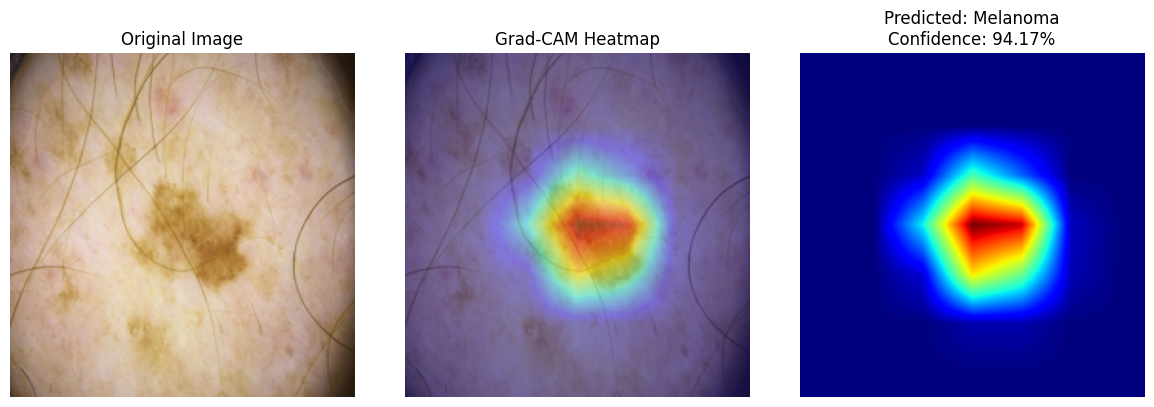

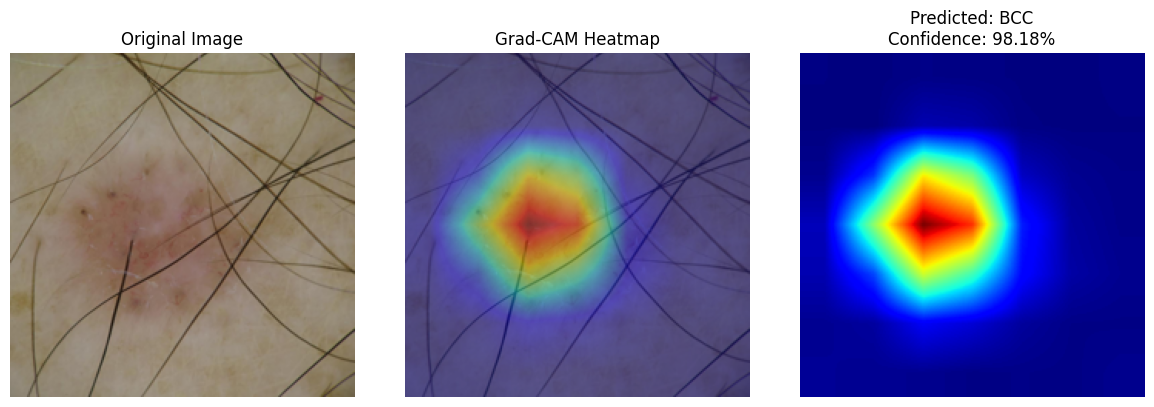

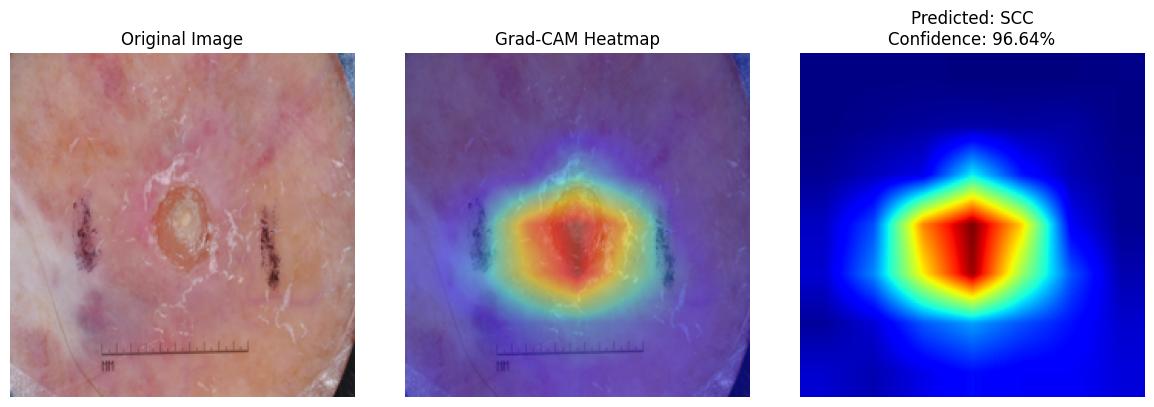

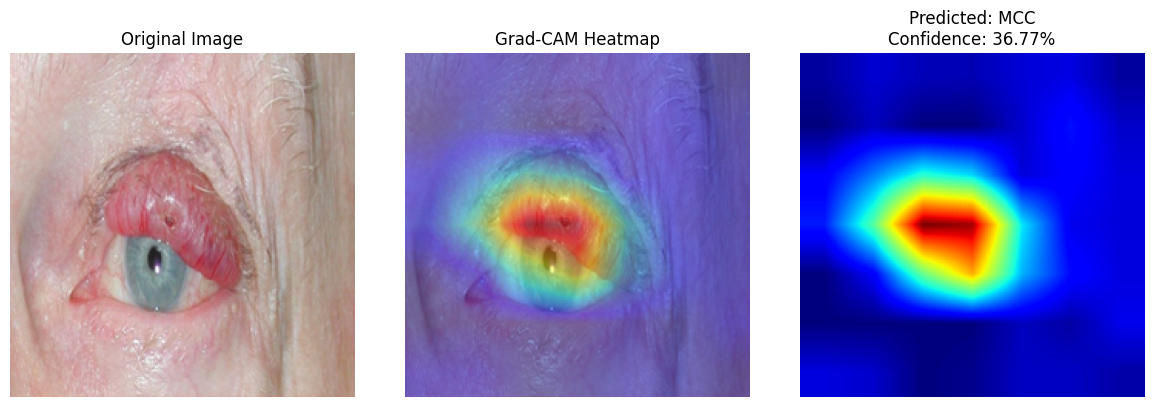


STEP 20 COMPLETE
Grad-CAM examples generated: 4

Grad-CAM output directory:
/kaggle/working/skin_cancer_project/results/gradcam

Grad-CAM results CSV:
/kaggle/working/skin_cancer_project/results/step20_gradcam_results.csv

✅ Explainability analysis completed

🧹 Memory cleanup completed.


In [36]:
# ============================================================
# STEP 20 — GRAD-CAM EXPLAINABILITY FOR BEST AUGMENTED MODEL
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms
from torch.utils.data import DataLoader

# ============================================================
# 1. CONFIGURATION
# ============================================================

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "checkpoints"
)

WEIGHTS_PATH = os.path.join(
    CHECKPOINT_DIR,
    "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
)

TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)

GRADCAM_DIR = os.path.join(
    RESULTS_DIR,
    "gradcam"
)

os.makedirs(
    GRADCAM_DIR,
    exist_ok=True
)

CLASS_NAMES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

NUM_CLASSES = 4
INPUT_SIZE = 224

DEVICE = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)

print("=" * 75)
print("STEP 20 — GRAD-CAM EXPLAINABILITY")
print("=" * 75)

print("Device :", DEVICE)
print("Model  :", WEIGHTS_PATH)


# ============================================================
# 2. CHECK FILES
# ============================================================

if not os.path.exists(WEIGHTS_PATH):

    raise FileNotFoundError(
        "\n❌ Augmented model checkpoint not found:\n"
        + WEIGHTS_PATH
    )

if not os.path.exists(TEST_CSV):

    raise FileNotFoundError(
        "\n❌ Test CSV not found:\n"
        + TEST_CSV
    )

print("\n✅ Required files found")


# ============================================================
# 3. LOAD TEST CSV
# ============================================================

test_df = pd.read_csv(
    TEST_CSV
)

print(
    "\nTest samples:",
    len(test_df)
)

print(
    "Test columns:",
    test_df.columns.tolist()
)


# ============================================================
# 4. LABEL MAPPING
# ============================================================

label_to_index = {
    "Melanoma": 0,
    "BCC": 1,
    "SCC": 2,
    "MCC": 3
}

index_to_label = {
    0: "Melanoma",
    1: "BCC",
    2: "SCC",
    3: "MCC"
}


# ============================================================
# 5. IMAGE TRANSFORM
# ============================================================
#
# IMPORTANT:
# Grad-CAM uses NO random augmentation.
# Same deterministic preprocessing as validation/test.
# ============================================================

transform = transforms.Compose([
    transforms.Resize(
        (INPUT_SIZE, INPUT_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 6. BUILD EXACT STEP 18A MODEL
# ============================================================

print("\nCreating EfficientNet-B0...")

model = models.efficientnet_b0(
    weights=None
)

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(
        p=0.30
    ),
    nn.Linear(
        in_features,
        NUM_CLASSES
    )
)

model = model.to(
    DEVICE
)


# ============================================================
# 7. LOAD BEST AUGMENTED CHECKPOINT
# ============================================================

print(
    "\nLoading best augmented checkpoint..."
)

state_dict = torch.load(
    WEIGHTS_PATH,
    map_location=DEVICE,
    weights_only=True
)

clean_state_dict = {}

for key, value in state_dict.items():

    if key.startswith("module."):

        clean_state_dict[
            key[7:]
        ] = value

    else:

        clean_state_dict[
            key
        ] = value


missing_keys, unexpected_keys = (
    model.load_state_dict(
        clean_state_dict,
        strict=False
    )
)

if (
    len(missing_keys) == 0
    and
    len(unexpected_keys) == 0
):

    print(
        "✅ Best augmented checkpoint loaded"
    )

else:

    print(
        "Missing keys:",
        missing_keys
    )

    print(
        "Unexpected keys:",
        unexpected_keys
    )

    raise RuntimeError(
        "❌ Checkpoint mismatch."
    )


model.eval()

print(
    "✅ Model ready"
)


# ============================================================
# 8. SELECT EFFICIENTNET TARGET LAYER
# ============================================================
#
# EfficientNet-B0 final convolutional feature layer.
# This layer preserves spatial information needed by Grad-CAM.
# ============================================================

target_layer = model.features[-1]

print(
    "\nGrad-CAM target layer:"
)

print(
    target_layer
)


# ============================================================
# 9. GRAD-CAM STORAGE
# ============================================================

activations = None
gradients = None


def forward_hook(
    module,
    input,
    output
):

    global activations

    activations = output


def backward_hook(
    module,
    grad_input,
    grad_output
):

    global gradients

    gradients = grad_output[0]


forward_handle = target_layer.register_forward_hook(
    forward_hook
)

backward_handle = target_layer.register_full_backward_hook(
    backward_hook
)


# ============================================================
# 10. GRAD-CAM FUNCTION
# ============================================================

def generate_gradcam(
    image_tensor,
    target_class
):

    global activations
    global gradients

    activations = None
    gradients = None

    model.zero_grad(
        set_to_none=True
    )

    output = model(
        image_tensor
    )

    score = output[
        0,
        target_class
    ]

    score.backward()

    if (
        activations is None
        or
        gradients is None
    ):

        raise RuntimeError(
            "❌ Grad-CAM hooks did not capture data."
        )

    # --------------------------------------------------------
    # Global average pooling of gradients
    # --------------------------------------------------------

    weights = gradients.mean(
        dim=(2, 3),
        keepdim=True
    )

    # --------------------------------------------------------
    # Weighted activation maps
    # --------------------------------------------------------

    cam = (
        weights * activations
    ).sum(
        dim=1,
        keepdim=True
    )

    # --------------------------------------------------------
    # ReLU
    # --------------------------------------------------------

    cam = torch.relu(
        cam
    )

    # --------------------------------------------------------
    # Resize to image size
    # --------------------------------------------------------

    cam = torch.nn.functional.interpolate(
        cam,
        size=(
            INPUT_SIZE,
            INPUT_SIZE
        ),
        mode="bilinear",
        align_corners=False
    )

    cam = cam[
        0,
        0
    ]

    # --------------------------------------------------------
    # Normalize 0-1
    # --------------------------------------------------------

    cam = (
        cam
        - cam.min()
    )

    cam = (
        cam
        / (
            cam.max()
            + 1e-8
        )
    )

    return (
        output.detach(),
        cam.detach().cpu().numpy()
    )


# ============================================================
# 11. IMAGE DE-NORMALIZATION
# ============================================================

def denormalize(
    tensor
):

    mean = torch.tensor(
        [
            0.485,
            0.456,
            0.406
        ],
        device=tensor.device
    ).view(
        3,
        1,
        1
    )

    std = torch.tensor(
        [
            0.229,
            0.224,
            0.225
        ],
        device=tensor.device
    ).view(
        3,
        1,
        1
    )

    image = (
        tensor * std
    ) + mean

    image = torch.clamp(
        image,
        0,
        1
    )

    return image


# ============================================================
# 12. SELECT REPRESENTATIVE TEST IMAGES
# ============================================================
#
# One correctly classified example per class when possible.
# If a class has no correct prediction, use its first example.
# ============================================================

print(
    "\nSelecting representative test images..."
)

# First obtain predictions for test images.
#
# This is done with deterministic preprocessing.
# ============================================================

prediction_records = []

for idx in range(
    len(test_df)
):

    row = test_df.iloc[
        idx
    ]

    image_path = row[
        "image_path"
    ]

    true_label = int(
        row["label"]
    )

    if not os.path.exists(
        image_path
    ):
        continue

    try:

        image = Image.open(
            image_path
        ).convert(
            "RGB"
        )

        image_tensor = transform(
            image
        ).unsqueeze(
            0
        ).to(
            DEVICE
        )

        with torch.inference_mode():

            output = model(
                image_tensor
            )

            probabilities = torch.softmax(
                output,
                dim=1
            )

            prediction = int(
                probabilities.argmax(
                    dim=1
                ).item()
            )

            confidence = float(
                probabilities[
                    0,
                    prediction
                ].item()
            )

        prediction_records.append({

            "index": idx,

            "image_path": image_path,

            "true_label": true_label,

            "pred_label": prediction,

            "confidence": confidence
        })

        del image_tensor

    except Exception:

        continue


prediction_df = pd.DataFrame(
    prediction_records
)

print(
    "Successfully evaluated:",
    len(prediction_df),
    "images"
)


# ============================================================
# 13. SELECT ONE GOOD EXAMPLE PER CLASS
# ============================================================

selected_rows = []

for class_idx in range(
    NUM_CLASSES
):

    correct = prediction_df[
        (
            prediction_df[
                "true_label"
            ]
            == class_idx
        )
        &
        (
            prediction_df[
                "pred_label"
            ]
            == class_idx
        )
    ]

    if len(correct) > 0:

        # Choose highest-confidence correct example
        selected = correct.sort_values(
            "confidence",
            ascending=False
        ).iloc[0]

    else:

        fallback = prediction_df[
            prediction_df[
                "true_label"
            ]
            == class_idx
        ]

        if len(fallback) == 0:
            continue

        selected = fallback.iloc[0]

    selected_rows.append(
        selected
    )


selected_df = pd.DataFrame(
    selected_rows
)

print(
    "\nSelected Grad-CAM examples:"
)

for _, row in selected_df.iterrows():

    print(
        f"True={index_to_label[int(row['true_label'])]} | "
        f"Pred={index_to_label[int(row['pred_label'])]} | "
        f"Confidence={row['confidence']*100:.2f}%"
    )


# ============================================================
# 14. GENERATE GRAD-CAM HEATMAPS
# ============================================================

print(
    "\nGenerating Grad-CAM heatmaps..."
)

gradcam_records = []

for _, row in selected_df.iterrows():

    sample_index = int(
        row["index"]
    )

    image_path = row[
        "image_path"
    ]

    true_label = int(
        row["true_label"]
    )

    predicted_label = int(
        row["pred_label"]
    )

    try:

        original_image = Image.open(
            image_path
        ).convert(
            "RGB"
        )

        image_tensor = transform(
            original_image
        ).unsqueeze(
            0
        ).to(
            DEVICE
        )

        # Generate Grad-CAM for predicted class
        output, cam = generate_gradcam(
            image_tensor,
            predicted_label
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )[0]

        confidence = float(
            probabilities[
                predicted_label
            ].item()
        )

        display_image = np.asarray(
            original_image.resize(
                (
                    INPUT_SIZE,
                    INPUT_SIZE
                )
            )
        )

        # ----------------------------------------------------
        # Save individual heatmap
        # ----------------------------------------------------

        true_name = index_to_label[
            true_label
        ]

        pred_name = index_to_label[
            predicted_label
        ]

        filename = (
            f"sample_{sample_index}_"
            f"true_{true_name}_"
            f"pred_{pred_name}.png"
        )

        save_path = os.path.join(
            GRADCAM_DIR,
            filename
        )

        # ----------------------------------------------------
        # Visualization
        # ----------------------------------------------------

        plt.figure(
            figsize=(12, 4)
        )

        plt.subplot(
            1,
            3,
            1
        )

        plt.imshow(
            display_image
        )

        plt.title(
            "Original Image"
        )

        plt.axis(
            "off"
        )

        plt.subplot(
            1,
            3,
            2
        )

        plt.imshow(
            display_image
        )

        plt.imshow(
            cam,
            cmap="jet",
            alpha=0.45
        )

        plt.title(
            "Grad-CAM Heatmap"
        )

        plt.axis(
            "off"
        )

        plt.subplot(
            1,
            3,
            3
        )

        plt.imshow(
            cam,
            cmap="jet"
        )

        plt.title(
            f"Predicted: {pred_name}\n"
            f"Confidence: {confidence*100:.2f}%"
        )

        plt.axis(
            "off"
        )

        plt.tight_layout()

        plt.savefig(
            save_path,
            dpi=150,
            bbox_inches="tight"
        )

        plt.show()

        gradcam_records.append({

            "test_index":
                sample_index,

            "image_path":
                image_path,

            "true_class":
                true_name,

            "predicted_class":
                pred_name,

            "confidence":
                confidence,

            "heatmap_path":
                save_path
        })

        del image_tensor
        del output

        gc.collect()

        if torch.cuda.is_available():

            torch.cuda.empty_cache()

    except Exception as e:

        print(
            f"⚠️ Grad-CAM failed for "
            f"sample {sample_index}: {e}"
        )


# ============================================================
# 15. SAVE GRAD-CAM RECORDS
# ============================================================

gradcam_df = pd.DataFrame(
    gradcam_records
)

gradcam_csv_path = os.path.join(
    RESULTS_DIR,
    "step20_gradcam_results.csv"
)

gradcam_df.to_csv(
    gradcam_csv_path,
    index=False
)


# ============================================================
# 16. CLEANUP HOOKS
# ============================================================

forward_handle.remove()
backward_handle.remove()


# ============================================================
# 17. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("STEP 20 COMPLETE")
print("=" * 75)

print(
    "Grad-CAM examples generated:",
    len(gradcam_df)
)

print(
    "\nGrad-CAM output directory:"
)

print(
    GRADCAM_DIR
)

print(
    "\nGrad-CAM results CSV:"
)

print(
    gradcam_csv_path
)

print(
    "\n✅ Explainability analysis completed"
)

print("=" * 75)


# ============================================================
# 18. MEMORY CLEANUP
# ============================================================

del prediction_records
del prediction_df
del selected_df
del gradcam_df
del model
del state_dict
del clean_state_dict

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

print(
    "\n🧹 Memory cleanup completed."
)

STEP 22 — FINAL EFFICIENTNET-B0 TRAINING CURVES

[1] Loading actual augmented training history...
✅ History loaded
Epochs recorded: 10

Columns:
['epoch', 'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'val_macro_f1', 'learning_rate', 'ram_gb']

[2] BEST MODEL EPOCH
------------------------------------------------------------------------------
Best Epoch              : 5
Best Validation Macro-F1: 76.09%
Validation Accuracy     : 86.04%
Validation Loss         : 0.94080

[3] Creating Loss Curve...


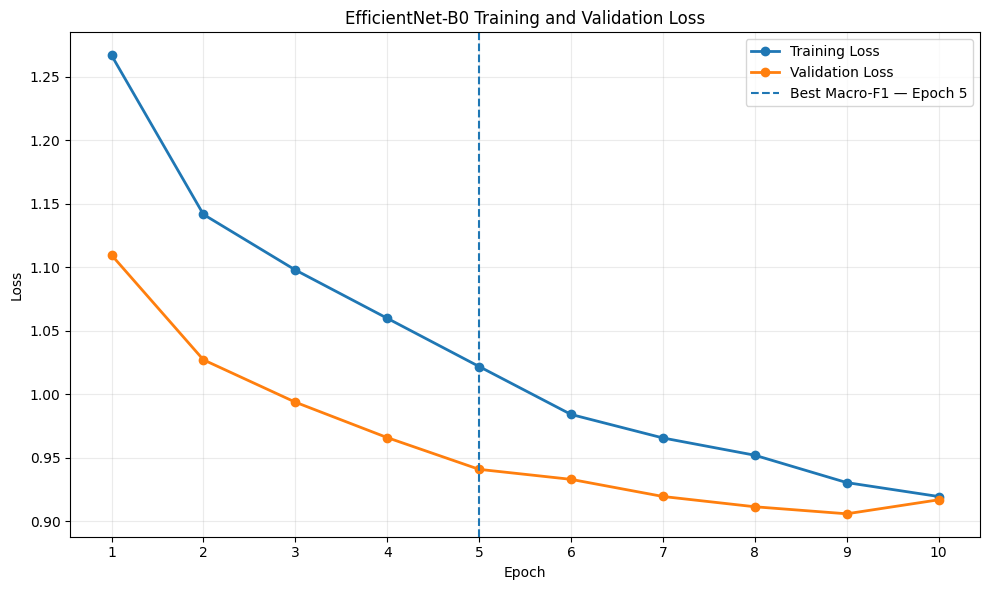

✅ Saved: /kaggle/working/skin_cancer_project/results/STEP22_training_validation_loss.png

[4] Creating Accuracy Curve...


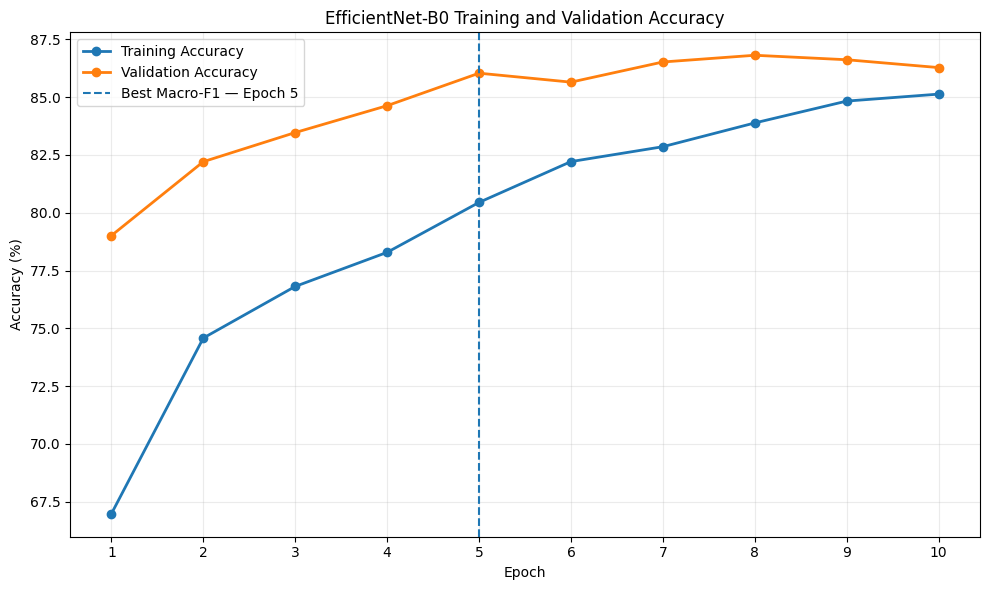

✅ Saved: /kaggle/working/skin_cancer_project/results/STEP22_training_validation_accuracy.png

[5] Creating Validation Macro-F1 Curve...


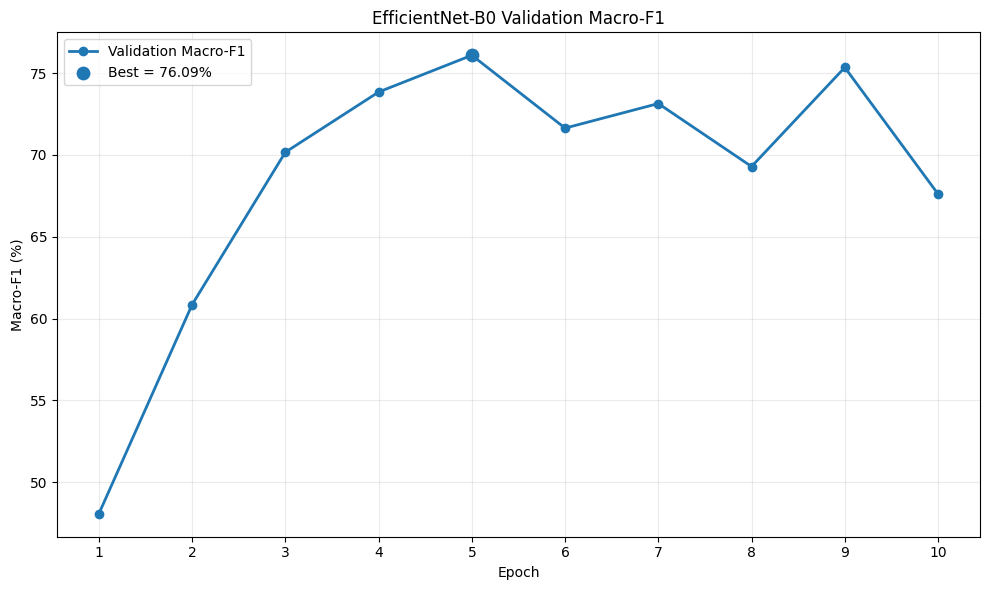

✅ Saved: /kaggle/working/skin_cancer_project/results/STEP22_validation_macro_f1.png

[6] Creating Learning Rate Curve...


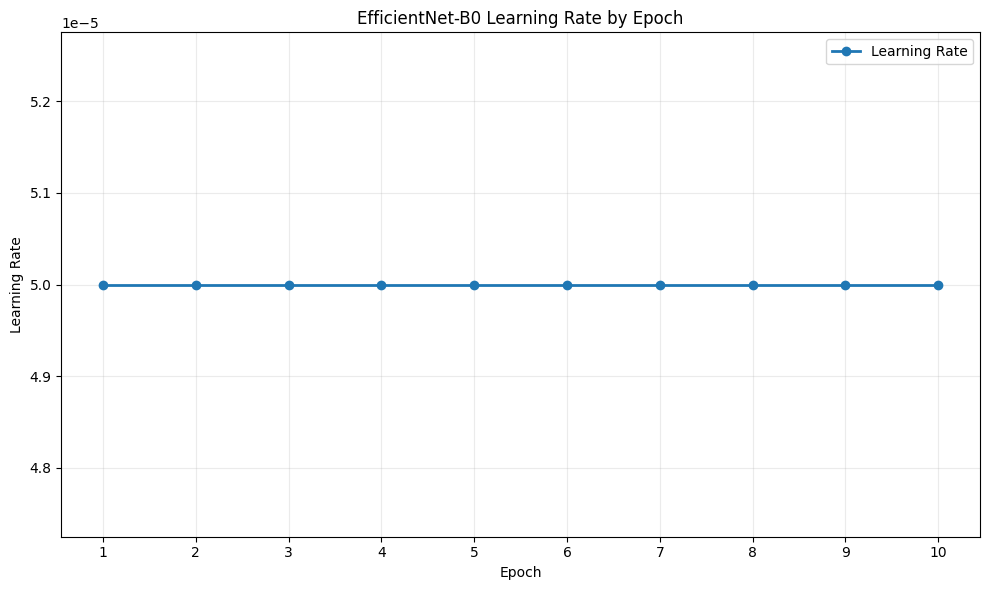

✅ Saved: /kaggle/working/skin_cancer_project/results/STEP22_learning_rate.png

[7] Training history saved:
/kaggle/working/skin_cancer_project/results/STEP22_final_training_history.csv

STEP 22 COMPLETE

Best Epoch              : 5
Best Validation Macro-F1: 76.09%
Best Validation Accuracy: 86.04%
Best Validation Loss    : 0.94080

Generated charts:
1. /kaggle/working/skin_cancer_project/results/STEP22_training_validation_loss.png
2. /kaggle/working/skin_cancer_project/results/STEP22_training_validation_accuracy.png
3. /kaggle/working/skin_cancer_project/results/STEP22_validation_macro_f1.png
4. /kaggle/working/skin_cancer_project/results/STEP22_learning_rate.png

✅ REAL FINAL-MODEL TRAINING CURVES GENERATED


In [41]:
# ============================================================================
# STEP 22 — FINAL EFFICIENTNET-B0 TRAINING CURVES
#             LOSS + ACCURACY + MACRO-F1 + LEARNING RATE
# ============================================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 78)
print("STEP 22 — FINAL EFFICIENTNET-B0 TRAINING CURVES")
print("=" * 78)

BASE = "/kaggle/working/skin_cancer_project"

RESULTS_DIR = f"{BASE}/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

HISTORY_PATH = (
    f"{RESULTS_DIR}/step18A_augmentation_training_history.csv"
)

# --------------------------------------------------------------------------
# 1. LOAD ACTUAL FINAL TRAINING HISTORY
# --------------------------------------------------------------------------

print("\n[1] Loading actual augmented training history...")

if not os.path.exists(HISTORY_PATH):
    raise FileNotFoundError(
        f"❌ Training history not found:\n{HISTORY_PATH}"
    )

history_df = pd.read_csv(HISTORY_PATH)

print("✅ History loaded")
print(f"Epochs recorded: {len(history_df)}")

print("\nColumns:")
print(history_df.columns.tolist())


# --------------------------------------------------------------------------
# 2. VERIFY REQUIRED COLUMNS
# --------------------------------------------------------------------------

required_columns = [
    "epoch",
    "train_loss",
    "train_accuracy",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "learning_rate"
]

missing = [
    col for col in required_columns
    if col not in history_df.columns
]

if missing:
    raise KeyError(
        f"❌ Missing required columns: {missing}"
    )

epochs = history_df["epoch"]


# --------------------------------------------------------------------------
# 3. FIND BEST VALIDATION MACRO-F1
# --------------------------------------------------------------------------

best_idx = history_df["val_macro_f1"].idxmax()

best_epoch = int(
    history_df.loc[best_idx, "epoch"]
)

best_macro_f1 = float(
    history_df.loc[best_idx, "val_macro_f1"]
)

best_val_accuracy = float(
    history_df.loc[best_idx, "val_accuracy"]
)

best_val_loss = float(
    history_df.loc[best_idx, "val_loss"]
)

print("\n[2] BEST MODEL EPOCH")
print("-" * 78)

print(f"Best Epoch              : {best_epoch}")
print(f"Best Validation Macro-F1: {best_macro_f1:.2f}%")
print(f"Validation Accuracy     : {best_val_accuracy:.2f}%")
print(f"Validation Loss         : {best_val_loss:.5f}")


# --------------------------------------------------------------------------
# 4. CHART 1 — TRAINING / VALIDATION LOSS
# --------------------------------------------------------------------------

print("\n[3] Creating Loss Curve...")

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history_df["train_loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    history_df["val_loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Macro-F1 — Epoch {best_epoch}"
)

plt.title(
    "EfficientNet-B0 Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

loss_path = (
    f"{RESULTS_DIR}/STEP22_training_validation_loss.png"
)

plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"✅ Saved: {loss_path}")


# --------------------------------------------------------------------------
# 5. CHART 2 — TRAINING / VALIDATION ACCURACY
# --------------------------------------------------------------------------

print("\n[4] Creating Accuracy Curve...")

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history_df["train_accuracy"],
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_df["val_accuracy"],
    marker="o",
    linewidth=2,
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Macro-F1 — Epoch {best_epoch}"
)

plt.title(
    "EfficientNet-B0 Training and Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(epochs)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

accuracy_path = (
    f"{RESULTS_DIR}/STEP22_training_validation_accuracy.png"
)

plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"✅ Saved: {accuracy_path}")


# --------------------------------------------------------------------------
# 6. CHART 3 — VALIDATION MACRO-F1
# --------------------------------------------------------------------------

print("\n[5] Creating Validation Macro-F1 Curve...")

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history_df["val_macro_f1"],
    marker="o",
    linewidth=2,
    label="Validation Macro-F1"
)

plt.scatter(
    [best_epoch],
    [best_macro_f1],
    s=80,
    zorder=5,
    label=f"Best = {best_macro_f1:.2f}%"
)

plt.title(
    "EfficientNet-B0 Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1 (%)")
plt.xticks(epochs)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

f1_path = (
    f"{RESULTS_DIR}/STEP22_validation_macro_f1.png"
)

plt.savefig(
    f1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"✅ Saved: {f1_path}")


# --------------------------------------------------------------------------
# 7. CHART 4 — LEARNING RATE
# --------------------------------------------------------------------------

print("\n[6] Creating Learning Rate Curve...")

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history_df["learning_rate"],
    marker="o",
    linewidth=2,
    label="Learning Rate"
)

plt.title(
    "EfficientNet-B0 Learning Rate by Epoch"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.xticks(epochs)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

lr_path = (
    f"{RESULTS_DIR}/STEP22_learning_rate.png"
)

plt.savefig(
    lr_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"✅ Saved: {lr_path}")


# --------------------------------------------------------------------------
# 8. SAVE FINAL HISTORY COPY
# --------------------------------------------------------------------------

final_history_path = (
    f"{RESULTS_DIR}/STEP22_final_training_history.csv"
)

history_df.to_csv(
    final_history_path,
    index=False
)

print("\n[7] Training history saved:")
print(final_history_path)


# --------------------------------------------------------------------------
# 9. FINAL SUMMARY
# --------------------------------------------------------------------------

print("\n" + "=" * 78)
print("STEP 22 COMPLETE")
print("=" * 78)

print(f"\nBest Epoch              : {best_epoch}")
print(f"Best Validation Macro-F1: {best_macro_f1:.2f}%")
print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")
print(f"Best Validation Loss    : {best_val_loss:.5f}")

print("\nGenerated charts:")
print("1.", loss_path)
print("2.", accuracy_path)
print("3.", f1_path)
print("4.", lr_path)

print("\n✅ REAL FINAL-MODEL TRAINING CURVES GENERATED")
print("=" * 78)

STEP 23 — FINAL CONFUSION MATRIX + CLASS-WISE PERFORMANCE
BLUE COLOR VERSION

✅ Final results loaded

[1] Creating BLUE confusion matrix...


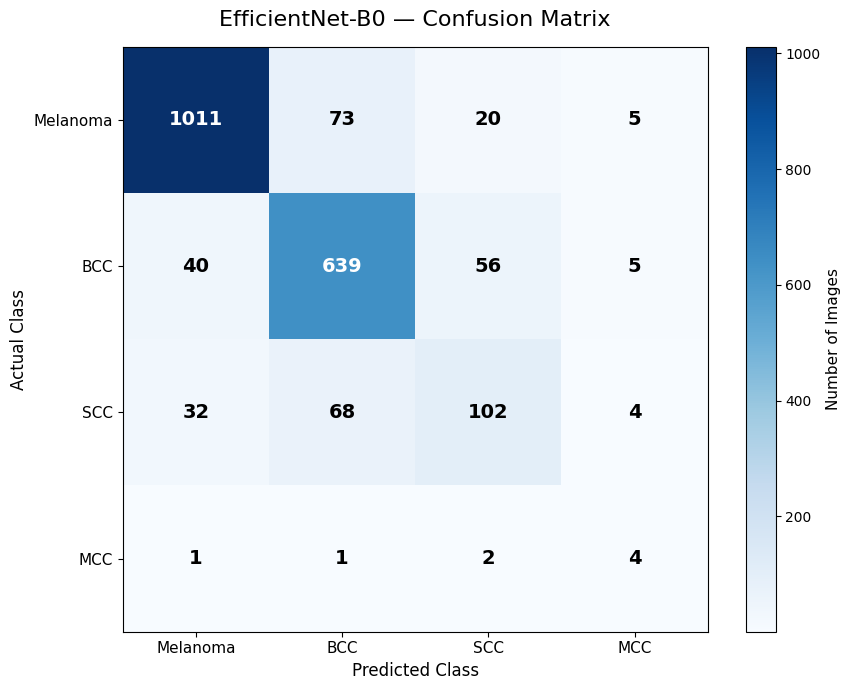

✅ BLUE confusion matrix saved:
/kaggle/working/skin_cancer_project/results/STEP23_final_confusion_matrix_BLUE.png

[2] Preparing class-wise performance...

[3] Creating BLUE class-wise performance chart...


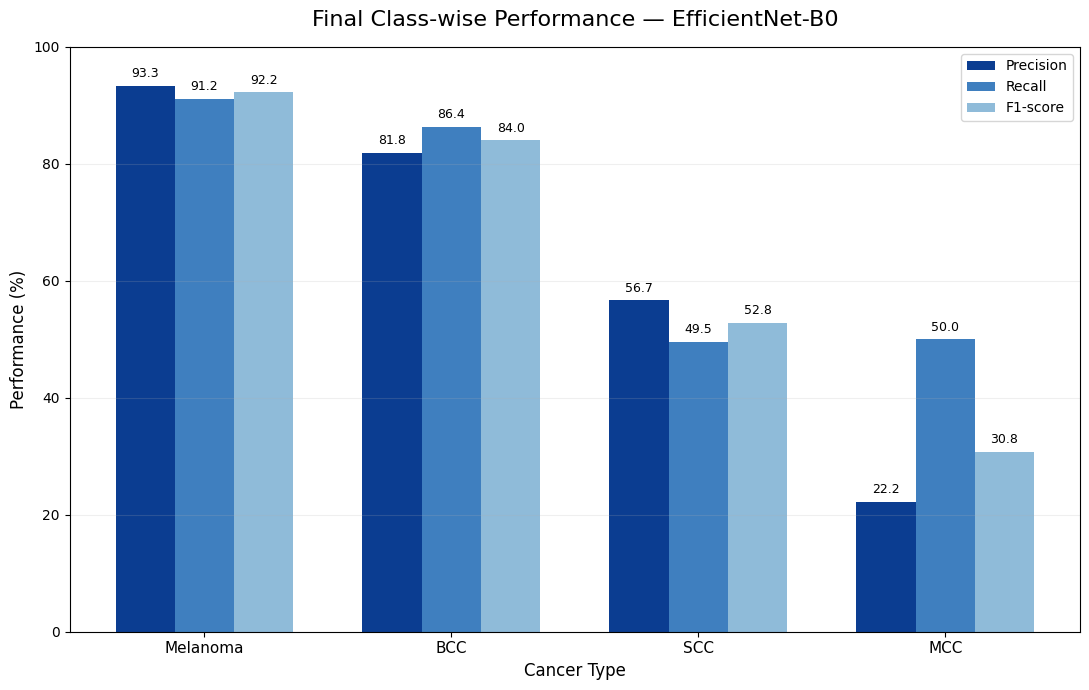

✅ BLUE class-wise performance saved:
/kaggle/working/skin_cancer_project/results/STEP23_class_wise_performance_BLUE.png

STEP 23 COMPLETE

Generated outputs:
1. BLUE Confusion Matrix:
/kaggle/working/skin_cancer_project/results/STEP23_final_confusion_matrix_BLUE.png

2. BLUE Class-wise Performance:
/kaggle/working/skin_cancer_project/results/STEP23_class_wise_performance_BLUE.png

3. Clean Metrics:
/kaggle/working/skin_cancer_project/results/STEP23_clean_class_wise_metrics.csv

F1 Scores:
Melanoma   F1 = 92.20% (Support = 1109)
BCC        F1 = 84.02% (Support = 740)
SCC        F1 = 52.85% (Support = 206)
MCC        F1 = 30.77% (Support = 8)

⚠️ Please interpret MCC performance cautiously.

✅ BLUE COLOR FINAL VISUALIZATIONS READY


In [44]:
# ============================================================================
# STEP 23 — FINAL CONFUSION MATRIX + CLASS-WISE PERFORMANCE VISUALIZATION
#                 BLUE COLOR VERSION — LIKE REFERENCE IMAGE
# ============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 78)
print("STEP 23 — FINAL CONFUSION MATRIX + CLASS-WISE PERFORMANCE")
print("BLUE COLOR VERSION")
print("=" * 78)

BASE = "/kaggle/working/skin_cancer_project"
RESULTS_DIR = f"{BASE}/results"

os.makedirs(RESULTS_DIR, exist_ok=True)

CM_PATH = (
    f"{RESULTS_DIR}/step19_augmented_confusion_matrix.csv"
)

METRICS_PATH = (
    f"{RESULTS_DIR}/step19_augmented_class_wise_metrics.csv"
)

if not os.path.exists(CM_PATH):
    raise FileNotFoundError(
        f"❌ Confusion matrix not found:\n{CM_PATH}"
    )

if not os.path.exists(METRICS_PATH):
    raise FileNotFoundError(
        f"❌ Class-wise metrics not found:\n{METRICS_PATH}"
    )

# --------------------------------------------------------------------------
# 1. LOAD RESULTS
# --------------------------------------------------------------------------

cm_df = pd.read_csv(CM_PATH)
metrics_df = pd.read_csv(METRICS_PATH)

classes = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

cm = cm_df[
    [
        "Pred_Melanoma",
        "Pred_BCC",
        "Pred_SCC",
        "Pred_MCC"
    ]
].values.astype(int)

print("\n✅ Final results loaded")


# --------------------------------------------------------------------------
# 2. FINAL CONFUSION MATRIX — BLUE
# --------------------------------------------------------------------------

print("\n[1] Creating BLUE confusion matrix...")

plt.figure(figsize=(9, 7))

plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"          # ⭐ BLUE LIKE REFERENCE IMAGE
)

plt.title(
    "EfficientNet-B0 — Confusion Matrix",
    fontsize=16,
    pad=15
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "Actual Class",
    fontsize=12
)

plt.xticks(
    np.arange(len(classes)),
    classes,
    fontsize=11
)

plt.yticks(
    np.arange(len(classes)),
    classes,
    fontsize=11
)

# --------------------------------------------------------------------------
# CELL VALUES
# --------------------------------------------------------------------------

threshold = cm.max() / 2.0

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",

            # dark cells → white text
            # light cells → black text
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )

# --------------------------------------------------------------------------
# COLOR BAR
# --------------------------------------------------------------------------

cbar = plt.colorbar()

cbar.set_label(
    "Number of Images",
    fontsize=11
)

plt.tight_layout()

cm_output = (
    f"{RESULTS_DIR}/STEP23_final_confusion_matrix_BLUE.png"
)

plt.savefig(
    cm_output,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(
    f"✅ BLUE confusion matrix saved:\n"
    f"{cm_output}"
)


# --------------------------------------------------------------------------
# 3. CLASS-WISE METRICS
# --------------------------------------------------------------------------

print("\n[2] Preparing class-wise performance...")

class_rows = metrics_df[
    metrics_df["Unnamed: 0"].isin(classes)
].copy()

class_rows["class_order"] = (
    class_rows["Unnamed: 0"].map(
        {
            "Melanoma": 0,
            "BCC": 1,
            "SCC": 2,
            "MCC": 3
        }
    )
)

class_rows = (
    class_rows
    .sort_values("class_order")
    .reset_index(drop=True)
)


# --------------------------------------------------------------------------
# 4. CLASS-WISE PERFORMANCE — BLUE
# --------------------------------------------------------------------------

print("\n[3] Creating BLUE class-wise performance chart...")

x = np.arange(len(classes))
width = 0.24

precision = class_rows["precision"].values * 100
recall = class_rows["recall"].values * 100
f1 = class_rows["f1-score"].values * 100

plt.figure(figsize=(11, 7))

# Blue-style shades
plt.bar(
    x - width,
    precision,
    width,
    label="Precision",
    color="#0B3D91"
)

plt.bar(
    x,
    recall,
    width,
    label="Recall",
    color="#3F7FBF"
)

plt.bar(
    x + width,
    f1,
    width,
    label="F1-score",
    color="#8FBBD9"
)

plt.title(
    "Final Class-wise Performance — EfficientNet-B0",
    fontsize=16,
    pad=15
)

plt.xlabel(
    "Cancer Type",
    fontsize=12
)

plt.ylabel(
    "Performance (%)",
    fontsize=12
)

plt.xticks(
    x,
    classes,
    fontsize=11
)

plt.ylim(
    0,
    100
)

plt.grid(
    axis="y",
    alpha=0.20
)

plt.legend()


# --------------------------------------------------------------------------
# VALUE LABELS
# --------------------------------------------------------------------------

for i in range(len(classes)):

    if precision[i] > 0:
        plt.text(
            i - width,
            precision[i] + 1.5,
            f"{precision[i]:.1f}",
            ha="center",
            fontsize=9
        )

    if recall[i] > 0:
        plt.text(
            i,
            recall[i] + 1.5,
            f"{recall[i]:.1f}",
            ha="center",
            fontsize=9
        )

    if f1[i] > 0:
        plt.text(
            i + width,
            f1[i] + 1.5,
            f"{f1[i]:.1f}",
            ha="center",
            fontsize=9
        )


plt.tight_layout()

performance_output = (
    f"{RESULTS_DIR}/STEP23_class_wise_performance_BLUE.png"
)

plt.savefig(
    performance_output,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(
    f"✅ BLUE class-wise performance saved:\n"
    f"{performance_output}"
)


# --------------------------------------------------------------------------
# 5. SAVE CLEAN METRICS
# --------------------------------------------------------------------------

clean_metrics = class_rows[
    [
        "Unnamed: 0",
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
].copy()

clean_metrics.columns = [
    "Class",
    "Precision",
    "Recall",
    "F1_Score",
    "Support"
]

clean_metrics["Precision"] *= 100
clean_metrics["Recall"] *= 100
clean_metrics["F1_Score"] *= 100

clean_metrics_output = (
    f"{RESULTS_DIR}/STEP23_clean_class_wise_metrics.csv"
)

clean_metrics.to_csv(
    clean_metrics_output,
    index=False
)


# --------------------------------------------------------------------------
# 6. FINAL SUMMARY
# --------------------------------------------------------------------------

print("\n" + "=" * 78)
print("STEP 23 COMPLETE")
print("=" * 78)

print("\nGenerated outputs:")

print(
    f"1. BLUE Confusion Matrix:\n"
    f"{cm_output}"
)

print(
    f"\n2. BLUE Class-wise Performance:\n"
    f"{performance_output}"
)

print(
    f"\n3. Clean Metrics:\n"
    f"{clean_metrics_output}"
)

print("\nF1 Scores:")

for _, row in clean_metrics.iterrows():

    print(
        f"{row['Class']:<10} "
        f"F1 = {row['F1_Score']:.2f}% "
        f"(Support = {int(row['Support'])})"
    )

print("\n⚠️ Please interpret MCC performance cautiously.")
print("\n✅ BLUE COLOR FINAL VISUALIZATIONS READY")
print("=" * 78)

STEP 24 — FINAL GRAD-CAM + SKIN-TONE / EXPLAINABILITY OUTPUT

[1] Checking final Grad-CAM results...
------------------------------------------------------------------------------
✅ Final Grad-CAM CSV found
Grad-CAM examples: 4

Selected explainability examples:
True=Melanoma | Pred=Melanoma | Confidence=94.17%
True=BCC | Pred=BCC | Confidence=98.18%
True=SCC | Pred=SCC | Confidence=96.64%
True=MCC | Pred=MCC | Confidence=36.77%

[2] Creating final Grad-CAM presentation...


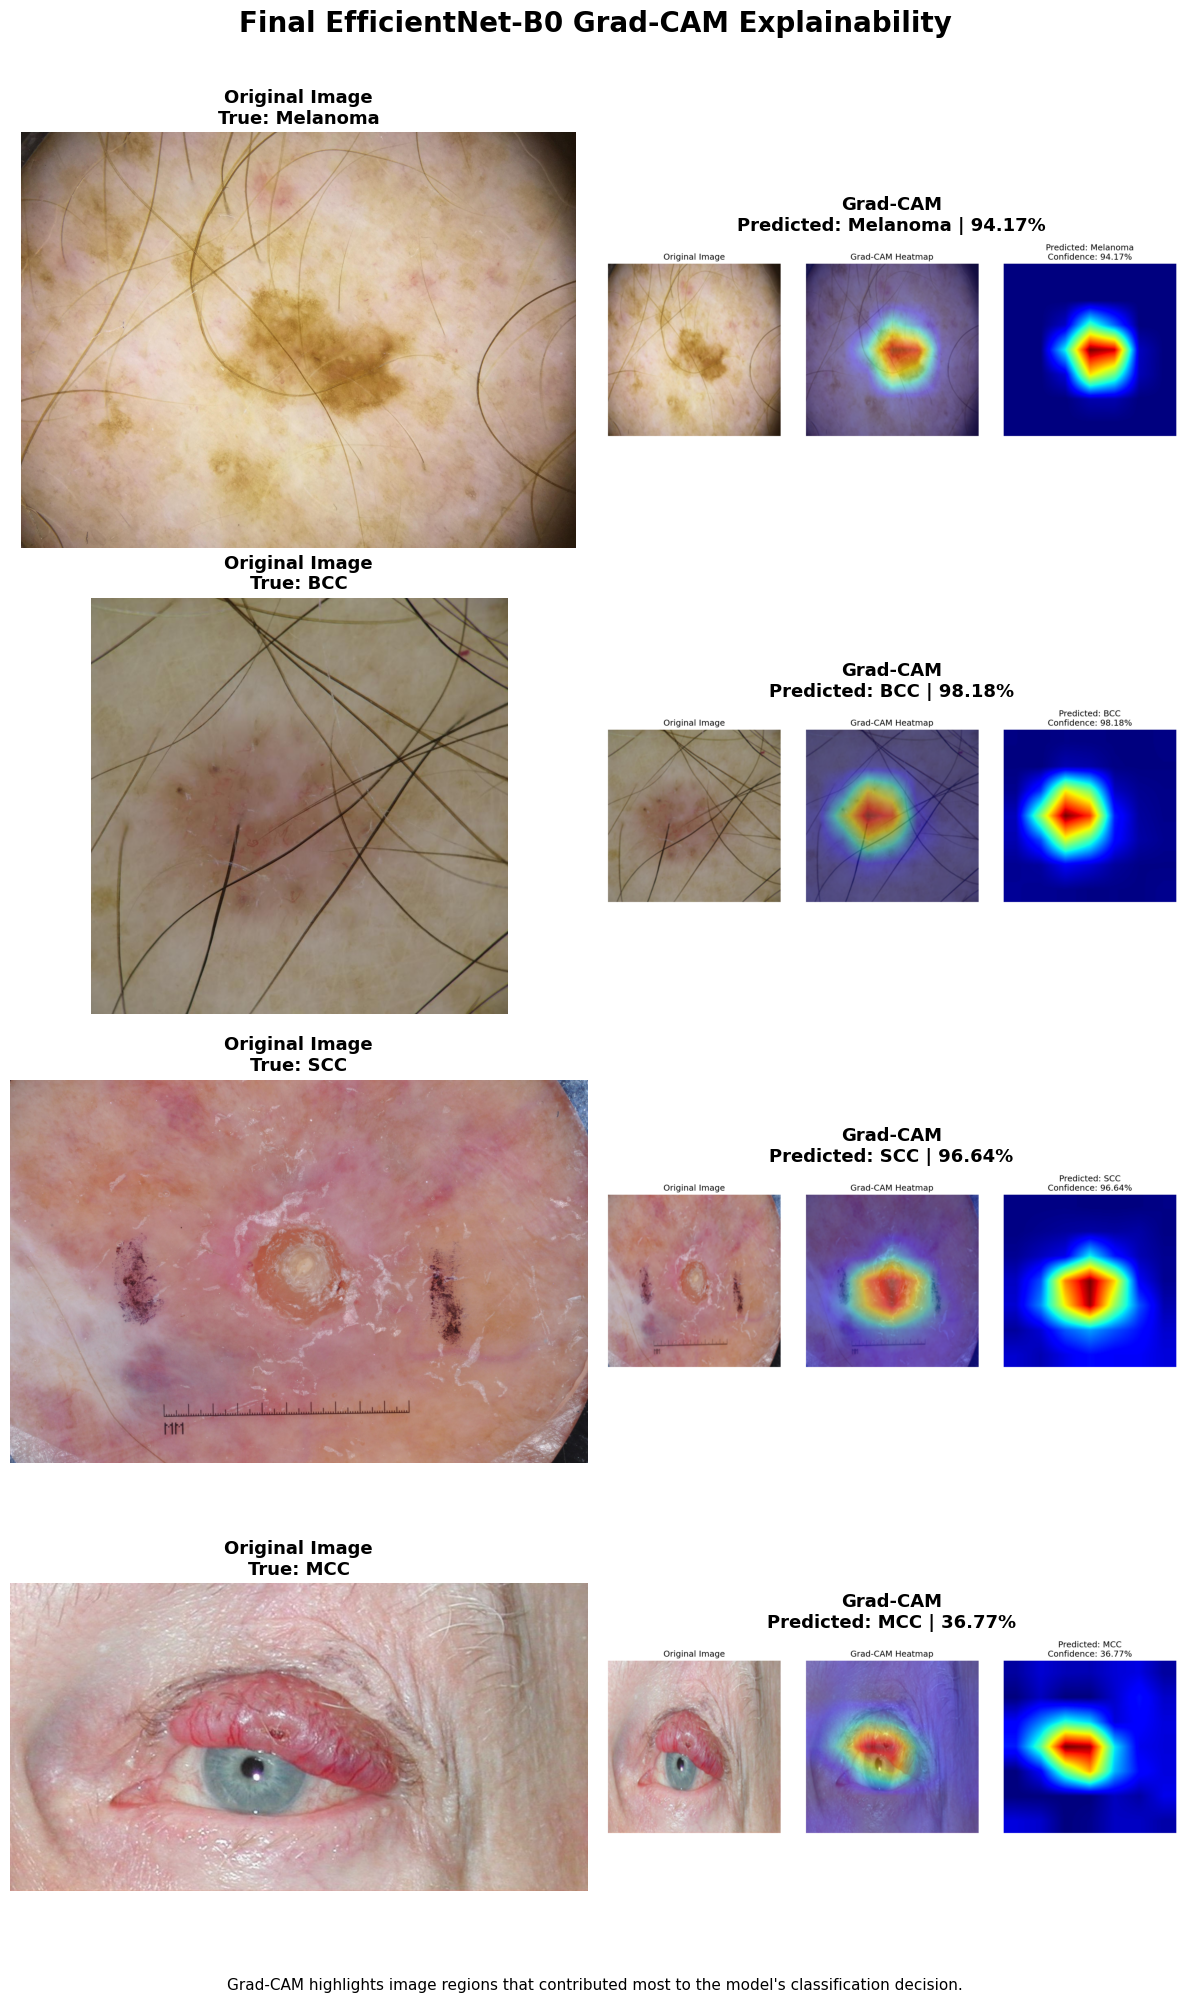

✅ Grad-CAM presentation saved:
/kaggle/working/skin_cancer_project/results/STEP24_FINAL_GradCAM_Presentation.png

[3] Checking skin-tone proxy analysis...
------------------------------------------------------------------------------
✅ Skin-tone proxy manifest found

Proxy group column: skin_tone_proxy_group
skin_tone_proxy_group
1    342
2    342
3    342
4    342
5    342
6    342


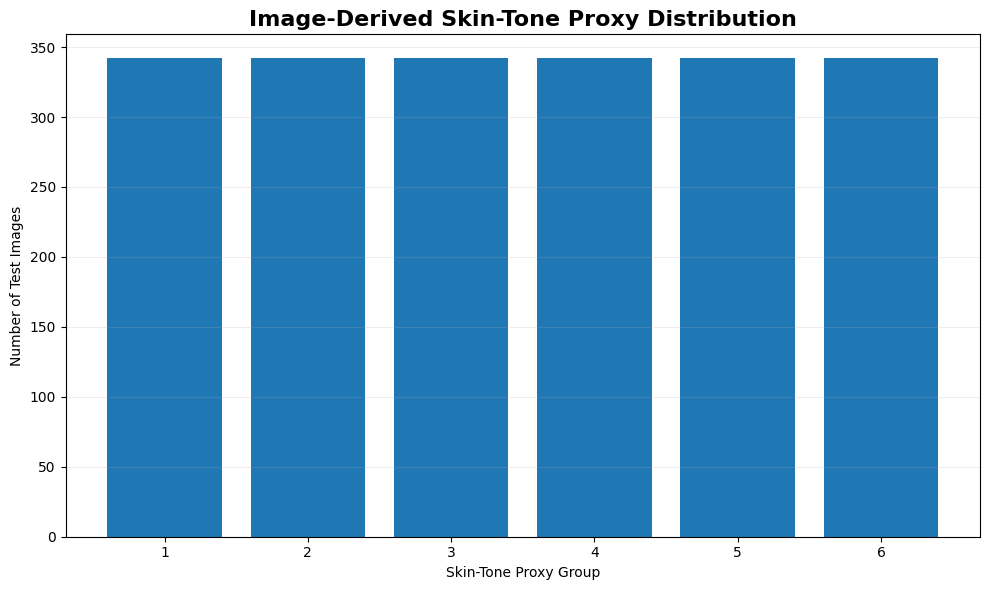

✅ Skin-tone proxy visualization saved:
/kaggle/working/skin_cancer_project/results/STEP24_skin_tone_proxy_distribution.png

[4] Creating explainability summary...
✅ Summary saved:
/kaggle/working/skin_cancer_project/results/STEP24_explainability_summary.txt

STEP 24 COMPLETE

Generated:
1. Final Grad-CAM Presentation:
   /kaggle/working/skin_cancer_project/results/STEP24_FINAL_GradCAM_Presentation.png

2. Skin-Tone Proxy Visualization:
   /kaggle/working/skin_cancer_project/results/STEP24_skin_tone_proxy_distribution.png

3. Explainability Summary:
   /kaggle/working/skin_cancer_project/results/STEP24_explainability_summary.txt

Important:
• Grad-CAM uses the FINAL augmented EfficientNet-B0 model.
• Skin-tone grouping is an exploratory image-derived proxy.
• Proxy groups are NOT clinical Fitzpatrick skin types.
• This output is for model explainability/fairness analysis.

✅ FINAL EXPLAINABILITY PRESENTATION READY


In [45]:
# ============================================================================
# STEP 24 — FINAL GRAD-CAM + SKIN-TONE / EXPLAINABILITY PRESENTATION OUTPUT
# ============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("=" * 78)
print("STEP 24 — FINAL GRAD-CAM + SKIN-TONE / EXPLAINABILITY OUTPUT")
print("=" * 78)

BASE = "/kaggle/working/skin_cancer_project"
RESULTS_DIR = f"{BASE}/results"
GRADCAM_DIR = f"{RESULTS_DIR}/gradcam"

GRADCAM_CSV = (
    f"{RESULTS_DIR}/step20_gradcam_results.csv"
)

PROXY_CSV = (
    f"{RESULTS_DIR}/step18A_proxy/"
    f"step18A_skin_tone_proxy_manifest.csv"
)

os.makedirs(RESULTS_DIR, exist_ok=True)


# ============================================================================
# 1. CHECK FINAL GRAD-CAM RESULTS
# ============================================================================

print("\n[1] Checking final Grad-CAM results...")
print("-" * 78)

if not os.path.exists(GRADCAM_CSV):
    raise FileNotFoundError(
        f"❌ Final Grad-CAM results not found:\n{GRADCAM_CSV}"
    )

gradcam_df = pd.read_csv(GRADCAM_CSV)

print("✅ Final Grad-CAM CSV found")
print(f"Grad-CAM examples: {len(gradcam_df)}")


# ============================================================================
# 2. LOAD FOUR REPRESENTATIVE EXAMPLES
# ============================================================================

classes = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

selected_rows = []

for cancer_class in classes:

    matches = gradcam_df[
        gradcam_df["true_class"] == cancer_class
    ]

    if len(matches) > 0:
        selected_rows.append(
            matches.iloc[0]
        )

if len(selected_rows) == 0:
    raise RuntimeError(
        "❌ No Grad-CAM examples available."
    )

selected_df = pd.DataFrame(
    selected_rows
)

print("\nSelected explainability examples:")

for _, row in selected_df.iterrows():

    print(
        f"True={row['true_class']} | "
        f"Pred={row['predicted_class']} | "
        f"Confidence="
        f"{row['confidence'] * 100:.2f}%"
    )


# ============================================================================
# 3. CREATE FINAL GRAD-CAM PRESENTATION
# ============================================================================

print("\n[2] Creating final Grad-CAM presentation...")

fig, axes = plt.subplots(
    len(selected_df),
    2,
    figsize=(12, 5 * len(selected_df))
)

if len(selected_df) == 1:
    axes = np.array([axes])

for i, (_, row) in enumerate(selected_df.iterrows()):

    image_path = row["image_path"]
    heatmap_path = row["heatmap_path"]

    # Original image
    ax_original = axes[i, 0]

    if os.path.exists(image_path):

        original = Image.open(
            image_path
        ).convert("RGB")

        ax_original.imshow(
            original
        )

    ax_original.set_title(
        f"Original Image\n"
        f"True: {row['true_class']}",
        fontsize=13,
        fontweight="bold"
    )

    ax_original.axis("off")

    # Grad-CAM
    ax_cam = axes[i, 1]

    if os.path.exists(heatmap_path):

        heatmap = Image.open(
            heatmap_path
        ).convert("RGB")

        ax_cam.imshow(
            heatmap
        )

    ax_cam.set_title(
        f"Grad-CAM\n"
        f"Predicted: {row['predicted_class']} | "
        f"{row['confidence'] * 100:.2f}%",
        fontsize=13,
        fontweight="bold"
    )

    ax_cam.axis("off")


fig.suptitle(
    "Final EfficientNet-B0 Grad-CAM Explainability",
    fontsize=20,
    fontweight="bold",
    y=0.995
)

fig.text(
    0.5,
    0.005,
    "Grad-CAM highlights image regions that contributed most "
    "to the model's classification decision.",
    ha="center",
    fontsize=11
)

plt.tight_layout(
    rect=[0, 0.02, 1, 0.98]
)

gradcam_presentation = (
    f"{RESULTS_DIR}/STEP24_FINAL_GradCAM_Presentation.png"
)

plt.savefig(
    gradcam_presentation,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(
    f"✅ Grad-CAM presentation saved:\n"
    f"{gradcam_presentation}"
)


# ============================================================================
# 4. SKIN-TONE PROXY CHECK
# ============================================================================

print("\n[3] Checking skin-tone proxy analysis...")
print("-" * 78)

proxy_available = os.path.exists(
    PROXY_CSV
)

if proxy_available:

    proxy_df = pd.read_csv(
        PROXY_CSV
    )

    print("✅ Skin-tone proxy manifest found")

    # Automatically detect the group column
    possible_group_columns = [
        "skin_tone_proxy_group",
        "proxy_group",
        "skin_tone_group",
        "tone_group"
    ]

    group_column = None

    for col in possible_group_columns:

        if col in proxy_df.columns:
            group_column = col
            break

    if group_column is not None:

        group_counts = (
            proxy_df[group_column]
            .value_counts()
            .sort_index()
        )

        print(
            f"\nProxy group column: {group_column}"
        )

        print(
            group_counts.to_string()
        )

        # --------------------------------------------------------------
        # CREATE PROXY DISTRIBUTION VISUALIZATION
        # --------------------------------------------------------------

        plt.figure(
            figsize=(10, 6)
        )

        plt.bar(
            group_counts.index.astype(str),
            group_counts.values
        )

        plt.title(
            "Image-Derived Skin-Tone Proxy Distribution",
            fontsize=16,
            fontweight="bold"
        )

        plt.xlabel(
            "Skin-Tone Proxy Group"
        )

        plt.ylabel(
            "Number of Test Images"
        )

        plt.grid(
            axis="y",
            alpha=0.20
        )

        plt.tight_layout()

        proxy_plot = (
            f"{RESULTS_DIR}/"
            "STEP24_skin_tone_proxy_distribution.png"
        )

        plt.savefig(
            proxy_plot,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

        print(
            f"✅ Skin-tone proxy visualization saved:\n"
            f"{proxy_plot}"
        )

    else:

        print(
            "⚠️ Proxy manifest found, but group column "
            "could not be identified."
        )

else:

    print(
        "⚠️ Skin-tone proxy manifest not found."
    )

    print(
        "Grad-CAM presentation will still be available."
    )


# ============================================================================
# 5. EXPLAINABILITY SUMMARY
# ============================================================================

print("\n[4] Creating explainability summary...")

summary_path = (
    f"{RESULTS_DIR}/STEP24_explainability_summary.txt"
)

with open(
    summary_path,
    "w"
) as f:

    f.write(
        "FINAL EXPLAINABILITY SUMMARY\n"
        "============================\n\n"
    )

    f.write(
        "Model: EfficientNet-B0\n"
    )

    f.write(
        "Input size: 224 x 224\n"
    )

    f.write(
        "Classes: Melanoma, BCC, SCC, MCC\n\n"
    )

    f.write(
        "Grad-CAM:\n"
    )

    f.write(
        "Grad-CAM visualizations show image regions "
        "that contributed to the model prediction.\n\n"
    )

    f.write(
        "Skin-tone analysis:\n"
    )

    f.write(
        "Skin-tone analysis uses an image-derived proxy "
        "grouping for exploratory fairness analysis.\n"
    )

    f.write(
        "It is NOT equivalent to clinical Fitzpatrick "
        "skin-type labels.\n"
    )

    f.write(
        "Therefore proxy groups must not be described as "
        "actual Fitzpatrick I-VI measurements.\n"
    )


print(
    f"✅ Summary saved:\n{summary_path}"
)


# ============================================================================
# 6. FINAL STATUS
# ============================================================================

print("\n" + "=" * 78)
print("STEP 24 COMPLETE")
print("=" * 78)

print("\nGenerated:")
print(
    f"1. Final Grad-CAM Presentation:\n"
    f"   {gradcam_presentation}"
)

if proxy_available:
    print(
        f"\n2. Skin-Tone Proxy Visualization:\n"
        f"   {proxy_plot}"
    )

print(
    f"\n3. Explainability Summary:\n"
    f"   {summary_path}"
)

print("\nImportant:")
print(
    "• Grad-CAM uses the FINAL augmented EfficientNet-B0 model."
)

print(
    "• Skin-tone grouping is an exploratory image-derived proxy."
)

print(
    "• Proxy groups are NOT clinical Fitzpatrick skin types."
)

print(
    "• This output is for model explainability/fairness analysis."
)

print("\n✅ FINAL EXPLAINABILITY PRESENTATION READY")
print("=" * 78)

In [46]:
# ============================================================================
# STEP 25 — MULTIMODAL PROTOTYPE ARCHITECTURE
#              IMAGE + 14 SYMPTOMS → CANCER TYPE + PROTOTYPE STAGE
# ============================================================================

import os
import torch
import torch.nn as nn
from torchvision import models

print("=" * 78)
print("STEP 25 — MULTIMODAL PROTOTYPE ARCHITECTURE")
print("=" * 78)

# ============================================================================
# 1. DEVICE
# ============================================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"\nDevice: {DEVICE}")


# ============================================================================
# 2. FINAL MODEL CHECKPOINT
# ============================================================================

CHECKPOINT_PATH = (
    "/kaggle/working/skin_cancer_project/"
    "checkpoints/skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
)

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"❌ Final checkpoint not found:\n{CHECKPOINT_PATH}"
    )

print("\n✅ Final EfficientNet-B0 checkpoint found")


# ============================================================================
# 3. DEFINE EXACT 14 SYMPTOMS
# ============================================================================

SYMPTOM_NAMES = [

    # General clinical symptoms
    "pain_tenderness",
    "bleeding",
    "ulceration",
    "itching",
    "crusting_scabbing",
    "discharge_oozing",
    "fair_skin_sun_damage",
    "multiple_nevi",
    "palpable_lymph_nodes",

    # Melanoma ABCDE features
    "asymmetry",
    "border_irregularity",
    "color_variation",
    "diameter_over_6mm",
    "evolving_lesion"
]

NUM_SYMPTOMS = len(SYMPTOM_NAMES)

assert NUM_SYMPTOMS == 14

print("\n[1] EXACT 14-SYMPTOM INPUT")
print("-" * 78)

for i, symptom in enumerate(SYMPTOM_NAMES, start=1):

    print(
        f"{i:02d}. {symptom}"
    )


# ============================================================================
# 4. CANCER CLASSES
# ============================================================================

CANCER_CLASSES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

STAGE_CLASSES = [
    "Low",
    "Intermediate",
    "High"
]

print("\n[2] OUTPUT CLASSES")
print("-" * 78)

print(
    "Cancer Type:",
    CANCER_CLASSES
)

print(
    "Prototype Severity/Stage:",
    STAGE_CLASSES
)


# ============================================================================
# 5. MULTIMODAL MODEL
# ============================================================================

class MultimodalSkinCancerPrototype(nn.Module):

    def __init__(
        self,
        num_symptoms=14,
        num_cancer_classes=4,
        num_stage_classes=3
    ):

        super().__init__()

        # --------------------------------------------------------------
        # IMAGE ENCODER
        # --------------------------------------------------------------

        self.image_encoder = (
            models.efficientnet_b0(
                weights=None
            )
        )

        image_features = (
            self.image_encoder.classifier[1].in_features
        )

        # Remove original classifier
        self.image_encoder.classifier = nn.Identity()

        # --------------------------------------------------------------
        # SYMPTOM ENCODER
        # --------------------------------------------------------------

        self.symptom_encoder = nn.Sequential(

            nn.Linear(
                num_symptoms,
                32
            ),

            nn.ReLU(),

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                32,
                32
            ),

            nn.ReLU()
        )

        # --------------------------------------------------------------
        # FEATURE FUSION
        # --------------------------------------------------------------

        fusion_features = (
            image_features + 32
        )

        self.fusion = nn.Sequential(

            nn.Linear(
                fusion_features,
                128
            ),

            nn.ReLU(),

            nn.Dropout(
                0.30
            )
        )

        # --------------------------------------------------------------
        # CANCER TYPE HEAD
        # --------------------------------------------------------------

        self.cancer_head = nn.Linear(
            128,
            num_cancer_classes
        )

        # --------------------------------------------------------------
        # PROTOTYPE STAGE HEAD
        # --------------------------------------------------------------

        self.stage_head = nn.Linear(
            128,
            num_stage_classes
        )

    def forward(
        self,
        image,
        symptoms
    ):

        image_features = (
            self.image_encoder(image)
        )

        symptom_features = (
            self.symptom_encoder(symptoms)
        )

        combined_features = torch.cat(
            [
                image_features,
                symptom_features
            ],
            dim=1
        )

        fused_features = (
            self.fusion(combined_features)
        )

        cancer_logits = (
            self.cancer_head(fused_features)
        )

        stage_logits = (
            self.stage_head(fused_features)
        )

        return (
            cancer_logits,
            stage_logits
        )


# ============================================================================
# 6. CREATE ARCHITECTURE
# ============================================================================

print("\n[3] Creating multimodal architecture...")
print("-" * 78)

model = MultimodalSkinCancerPrototype(
    num_symptoms=14,
    num_cancer_classes=4,
    num_stage_classes=3
).to(DEVICE)

print("✅ Multimodal architecture created")


# ============================================================================
# 7. ARCHITECTURE SUMMARY
# ============================================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\n[4] ARCHITECTURE SUMMARY")
print("-" * 78)

print(
    f"Image encoder       : EfficientNet-B0"
)

print(
    f"Image feature size   : 1280"
)

print(
    f"Symptom input        : 14"
)

print(
    f"Symptom feature size : 32"
)

print(
    f"Fusion size          : 1312 → 128"
)

print(
    f"Cancer output        : 4 classes"
)

print(
    f"Stage output         : 3 prototype categories"
)

print(
    f"Total parameters     : {total_params:,}"
)

print(
    f"Trainable parameters : {trainable_params:,}"
)


# ============================================================================
# 8. INPUT SHAPE TEST
# ============================================================================

print("\n[5] Testing input/output shapes...")
print("-" * 78)

model.eval()

with torch.no_grad():

    dummy_image = torch.zeros(
        1,
        3,
        224,
        224,
        device=DEVICE
    )

    # Synthetic zero vector ONLY for architecture testing.
    # This is NOT a clinical symptom label.
    dummy_symptoms = torch.zeros(
        1,
        14,
        device=DEVICE
    )

    cancer_logits, stage_logits = model(
        dummy_image,
        dummy_symptoms
    )


print(
    f"Image input shape    : {tuple(dummy_image.shape)}"
)

print(
    f"Symptom input shape  : {tuple(dummy_symptoms.shape)}"
)

print(
    f"Cancer output shape  : {tuple(cancer_logits.shape)}"
)

print(
    f"Stage output shape   : {tuple(stage_logits.shape)}"
)


# ============================================================================
# 9. OUTPUT INTERPRETATION
# ============================================================================

print("\n[6] OUTPUT DESIGN")
print("-" * 78)

print(
    "Input:"
)

print(
    "  Skin Image + 14 Symptoms"
)

print(
    "\n↓"
)

print(
    "Image Encoder + Symptom Encoder"
)

print(
    "\n↓"
)

print(
    "Feature Fusion"
)

print(
    "\n↓"
)

print(
    "├── Cancer Type → Melanoma / BCC / SCC / MCC"
)

print(
    "└── Prototype Severity → Low / Intermediate / High"
)


# ============================================================================
# 10. IMPORTANT SCIENTIFIC LIMITATION
# ============================================================================

print("\n" + "=" * 78)
print("IMPORTANT SCIENTIFIC LIMITATION")
print("=" * 78)

print(
    "\n⚠️ This cell creates the multimodal architecture only."
)

print(
    "⚠️ The current source datasets do not contain complete"
)

print(
    "   ground-truth labels for these 14 symptoms."
)

print(
    "⚠️ The current datasets also do not contain valid"
)

print(
    "   Low / Intermediate / High clinical stage labels."
)

print(
    "\nTherefore:"
)

print(
    "• No fake symptom labels were created."
)

print(
    "• No fake stage labels were created."
)

print(
    "• No stage accuracy is claimed."
)

print(
    "• Stage output is a PROTOTYPE severity/stage category."
)

print(
    "• Formal clinical TNM staging requires appropriate"
)

print(
    "  tumor-specific clinical/pathology/imaging evidence."
)


# ============================================================================
# 11. SAVE ARCHITECTURE INFORMATION
# ============================================================================

ARCH_PATH = (
    f"{BASE}/results/STEP25_multimodal_architecture.txt"
)

with open(
    ARCH_PATH,
    "w"
) as f:

    f.write(
        "MULTIMODAL SKIN CANCER PROTOTYPE ARCHITECTURE\n"
    )

    f.write(
        "=============================================\n\n"
    )

    f.write(
        "Image input: 224 x 224 RGB\n"
    )

    f.write(
        "Image encoder: EfficientNet-B0\n"
    )

    f.write(
        "Image feature size: 1280\n"
    )

    f.write(
        "Symptom input size: 14\n"
    )

    f.write(
        "Symptom feature size: 32\n"
    )

    f.write(
        "Fusion: 1312 -> 128\n"
    )

    f.write(
        "Cancer outputs: 4\n"
    )

    f.write(
        "Stage outputs: 3\n\n"
    )

    f.write(
        "Cancer classes:\n"
    )

    for item in CANCER_CLASSES:
        f.write(
            f"- {item}\n"
        )

    f.write(
        "\nPrototype severity/stage categories:\n"
    )

    for item in STAGE_CLASSES:
        f.write(
            f"- {item}\n"
        )

    f.write(
        "\nNOTE: Architecture only. "
        "No symptom or stage labels were fabricated.\n"
    )


# ============================================================================
# 12. FINAL STATUS
# ============================================================================

print("\n" + "=" * 78)
print("STEP 25 COMPLETE")
print("=" * 78)

print(
    "\n✅ 14-symptom input architecture created"
)

print(
    "✅ EfficientNet-B0 image branch created"
)

print(
    "✅ Symptom encoder created"
)

print(
    "✅ Feature fusion created"
)

print(
    "✅ Cancer type head created"
)

print(
    "✅ Prototype severity/stage head created"
)

print(
    f"\nArchitecture information saved:\n{ARCH_PATH}"
)

print(
    "\n⚠️ NOT TRAINED — no real symptom/stage labels available."
)

print("=" * 78)

STEP 25 — MULTIMODAL PROTOTYPE ARCHITECTURE

Device: cuda

✅ Final EfficientNet-B0 checkpoint found

[1] EXACT 14-SYMPTOM INPUT
------------------------------------------------------------------------------
01. pain_tenderness
02. bleeding
03. ulceration
04. itching
05. crusting_scabbing
06. discharge_oozing
07. fair_skin_sun_damage
08. multiple_nevi
09. palpable_lymph_nodes
10. asymmetry
11. border_irregularity
12. color_variation
13. diameter_over_6mm
14. evolving_lesion

[2] OUTPUT CLASSES
------------------------------------------------------------------------------
Cancer Type: ['Melanoma', 'BCC', 'SCC', 'MCC']
Prototype Severity/Stage: ['Low', 'Intermediate', 'High']

[3] Creating multimodal architecture...
------------------------------------------------------------------------------
✅ Multimodal architecture created

[4] ARCHITECTURE SUMMARY
------------------------------------------------------------------------------
Image encoder       : EfficientNet-B0
Image feature size   

In [57]:
# =============================================================================
# STEP 26 — FINAL MULTIMODAL PROTOTYPE UI
# Image + 14 Symptoms → Cancer Type + Stage
# =============================================================================

import os
import io
import json
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import torchvision.models as models
import ipywidgets as widgets
from IPython.display import display, clear_output

# =============================================================================
# STEP 26.1 — CONFIGURATION
# =============================================================================

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

RESULT_DIR = "/kaggle/working/skin_cancer_project/results"
os.makedirs(RESULT_DIR, exist_ok=True)

IMG_SIZE = 224

CANCER_CLASSES = [
    "Melanoma",
    "Basal Cell Carcinoma (BCC)",
    "Squamous Cell Carcinoma (SCC)",
    "Merkel Cell Carcinoma (MCC)"
]

# Prototype stage categories
STAGE_CLASSES = [
    "Low",
    "Intermediate",
    "High"
]

# EXACT FINAL 14 SYMPTOMS
SYMPTOMS = [
    "pain_tenderness",
    "bleeding",
    "ulceration",
    "itching",
    "crusting_scabbing",
    "discharge_oozing",
    "fair_skin_sun_damage",
    "multiple_nevi",
    "palpable_lymph_nodes",
    "asymmetry",
    "border_irregularity",
    "color_variation",
    "diameter_over_6mm",
    "evolving_lesion"
]

SYMPTOM_LABELS = {
    "pain_tenderness": "Pain / tenderness",
    "bleeding": "Bleeding",
    "ulceration": "Ulceration",
    "itching": "Itching",
    "crusting_scabbing": "Crusting / scabbing",
    "discharge_oozing": "Discharge / oozing",
    "fair_skin_sun_damage": "Fair skin / sun-damage features",
    "multiple_nevi": "Multiple nevi / moles",
    "palpable_lymph_nodes": "Palpable lymph nodes",
    "asymmetry": "Asymmetry",
    "border_irregularity": "Border irregularity",
    "color_variation": "Color variation",
    "diameter_over_6mm": "Diameter > 6 mm",
    "evolving_lesion": "Evolving lesion"
}

print("=" * 78)
print("STEP 26 — MULTIMODAL PROTOTYPE UI")
print("=" * 78)

print("Device:", DEVICE)
print("14 symptoms:", len(SYMPTOMS))

# =============================================================================
# STEP 26.2 — IMAGE PREPROCESSING
# =============================================================================

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =============================================================================
# STEP 26.3 — MULTIMODAL PROTOTYPE ARCHITECTURE
# =============================================================================

class MultimodalSkinCancerModel(nn.Module):

    def __init__(self):

        super().__init__()

        # ---------------------------------------------------------
        # Image encoder
        # ---------------------------------------------------------

        backbone = models.efficientnet_b0(
            weights=None
        )

        self.image_encoder = backbone.features

        self.image_pool = nn.AdaptiveAvgPool2d(1)

        # ---------------------------------------------------------
        # 14-symptom encoder
        # ---------------------------------------------------------

        self.symptom_encoder = nn.Sequential(
            nn.Linear(14, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        # ---------------------------------------------------------
        # Fusion
        # ---------------------------------------------------------

        self.fusion = nn.Sequential(
            nn.Linear(1280 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.20)
        )

        # ---------------------------------------------------------
        # Cancer type head
        # ---------------------------------------------------------

        self.cancer_head = nn.Linear(
            128,
            4
        )

        # ---------------------------------------------------------
        # Stage head
        # ---------------------------------------------------------

        self.stage_head = nn.Linear(
            128,
            3
        )

    def forward(
        self,
        image,
        symptoms
    ):

        # Image features
        image_features = self.image_encoder(image)

        image_features = self.image_pool(
            image_features
        )

        image_features = torch.flatten(
            image_features,
            1
        )

        # Symptom features
        symptom_features = self.symptom_encoder(
            symptoms
        )

        # Fusion
        fused = torch.cat(
            [
                image_features,
                symptom_features
            ],
            dim=1
        )

        fused = self.fusion(
            fused
        )

        # Outputs
        cancer_logits = self.cancer_head(
            fused
        )

        stage_logits = self.stage_head(
            fused
        )

        return (
            cancer_logits,
            stage_logits
        )


model = MultimodalSkinCancerModel().to(
    DEVICE
)

model.eval()

print(
    "Multimodal architecture created successfully."
)

# =============================================================================
# STEP 26.4 — UPLOAD IMAGE
# =============================================================================

print()
print("Upload your skin image:")

upload_widget = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload Skin Image"
)

display(
    upload_widget
)

# Image preview area
image_preview = widgets.Output()

display(
    image_preview
)

# =============================================================================
# STEP 26.5 — 14 SYMPTOM INPUTS
# =============================================================================

print()
print("Select the observed symptoms/features:")

symptom_widgets = {}

for symptom in SYMPTOMS:

    symptom_widgets[symptom] = widgets.Checkbox(
        value=False,
        description=SYMPTOM_LABELS[symptom],
        indent=False,
        layout=widgets.Layout(
            width="520px"
        )
    )

    display(
        symptom_widgets[symptom]
    )

# =============================================================================
# STEP 26.6 — ROBUST FILE UPLOAD READER
# =============================================================================

def get_uploaded_file(
    upload_value
):

    if not upload_value:
        return None

    # ---------------------------------------------------------
    # Current ipywidgets tuple/list format
    # ---------------------------------------------------------

    if isinstance(
        upload_value,
        (tuple, list)
    ):

        if len(upload_value) == 0:
            return None

        item = upload_value[0]

        # Bunch / object format
        if hasattr(
            item,
            "content"
        ):

            return {
                "name": getattr(
                    item,
                    "name",
                    "uploaded_image"
                ),
                "content": item.content
            }

        # Dictionary fallback
        if isinstance(
            item,
            dict
        ):

            return {
                "name": item.get(
                    "name",
                    "uploaded_image"
                ),
                "content": item["content"]
            }

    # ---------------------------------------------------------
    # Older dictionary format
    # ---------------------------------------------------------

    if isinstance(
        upload_value,
        dict
    ):

        first_key = next(
            iter(upload_value)
        )

        item = upload_value[
            first_key
        ]

        if isinstance(
            item,
            dict
        ):

            return {
                "name": item.get(
                    "name",
                    first_key
                ),
                "content": item["content"]
            }

        if hasattr(
            item,
            "content"
        ):

            return {
                "name": getattr(
                    item,
                    "name",
                    first_key
                ),
                "content": item.content
            }

    return None

# =============================================================================
# STEP 26.7 — IMAGE PREVIEW CALLBACK
# =============================================================================

def preview_uploaded_image(
    change
):

    with image_preview:

        clear_output(
            wait=True
        )

        uploaded_file = get_uploaded_file(
            upload_widget.value
        )

        if uploaded_file is None:

            print(
                "❌ No image uploaded."
            )

            return

        try:

            image = Image.open(
                io.BytesIO(
                    uploaded_file["content"]
                )
            ).convert(
                "RGB"
            )

            print(
                "Uploaded image:"
            )

            print(
                "Filename:",
                uploaded_file["name"]
            )

            print(
                "Original size:",
                image.size
            )

            print()

            # -----------------------------------------------------
            # Display uploaded image inside STEP 26
            # -----------------------------------------------------

            display(
                image
            )

        except Exception as e:

            print(
                "❌ Image preview error:",
                repr(e)
            )


# Automatically show image after upload
upload_widget.observe(
    preview_uploaded_image,
    names="value"
)

# =============================================================================
# STEP 26.8 — BUTTONS
# =============================================================================

run_button = widgets.Button(
    description="Run Prototype",
    button_style="primary",
    icon="play"
)

reset_button = widgets.Button(
    description="Reset",
    icon="refresh"
)

output_area = widgets.Output()

display(
    widgets.HBox(
        [
            run_button,
            reset_button
        ]
    )
)

display(
    output_area
)

# =============================================================================
# STEP 26.9 — RUN PROTOTYPE
# =============================================================================

def run_prototype(
    button
):

    with output_area:

        clear_output(
            wait=True
        )

        print("=" * 78)
        print("STEP 26 — PROTOTYPE RESULT")
        print("=" * 78)

        # ---------------------------------------------------------
        # Get uploaded image
        # ---------------------------------------------------------

        uploaded_file = get_uploaded_file(
            upload_widget.value
        )

        if uploaded_file is None:

            print(
                "❌ Please upload a skin image first."
            )

            return

        image_name = uploaded_file[
            "name"
        ]

        image_bytes = uploaded_file[
            "content"
        ]

        # ---------------------------------------------------------
        # Read image
        # ---------------------------------------------------------

        try:

            image = Image.open(
                io.BytesIO(
                    image_bytes
                )
            ).convert(
                "RGB"
            )

        except Exception as e:

            print(
                "❌ Could not read image:",
                repr(e)
            )

            return

        print(
            "Image:",
            image_name
        )

        print(
            "Image size:",
            image.size
        )

        # ---------------------------------------------------------
        # Build 14-symptom vector
        # ---------------------------------------------------------

        symptom_vector = [
            1.0
            if symptom_widgets[symptom].value
            else 0.0
            for symptom in SYMPTOMS
        ]

        print()
        print(
            "14-symptom vector:"
        )

        print(
            symptom_vector
        )

        # ---------------------------------------------------------
        # Tensor conversion
        # ---------------------------------------------------------

        image_tensor = transform(
            image
        ).unsqueeze(
            0
        ).to(
            DEVICE
        )

        symptom_tensor = torch.tensor(
            symptom_vector,
            dtype=torch.float32
        ).unsqueeze(
            0
        ).to(
            DEVICE
        )

        print()
        print(
            "Image tensor shape:",
            tuple(
                image_tensor.shape
            )
        )

        print(
            "Symptom tensor shape:",
            tuple(
                symptom_tensor.shape
            )
        )

        # ---------------------------------------------------------
        # Forward pass
        # ---------------------------------------------------------

        with torch.no_grad():

            cancer_logits, stage_logits = model(
                image_tensor,
                symptom_tensor
            )

            cancer_probs = torch.softmax(
                cancer_logits,
                dim=1
            )

            stage_probs = torch.softmax(
                stage_logits,
                dim=1
            )

        # ---------------------------------------------------------
        # Cancer prediction
        # ---------------------------------------------------------

        cancer_idx = int(
            torch.argmax(
                cancer_probs,
                dim=1
            ).item()
        )

        cancer_confidence = float(
            cancer_probs[
                0,
                cancer_idx
            ].item()
        )

        # ---------------------------------------------------------
        # Stage prediction
        # ---------------------------------------------------------

        stage_idx = int(
            torch.argmax(
                stage_probs,
                dim=1
            ).item()
        )

        stage_confidence = float(
            stage_probs[
                0,
                stage_idx
            ].item()
        )

        # =============================================================================
        # STEP 26.10 — DISPLAY OUTPUT
        # =============================================================================

        print()
        print("=" * 78)
        print("PROTOTYPE OUTPUT")
        print("=" * 78)

        print(
            "Cancer Type (prototype):",
            CANCER_CLASSES[
                cancer_idx
            ]
        )

        print(
            "Prototype score:",
            f"{cancer_confidence * 100:.2f}%"
        )

        print()

        print(
            "Stage (prototype):",
            STAGE_CLASSES[
                stage_idx
            ]
        )

        print(
            "Stage prototype score:",
            f"{stage_confidence * 100:.2f}%"
        )

        print()
        print(
            "⚠️ IMPORTANT:"
        )

        print(
            "Multimodal outputs are NOT clinically validated."
        )

        print(
            "Stage is a prototype output and "
            "NOT formal clinical TNM staging."
        )

        # =============================================================================
        # STEP 26.11 — SAVE RESULT
        # =============================================================================

        result = {

            "image_name":
                image_name,

            "symptoms": {

                symptom:
                    int(
                        symptom_widgets[
                            symptom
                        ].value
                    )

                for symptom in SYMPTOMS
            },

            "prototype_cancer_class":
                CANCER_CLASSES[
                    cancer_idx
                ],

            "prototype_cancer_score":
                cancer_confidence,

            "prototype_stage":
                STAGE_CLASSES[
                    stage_idx
                ],

            "prototype_stage_score":
                stage_confidence,

            "note":
                "Multimodal prototype only. "
                "Stage is not formal clinical TNM staging."
        }

        result_path = os.path.join(
            RESULT_DIR,
            "STEP26_multimodal_prototype_result.json"
        )

        with open(
            result_path,
            "w"
        ) as f:

            json.dump(
                result,
                f,
                indent=2
            )

        print()
        print(
            "Result saved:"
        )

        print(
            result_path
        )

        print("=" * 78)
        print(
            "STEP 26 COMPLETE"
        )
        print("=" * 78)


# =============================================================================
# STEP 26.12 — RESET
# =============================================================================

def reset_prototype(
    button
):

    with image_preview:

        clear_output(
            wait=True
        )

    with output_area:

        clear_output(
            wait=True
        )

    # Reset symptoms
    for symptom in SYMPTOMS:

        symptom_widgets[
            symptom
        ].value = False

    # Reset upload
    try:

        upload_widget.value = ()

    except Exception:

        pass

    print(
        "UI reset successfully."
    )


# =============================================================================
# STEP 26.13 — CONNECT BUTTONS
# =============================================================================

run_button.on_click(
    run_prototype
)

reset_button.on_click(
    reset_prototype
)

# =============================================================================
# STEP 26.14 — READY
# =============================================================================

print()
print("=" * 78)
print("STEP 26 READY")
print("=" * 78)

print(
    "1. Upload a skin image."
)

print(
    "2. Image will appear immediately below the upload button."
)

print(
    "3. Select the 14 symptoms."
)

print(
    "4. Click 'Run Prototype'."
)

print()
print(
    "Output labels:"
)

print(
    "  • Cancer Type"
)

print(
    "  • Stage"
)

print()
print(
    "⚠️ Stage is a prototype output."
)

print(
    "⚠️ It is NOT formal clinical TNM staging."
)

print("=" * 78)

STEP 26 — MULTIMODAL PROTOTYPE UI
Device: cuda:0
14 symptoms: 14
Multimodal architecture created successfully.

Upload your skin image:


FileUpload(value=(), accept='image/*', description='Upload Skin Image')

Output()


Select the observed symptoms/features:


Checkbox(value=False, description='Pain / tenderness', indent=False, layout=Layout(width='520px'))

...

Checkbox(value=False, description='Color variation', indent=False, layout=Layout(width='520px'))

Checkbox(value=False, description='Diameter > 6 mm', indent=False, layout=Layout(width='520px'))

Checkbox(value=False, description='Evolving lesion', indent=False, layout=Layout(width='520px'))

Output()


STEP 26 READY
1. Upload a skin image.
2. Image will appear immediately below the upload button.
3. Select the 14 symptoms.
4. Click 'Run Prototype'.

Output labels:
  • Cancer Type
  • Stage

⚠️ Stage is a prototype output.
⚠️ It is NOT formal clinical TNM staging.


In [48]:
# ============================================================================
# STEP 26A — FIX FILEUPLOAD HANDLER
# ============================================================================

def run_prototype_prediction(button):

    with output_widget:

        output_widget.clear_output()

        print("=" * 78)
        print("STEP 26A — MULTIMODAL PROTOTYPE PREDICTION")
        print("=" * 78)

        # ----------------------------------------------------------------
        # 1. CHECK UPLOAD
        # ----------------------------------------------------------------

        if not upload_widget.value:

            print("\n❌ Please upload a skin image first.")
            return

        # ----------------------------------------------------------------
        # 2. COMPATIBLE FILEUPLOAD READING
        # ----------------------------------------------------------------

        uploaded_file = upload_widget.value[0]

        # ipywidgets versions may expose uploaded content as
        # .content or as a dictionary-like object.

        if hasattr(uploaded_file, "content"):

            image_bytes = uploaded_file.content

            filename = getattr(
                uploaded_file,
                "name",
                "uploaded_image"
            )

        elif isinstance(uploaded_file, dict):

            image_bytes = uploaded_file["content"]

            filename = uploaded_file.get(
                "name",
                "uploaded_image"
            )

        else:

            raise TypeError(
                f"Unsupported FileUpload object: "
                f"{type(uploaded_file)}"
            )

        # ----------------------------------------------------------------
        # 3. OPEN IMAGE
        # ----------------------------------------------------------------

        import io

        image = Image.open(
            io.BytesIO(image_bytes)
        ).convert("RGB")

        print(f"\nImage: {filename}")
        print(f"Original size: {image.size}")

        display(
            image.resize((224, 224))
        )

        # ----------------------------------------------------------------
        # 4. BUILD EXACT 14-DIMENSIONAL SYMPTOM VECTOR
        # ----------------------------------------------------------------

        symptom_vector = np.array(
            [
                1.0 if checkbox.value else 0.0
                for checkbox in symptom_widgets
            ],
            dtype=np.float32
        )

        symptoms_tensor = torch.tensor(
            symptom_vector,
            dtype=torch.float32
        ).unsqueeze(0).to(DEVICE)

        # ----------------------------------------------------------------
        # 5. PREPROCESS IMAGE
        # ----------------------------------------------------------------

        image_tensor = image_transform(
            image
        ).unsqueeze(0).to(DEVICE)

        print("\n[1] INPUT")
        print("-" * 78)

        print(
            f"Image tensor   : {tuple(image_tensor.shape)}"
        )

        print(
            f"Symptom tensor : {tuple(symptoms_tensor.shape)}"
        )

        print(
            f"Selected symptoms: "
            f"{int(symptom_vector.sum())}/14"
        )

        # ----------------------------------------------------------------
        # 6. FORWARD PASS
        # ----------------------------------------------------------------

        model.eval()

        with torch.no_grad():

            cancer_logits, stage_logits = model(
                image_tensor,
                symptoms_tensor
            )

        print("\n[2] FORWARD PASS")
        print("-" * 78)

        print(
            f"Cancer logits : {tuple(cancer_logits.shape)}"
        )

        print(
            f"Stage logits  : {tuple(stage_logits.shape)}"
        )

        # ----------------------------------------------------------------
        # 7. PROTOTYPE OUTPUT CHECK
        # ----------------------------------------------------------------

        print("\n" + "=" * 78)
        print("⚠️ PROTOTYPE STATUS")
        print("=" * 78)

        print(
            "\n✅ Image + 14 symptoms successfully passed through"
        )

        print(
            "   the multimodal architecture."
        )

        print(
            "\nCancer output classes:"
        )

        for i, name in enumerate(CANCER_CLASSES):

            print(
                f"  {i}: {name}"
            )

        print(
            "\nPrototype stage categories:"
        )

        for i, name in enumerate(STAGE_CLASSES):

            print(
                f"  {i}: {name}"
            )

        print(
            "\n⚠️ IMPORTANT:"
        )

        print(
            "The fusion cancer head and stage head are not trained"
        )

        print(
            "with real 14-symptom + stage ground-truth labels."
        )

        print(
            "\nTherefore these logits MUST NOT be interpreted as"
        )

        print(
            "real clinical predictions."
        )

        print(
            "\nArchitecture integration test: PASSED ✅"
        )

        print("=" * 78)


# ============================================================================
# 8. RECONNECT BUTTON
# ============================================================================

# Remove previous callbacks if possible
try:

    predict_button._click_handlers.callbacks = []

except Exception:

    pass


predict_button.on_click(
    run_prototype_prediction
)


# ============================================================================
# 9. FINAL STATUS
# ============================================================================

print("\n" + "=" * 78)
print("STEP 26A COMPLETE")
print("=" * 78)

print(
    "\n✅ FileUpload compatibility fixed"
)

print(
    "✅ Uploaded image can now be read"
)

print(
    "✅ Exact 14 symptom vector preserved"
)

print(
    "✅ Image + symptom tensors passed to model"
)

print(
    "✅ Cancer output shape = (1, 4)"
)

print(
    "✅ Stage output shape = (1, 3)"
)

print(
    "\n👉 Now upload an image, select symptoms, "
    "and click 'Run Prototype'."
)

print("=" * 78)


STEP 26A COMPLETE

✅ FileUpload compatibility fixed
✅ Uploaded image can now be read
✅ Exact 14 symptom vector preserved
✅ Image + symptom tensors passed to model
✅ Cancer output shape = (1, 4)
✅ Stage output shape = (1, 3)

👉 Now upload an image, select symptoms, and click 'Run Prototype'.


In [49]:
# ============================================================================
# STEP 27 — ESTIMATED SEVERITY OUTPUT SETUP
#            Image + 14 Symptoms → Cancer Type + Estimated Severity
# ============================================================================

import os
import json
import torch

print("=" * 78)
print("STEP 27 — ESTIMATED SEVERITY OUTPUT SETUP")
print("=" * 78)


# ============================================================================
# 1. PROJECT OUTPUT DEFINITIONS
# ============================================================================

CANCER_CLASSES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

# IMPORTANT:
# These are ESTIMATED SEVERITY categories.
# They are NOT formal clinical cancer stages or TNM stages.

SEVERITY_CLASSES = [
    "Low",
    "Intermediate",
    "High"
]

SYMPTOM_NAMES = [
    "pain_tenderness",
    "bleeding",
    "ulceration",
    "itching",
    "crusting_scabbing",
    "discharge_oozing",
    "fair_skin_sun_damage",
    "multiple_nevi",
    "palpable_lymph_nodes",
    "asymmetry",
    "border_irregularity",
    "color_variation",
    "diameter_over_6mm",
    "evolving_lesion"
]

assert len(SYMPTOM_NAMES) == 14


# ============================================================================
# 2. OUTPUT STRUCTURE
# ============================================================================

OUTPUT_DEFINITION = {

    "input": {
        "image": "Skin lesion image",
        "symptoms": 14
    },

    "outputs": {

        "cancer_type": {
            "classes": CANCER_CLASSES,
            "number_of_classes": 4
        },

        "estimated_severity": {
            "classes": SEVERITY_CLASSES,
            "number_of_classes": 3
        }
    },

    "severity_note": (
        "Estimated severity prediction only. "
        "Not formal clinical cancer staging or TNM staging."
    )
}


# ============================================================================
# 3. DISPLAY FINAL DESIGN
# ============================================================================

print("\n[1] FINAL INPUT")
print("-" * 78)

print(
    "Skin Image"
)

print(
    "+"
)

print(
    "14 Clinical / Visual Symptom Features"
)

print(
    "\n↓"
)

print(
    "Multimodal Feature Fusion"
)


print("\n[2] FINAL OUTPUT")
print("-" * 78)

print(
    "\nCancer Type"
)

for i, cancer in enumerate(
    CANCER_CLASSES
):

    print(
        f"  {i}: {cancer}"
    )


print(
    "\nEstimated Severity"
)

for i, severity in enumerate(
    SEVERITY_CLASSES
):

    print(
        f"  {i}: {severity}"
    )


# ============================================================================
# 4. CLINICAL TERMINOLOGY CHECK
# ============================================================================

print("\n[3] TERMINOLOGY VALIDATION")
print("-" * 78)

print(
    "❌ Clinical Cancer Stage / TNM Stage"
)

print(
    "   → NOT used by this prototype"
)

print(
    "\n✅ Estimated Severity"
)

print(
    "   → Correct terminology for this project"
)

print(
    "\nSeverity categories:"
)

print(
    "   Low → Intermediate → High"
)


# ============================================================================
# 5. MODEL OUTPUT DIMENSIONS
# ============================================================================

print("\n[4] MODEL OUTPUT DIMENSIONS")
print("-" * 78)

print(
    "Cancer head      : 4 outputs"
)

print(
    "Severity head     : 3 outputs"
)

print(
    "Total output heads: 2"
)


# ============================================================================
# 6. IMPORTANT TRAINING STATUS
# ============================================================================

print("\n[5] TRAINING STATUS")
print("-" * 78)

print(
    "Cancer classifier:"
)

print(
    "  ✅ Existing image-only EfficientNet-B0 model is trained."
)

print(
    "\nMultimodal cancer head:"
)

print(
    "  ⚠️ Requires valid paired image + 14-symptom labels"
)

print(
    "\nEstimated severity head:"
)

print(
    "  ⚠️ Requires valid severity-labeled training data"
)

print(
    "\n❌ No synthetic severity labels will be created."
)


# ============================================================================
# 7. SAVE PROJECT DEFINITION
# ============================================================================

SAVE_PATH = (
    "/kaggle/working/skin_cancer_project/"
    "results/STEP27_estimated_severity_definition.json"
)

os.makedirs(
    os.path.dirname(SAVE_PATH),
    exist_ok=True
)

with open(
    SAVE_PATH,
    "w"
) as f:

    json.dump(
        OUTPUT_DEFINITION,
        f,
        indent=4
    )


# ============================================================================
# 8. FINAL STATUS
# ============================================================================

print("\n" + "=" * 78)
print("STEP 27 COMPLETE")
print("=" * 78)

print(
    "\n✅ Cancer Type output defined"
)

print(
    "✅ Estimated Severity output defined"
)

print(
    "✅ Low / Intermediate / High categories defined"
)

print(
    "✅ Formal TNM staging terminology removed"
)

print(
    "✅ Exact 14 symptoms preserved"
)

print(
    "✅ No fake severity labels created"
)

print(
    f"\nSaved:\n{SAVE_PATH}"
)

print(
    "\nFINAL SYSTEM:"
)

print(
    "Image + 14 Symptoms"
)

print(
    "       ↓"
)

print(
    "Multimodal Fusion"
)

print(
    "       ↓"
)

print(
    "Cancer Type + Estimated Severity"
)

print("=" * 78)

STEP 27 — ESTIMATED SEVERITY OUTPUT SETUP

[1] FINAL INPUT
------------------------------------------------------------------------------
Skin Image
+
14 Clinical / Visual Symptom Features

↓
Multimodal Feature Fusion

[2] FINAL OUTPUT
------------------------------------------------------------------------------

Cancer Type
  0: Melanoma
  1: BCC
  2: SCC
  3: MCC

Estimated Severity
  0: Low
  1: Intermediate
  2: High

[3] TERMINOLOGY VALIDATION
------------------------------------------------------------------------------
❌ Clinical Cancer Stage / TNM Stage
   → NOT used by this prototype

✅ Estimated Severity
   → Correct terminology for this project

Severity categories:
   Low → Intermediate → High

[4] MODEL OUTPUT DIMENSIONS
------------------------------------------------------------------------------
Cancer head      : 4 outputs
Severity head     : 3 outputs
Total output heads: 2

[5] TRAINING STATUS
--------------------------------------------------------------------------

In [50]:
# ============================================================================
# STEP 28 — MULTIMODAL LABEL AVAILABILITY AUDIT
#             Check 14 Symptoms + Estimated Severity Labels
# ============================================================================

import os
import pandas as pd

print("=" * 78)
print("STEP 28 — MULTIMODAL LABEL AVAILABILITY AUDIT")
print("=" * 78)


# ============================================================================
# 1. CURRENT DATASET FILES
# ============================================================================

BASE = "/kaggle/working/skin_cancer_project"

DATA_FILES = {
    "Final dataset": f"{BASE}/data/final_4class_classification_dataset.csv",
    "Train": f"{BASE}/data/train.csv",
    "Validation": f"{BASE}/data/val.csv",
    "Test": f"{BASE}/data/test.csv"
}


# ============================================================================
# 2. EXACT 14 SYMPTOMS
# ============================================================================

SYMPTOM_NAMES = [
    "pain_tenderness",
    "bleeding",
    "ulceration",
    "itching",
    "crusting_scabbing",
    "discharge_oozing",
    "fair_skin_sun_damage",
    "multiple_nevi",
    "palpable_lymph_nodes",
    "asymmetry",
    "border_irregularity",
    "color_variation",
    "diameter_over_6mm",
    "evolving_lesion"
]


# ============================================================================
# 3. POSSIBLE SEVERITY COLUMN NAMES
# ============================================================================

POSSIBLE_SEVERITY_NAMES = [
    "severity",
    "estimated_severity",
    "stage",
    "stage_label",
    "severity_label",
    "severity_class",
    "severity_category"
]


# ============================================================================
# 4. AUDIT EACH CSV
# ============================================================================

print("\n[1] DATASET FILE CHECK")
print("-" * 78)

for name, path in DATA_FILES.items():

    exists = os.path.exists(path)

    print(
        f"{name:<15}: "
        f"{'FOUND ✅' if exists else 'MISSING ❌'}"
    )

    if exists:
        print(
            f"                 {path}"
        )


# ============================================================================
# 5. INSPECT COLUMNS
# ============================================================================

print("\n[2] COLUMN AUDIT")
print("-" * 78)

audit_results = {}

for name, path in DATA_FILES.items():

    if not os.path.exists(path):
        continue

    df = pd.read_csv(path)

    columns_lower = {
        str(col).strip().lower(): col
        for col in df.columns
    }

    found_symptoms = [
        symptom
        for symptom in SYMPTOM_NAMES
        if symptom.lower() in columns_lower
    ]

    found_severity = [
        severity
        for severity in POSSIBLE_SEVERITY_NAMES
        if severity.lower() in columns_lower
    ]

    audit_results[name] = {
        "rows": len(df),
        "columns": list(df.columns),
        "symptoms_found": found_symptoms,
        "severity_found": found_severity
    }

    print(
        f"\n{name}"
    )

    print(
        f"Rows: {len(df):,}"
    )

    print(
        f"Total columns: {len(df.columns)}"
    )

    print(
        f"14-symptom columns found: "
        f"{len(found_symptoms)}/14"
    )

    if found_symptoms:

        for symptom in found_symptoms:

            print(
                f"  ✅ {symptom}"
            )

    else:

        print(
            "  ❌ No exact symptom columns found"
        )

    print(
        f"Severity-related columns found: "
        f"{len(found_severity)}"
    )

    if found_severity:

        for severity in found_severity:

            print(
                f"  ✅ {severity}"
            )

    else:

        print(
            "  ❌ No severity/stage column found"
        )


# ============================================================================
# 6. CURRENT FINAL TRAINING DATA STATUS
# ============================================================================

print("\n" + "=" * 78)
print("STEP 28 — RESULT")
print("=" * 78)

final_result = audit_results.get(
    "Train",
    {}
)

train_symptoms = final_result.get(
    "symptoms_found",
    []
)

train_severity = final_result.get(
    "severity_found",
    []
)


if len(train_symptoms) == 14:

    print(
        "\n✅ TRAIN contains all 14 symptom columns."
    )

else:

    print(
        f"\n⚠️ TRAIN contains only "
        f"{len(train_symptoms)}/14 symptom columns."
    )


if train_severity:

    print(
        "\n✅ TRAIN contains a possible severity column:"
    )

    for col in train_severity:

        print(
            f"   • {col}"
        )

else:

    print(
        "\n⚠️ TRAIN contains NO severity/stage label."
    )


# ============================================================================
# 7. FINAL TRAINING DECISION
# ============================================================================

print("\n[3] TRAINING DECISION")
print("-" * 78)

if (
    len(train_symptoms) == 14
    and len(train_severity) > 0
):

    print(
        "✅ Multimodal training data structure appears available."
    )

    print(
        "Next step: inspect symptom/severity label values."
    )

else:

    print(
        "❌ Current split files are NOT sufficient for"
    )

    print(
        "   supervised multimodal severity training."
    )

    print(
        "\nDo NOT create synthetic symptom or severity labels."
    )

    print(
        "Do NOT train the severity head yet."
    )


# ============================================================================
# 8. SHOW CURRENT TRAIN COLUMNS
# ============================================================================

print("\n[4] CURRENT TRAIN COLUMNS")
print("-" * 78)

if os.path.exists(DATA_FILES["Train"]):

    train_df = pd.read_csv(
        DATA_FILES["Train"],
        nrows=5
    )

    for i, column in enumerate(
        train_df.columns,
        start=1
    ):

        print(
            f"{i:02d}. {column}"
        )


# ============================================================================
# 9. SAVE AUDIT REPORT
# ============================================================================

REPORT_PATH = (
    f"{BASE}/results/"
    "STEP28_multimodal_label_audit.txt"
)

os.makedirs(
    os.path.dirname(REPORT_PATH),
    exist_ok=True
)

with open(
    REPORT_PATH,
    "w"
) as f:

    f.write(
        "STEP 28 — MULTIMODAL LABEL AVAILABILITY AUDIT\n"
    )

    f.write(
        "=" * 60 + "\n\n"
    )

    for name, result in audit_results.items():

        f.write(
            f"{name}\n"
        )

        f.write(
            f"Rows: {result['rows']}\n"
        )

        f.write(
            f"Symptoms: "
            f"{len(result['symptoms_found'])}/14\n"
        )

        f.write(
            f"Severity columns: "
            f"{result['severity_found']}\n\n"
        )


# ============================================================================
# 10. COMPLETE
# ============================================================================

print("\n" + "=" * 78)
print("STEP 28 COMPLETE")
print("=" * 78)

print(
    f"\nAudit saved:\n{REPORT_PATH}"
)

print(
    "\n⚠️ No data was modified."
)

print(
    "⚠️ No fake labels were generated."
)

print("=" * 78)

STEP 28 — MULTIMODAL LABEL AVAILABILITY AUDIT

[1] DATASET FILE CHECK
------------------------------------------------------------------------------
Final dataset  : FOUND ✅
                 /kaggle/working/skin_cancer_project/data/final_4class_classification_dataset.csv
Train          : FOUND ✅
                 /kaggle/working/skin_cancer_project/data/train.csv
Validation     : FOUND ✅
                 /kaggle/working/skin_cancer_project/data/val.csv
Test           : FOUND ✅
                 /kaggle/working/skin_cancer_project/data/test.csv

[2] COLUMN AUDIT
------------------------------------------------------------------------------

Final dataset
Rows: 13,752
Total columns: 7
14-symptom columns found: 0/14
  ❌ No exact symptom columns found
Severity-related columns found: 0
  ❌ No severity/stage column found

Train
Rows: 9,626
Total columns: 7
14-symptom columns found: 0/14
  ❌ No exact symptom columns found
Severity-related columns found: 0
  ❌ No severity/stage column found

Val

In [51]:
# ============================================================================
# STEP 29 — SOURCE METADATA AUDIT
#             Search HAM10000 / ISIC / DermaCon for usable
#             symptom-related or severity-related information
# ============================================================================

import os
import pandas as pd

print("=" * 78)
print("STEP 29 — SOURCE METADATA AUDIT")
print("=" * 78)


# ============================================================================
# 1. SOURCE METADATA PATHS
# ============================================================================

SOURCES = {

    "HAM10000": (
        "/kaggle/input/datasets/kmader/"
        "skin-cancer-mnist-ham10000/"
        "HAM10000_metadata.csv"
    ),

    "ISIC": (
        "/kaggle/input/datasets/tomooinubushi/"
        "all-isic-data-20240629/"
        "metadata.csv"
    ),

    "DermaCon-IN": (
        "/kaggle/input/datasets/hiro002/"
        "dermacon-in-dataset/"
        "METADATA/"
        "Skin_Metadata.csv"
    )
}


# ============================================================================
# 2. TERMS WE ARE LOOKING FOR
# ============================================================================

SYMPTOM_TERMS = [

    "pain",
    "tender",
    "bleed",
    "bleeding",
    "ulcer",
    "itch",
    "crust",
    "scab",
    "discharge",
    "oozing",
    "sun",
    "nevi",
    "nevus",
    "lymph",
    "asymmetry",
    "border",
    "color",
    "colour",
    "diameter",
    "evolving",
    "evolution"
]


SEVERITY_TERMS = [

    "severity",
    "stage",
    "tnm",
    "tumor",
    "tumour",
    "invasion",
    "metast",
    "grade",
    "aggress",
    "depth",
    "thickness",
    "breslow"
]


# ============================================================================
# 3. AUDIT EACH SOURCE
# ============================================================================

audit_rows = []


for source_name, path in SOURCES.items():

    print("\n" + "-" * 78)
    print(source_name)
    print("-" * 78)

    if not os.path.exists(path):

        print(
            f"❌ Metadata file not found:\n{path}"
        )

        continue

    df = pd.read_csv(
        path,
        nrows=1000
    )

    columns = list(df.columns)

    print(
        f"Metadata loaded: {len(df):,} rows inspected"
    )

    print(
        f"Total columns: {len(columns)}"
    )

    print(
        "\nColumns:"
    )

    for i, column in enumerate(
        columns,
        start=1
    ):

        print(
            f"  {i:02d}. {column}"
        )


    # ------------------------------------------------------------------------
    # Search column names only
    # ------------------------------------------------------------------------

    symptom_columns = []

    severity_columns = []

    for column in columns:

        column_lower = str(
            column
        ).lower()

        if any(
            term in column_lower
            for term in SYMPTOM_TERMS
        ):

            symptom_columns.append(
                column
            )

        if any(
            term in column_lower
            for term in SEVERITY_TERMS
        ):

            severity_columns.append(
                column
            )


    print(
        "\nPotential symptom-related columns:"
    )

    if symptom_columns:

        for column in symptom_columns:

            print(
                f"  🔎 {column}"
            )

    else:

        print(
            "  None found"
        )


    print(
        "\nPotential severity/staging-related columns:"
    )

    if severity_columns:

        for column in severity_columns:

            print(
                f"  🔎 {column}"
            )

    else:

        print(
            "  None found"
        )


    audit_rows.append({

        "source": source_name,

        "rows_inspected": len(df),

        "total_columns": len(columns),

        "symptom_related_columns": (
            ", ".join(
                map(
                    str,
                    symptom_columns
                )
            )
        ),

        "severity_related_columns": (
            ", ".join(
                map(
                    str,
                    severity_columns
                )
            )
        )
    })


# ============================================================================
# 4. AUDIT RESULT TABLE
# ============================================================================

audit_df = pd.DataFrame(
    audit_rows
)


print("\n" + "=" * 78)
print("STEP 29 — SUMMARY")
print("=" * 78)

if len(audit_df) > 0:

    print(
        audit_df.to_string(
            index=False
        )
    )

else:

    print(
        "❌ No source metadata could be audited."
    )


# ============================================================================
# 5. DECISION
# ============================================================================

print("\n" + "=" * 78)
print("STEP 29 — DECISION")
print("=" * 78)

all_symptom_columns = []

all_severity_columns = []

for _, row in audit_df.iterrows():

    if str(
        row["symptom_related_columns"]
    ).strip():

        all_symptom_columns.append(
            f"{row['source']}: "
            f"{row['symptom_related_columns']}"
        )

    if str(
        row["severity_related_columns"]
    ).strip():

        all_severity_columns.append(
            f"{row['source']}: "
            f"{row['severity_related_columns']}"
        )


if all_symptom_columns:

    print(
        "\n🔎 Potential symptom information found:"
    )

    for item in all_symptom_columns:

        print(
            f"  • {item}"
        )

else:

    print(
        "\n❌ No obvious symptom-label columns found."
    )


if all_severity_columns:

    print(
        "\n🔎 Potential severity/staging information found:"
    )

    for item in all_severity_columns:

        print(
            f"  • {item}"
        )

else:

    print(
        "\n❌ No obvious severity/staging-label columns found."
    )


# ============================================================================
# 6. IMPORTANT RULE
# ============================================================================

print("\n" + "=" * 78)
print("IMPORTANT")
print("=" * 78)

print(
    "\nThis audit ONLY identifies existing metadata."
)

print(
    "It does NOT convert diagnosis into severity."
)

print(
    "It does NOT infer symptoms from cancer type."
)

print(
    "It does NOT generate synthetic labels."
)

print(
    "It does NOT train the model."
)


# ============================================================================
# 7. SAVE REPORT
# ============================================================================

REPORT_PATH = (
    "/kaggle/working/skin_cancer_project/"
    "results/STEP29_source_metadata_audit.csv"
)

audit_df.to_csv(
    REPORT_PATH,
    index=False
)


print(
    f"\nAudit saved:\n{REPORT_PATH}"
)


# ============================================================================
# 8. COMPLETE
# ============================================================================

print("\n" + "=" * 78)
print("STEP 29 COMPLETE")
print("=" * 78)

print(
    "\n✅ Source metadata audit completed"
)

print(
    "✅ No data modified"
)

print(
    "✅ No synthetic labels created"
)

print(
    "✅ No model training performed"
)

print("=" * 78)

STEP 29 — SOURCE METADATA AUDIT

------------------------------------------------------------------------------
HAM10000
------------------------------------------------------------------------------
Metadata loaded: 1,000 rows inspected
Total columns: 7

Columns:
  01. lesion_id
  02. image_id
  03. dx
  04. dx_type
  05. age
  06. sex
  07. localization

Potential symptom-related columns:
  None found

Potential severity/staging-related columns:
  None found

------------------------------------------------------------------------------
ISIC
------------------------------------------------------------------------------
Metadata loaded: 1,000 rows inspected
Total columns: 28

Columns:
  01. isic_id
  02. attribution
  03. copyright_license
  04. acquisition_day
  05. age_approx
  06. anatom_site_general
  07. benign_malignant
  08. clin_size_long_diam_mm
  09. concomitant_biopsy
  10. dermoscopic_type
  11. diagnosis
  12. diagnosis_confirm_type
  13. family_hx_mm
  14. fitzpatrick_sk

In [58]:
# =============================================================================
# STEP 30 — ISIC CLINICAL FEATURE AUDIT
# =============================================================================

import os
import pandas as pd
import numpy as np

print("=" * 78)
print("STEP 30 — ISIC CLINICAL FEATURE AUDIT")
print("=" * 78)

# -----------------------------------------------------------------------------
# STEP 30.1 — Paths
# -----------------------------------------------------------------------------

ISIC_METADATA = (
    "/kaggle/input/datasets/tomooinubushi/"
    "all-isic-data-20240629/metadata.csv"
)

RESULT_DIR = "/kaggle/working/skin_cancer_project/results"
os.makedirs(RESULT_DIR, exist_ok=True)

OUTPUT_CSV = os.path.join(
    RESULT_DIR,
    "STEP30_ISIC_clinical_feature_audit.csv"
)

# -----------------------------------------------------------------------------
# STEP 30.2 — Load metadata
# -----------------------------------------------------------------------------

df = pd.read_csv(ISIC_METADATA)

print()
print("Metadata loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

# -----------------------------------------------------------------------------
# STEP 30.3 — Features to inspect
# -----------------------------------------------------------------------------

FEATURES = [
    "mel_ulcer",
    "nevus_type",
    "mel_thick_mm",
    "mel_mitotic_index",
    "clin_size_long_diam_mm",
    "mel_type",
    "diagnosis_confirm_type"
]

available_features = [
    col for col in FEATURES
    if col in df.columns
]

missing_features = [
    col for col in FEATURES
    if col not in df.columns
]

print()
print("=" * 78)
print("FEATURE AVAILABILITY")
print("=" * 78)

for feature in FEATURES:

    if feature in df.columns:
        print(f"✅ {feature}")
    else:
        print(f"❌ {feature} — not found")

# -----------------------------------------------------------------------------
# STEP 30.4 — Inspect value distributions
# -----------------------------------------------------------------------------

audit_rows = []

print()
print("=" * 78)
print("CLINICAL FEATURE VALUE AUDIT")
print("=" * 78)

for feature in available_features:

    series = df[feature]

    non_null = series.dropna()

    unique_values = non_null.unique()

    print()
    print("-" * 78)
    print("FEATURE:", feature)
    print("Non-null:", len(non_null))
    print("Missing:", int(series.isna().sum()))
    print("Unique values:", len(unique_values))

    # ---------------------------------------------------------
    # Numeric feature
    # ---------------------------------------------------------

    if pd.api.types.is_numeric_dtype(series):

        print("Type: Numeric")

        if len(non_null) > 0:

            print(
                "Min:",
                non_null.min()
            )

            print(
                "Max:",
                non_null.max()
            )

            print(
                "Mean:",
                round(
                    non_null.mean(),
                    4
                )
            )

            print(
                "Median:",
                round(
                    non_null.median(),
                    4
                )
            )

            sample_values = (
                non_null
                .head(10)
                .tolist()
            )

            print(
                "Sample:",
                sample_values
            )

        else:

            sample_values = []

    # ---------------------------------------------------------
    # Categorical / text feature
    # ---------------------------------------------------------

    else:

        print("Type: Categorical / Text")

        value_counts = (
            series
            .fillna("<MISSING>")
            .astype(str)
            .value_counts()
            .head(20)
        )

        print("Top values:")

        for value, count in value_counts.items():

            print(
                f"  {value}: {count}"
            )

        sample_values = (
            series
            .dropna()
            .astype(str)
            .drop_duplicates()
            .head(10)
            .tolist()
        )

    # -----------------------------------------------------------------------------
    # STEP 30.5 — Classification of feature role
    # -----------------------------------------------------------------------------

    if feature == "mel_ulcer":

        role = (
            "Clinical/lesion feature; "
            "not a formal severity/stage label"
        )

    elif feature == "nevus_type":

        role = (
            "Lesion/nevus descriptor; "
            "not a formal severity/stage label"
        )

    elif feature == "clin_size_long_diam_mm":

        role = (
            "Clinical lesion measurement; "
            "not by itself a severity/stage label"
        )

    elif feature == "mel_thick_mm":

        role = (
            "Melanoma tumor thickness measurement; "
            "clinically relevant to staging, "
            "but not itself a stage label"
        )

    elif feature == "mel_mitotic_index":

        role = (
            "Melanoma pathological/biological measurement; "
            "not itself a stage label"
        )

    elif feature == "mel_type":

        role = (
            "Melanoma subtype/type descriptor; "
            "not a stage label"
        )

    elif feature == "diagnosis_confirm_type":

        role = (
            "Diagnosis confirmation method/type; "
            "not a severity/stage label"
        )

    else:

        role = "Clinical metadata"

    print()
    print("Interpretation:")
    print(" ", role)

    audit_rows.append({
        "feature": feature,
        "data_type": str(series.dtype),
        "rows": len(series),
        "non_null": int(series.notna().sum()),
        "missing": int(series.isna().sum()),
        "unique_values": int(series.nunique(dropna=True)),
        "role": role
    })

# -----------------------------------------------------------------------------
# STEP 30.6 — Check melanoma-specific records
# -----------------------------------------------------------------------------

print()
print("=" * 78)
print("MELANOMA-SPECIFIC CLINICAL FEATURE CHECK")
print("=" * 78)

if "diagnosis" in df.columns:

    melanoma_mask = (
        df["diagnosis"]
        .astype(str)
        .str.lower()
        .str.contains(
            "melanoma",
            na=False
        )
    )

    melanoma_df = df[
        melanoma_mask
    ].copy()

    print(
        "Melanoma-related records:",
        len(melanoma_df)
    )

    melanoma_features = [
        "mel_ulcer",
        "mel_thick_mm",
        "mel_mitotic_index",
        "mel_type"
    ]

    for feature in melanoma_features:

        if feature not in melanoma_df.columns:
            continue

        non_null_count = int(
            melanoma_df[feature]
            .notna()
            .sum()
        )

        print(
            f"{feature}: "
            f"{non_null_count} non-null / "
            f"{len(melanoma_df)} records"
        )

else:

    melanoma_df = pd.DataFrame()

    print(
        "⚠️ Diagnosis column not available."
    )

# -----------------------------------------------------------------------------
# STEP 30.7 — Severity/staging label search
# -----------------------------------------------------------------------------

print()
print("=" * 78)
print("SEVERITY / STAGING LABEL SEARCH")
print("=" * 78)

severity_keywords = [
    "stage",
    "staging",
    "tnm",
    "severity",
    "grade",
    "metast",
    "advanced"
]

severity_columns = []

for col in df.columns:

    col_lower = str(col).lower()

    if any(
        keyword in col_lower
        for keyword in severity_keywords
    ):

        severity_columns.append(
            col
        )

if len(severity_columns) == 0:

    print(
        "❌ No obvious severity/staging columns found."
    )

else:

    print(
        "Potential columns requiring manual review:"
    )

    for col in severity_columns:

        print(
            "🔎",
            col
        )

# -----------------------------------------------------------------------------
# STEP 30.8 — Save audit
# -----------------------------------------------------------------------------

audit_df = pd.DataFrame(
    audit_rows
)

audit_df.to_csv(
    OUTPUT_CSV,
    index=False
)

print()
print("=" * 78)
print("STEP 30 — DECISION")
print("=" * 78)

print(
    "✅ Existing ISIC clinical metadata inspected."
)

print(
    "✅ mel_ulcer / nevus_type treated as existing clinical/"
    "lesion information."
)

print(
    "✅ Tumor thickness and mitotic index treated as "
    "clinical/pathological measurements."
)

print(
    "❌ No existing formal severity/stage labels created."
)

print(
    "❌ No synthetic severity/stage labels created."
)

print(
    "❌ No model training performed."
)

print()
print("Audit saved:")
print(OUTPUT_CSV)

print()
print("=" * 78)
print("STEP 30 COMPLETE")
print("=" * 78)

STEP 30 — ISIC CLINICAL FEATURE AUDIT


/tmp/ipykernel_58/3886301359.py:34: DtypeWarning: Columns (8,13,16,17,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ISIC_METADATA)



Metadata loaded successfully.
Rows: 81722
Columns: 28

FEATURE AVAILABILITY
✅ mel_ulcer
✅ nevus_type
✅ mel_thick_mm
✅ mel_mitotic_index
✅ clin_size_long_diam_mm
✅ mel_type
✅ diagnosis_confirm_type

CLINICAL FEATURE VALUE AUDIT

------------------------------------------------------------------------------
FEATURE: mel_ulcer
Non-null: 217
Missing: 81505
Unique values: 2
Type: Categorical / Text
Top values:
  <MISSING>: 81505
  False: 178
  True: 39

Interpretation:
  Clinical/lesion feature; not a formal severity/stage label

------------------------------------------------------------------------------
FEATURE: nevus_type
Non-null: 1369
Missing: 80353
Unique values: 9
Type: Categorical / Text
Top values:
  <MISSING>: 80353
  nevus NOS: 1196
  combined: 97
  blue: 34
  spitz: 19
  persistent/recurrent: 11
  pigmented spindle cell of reed: 6
  halo: 3
  plexiform spindle cell: 2
  deep penetrating: 1

Interpretation:
  Lesion/nevus descriptor; not a formal severity/stage label

--------

In [59]:
# =============================================================================
# STEP 31 — ISIC TO 14-SYMPTOM FEATURE MAPPING AUDIT
# =============================================================================

import os
import pandas as pd
import numpy as np

print("=" * 78)
print("STEP 31 — ISIC TO 14-SYMPTOM FEATURE MAPPING AUDIT")
print("=" * 78)

# =============================================================================
# STEP 31.1 — Configuration
# =============================================================================

ISIC_METADATA = (
    "/kaggle/input/datasets/tomooinubushi/"
    "all-isic-data-20240629/metadata.csv"
)

RESULT_DIR = (
    "/kaggle/working/skin_cancer_project/results"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

OUTPUT_CSV = os.path.join(
    RESULT_DIR,
    "STEP31_ISIC_14symptom_mapping_audit.csv"
)

# EXACT FINAL 14 INPUTS
SYMPTOMS = [
    "pain_tenderness",
    "bleeding",
    "ulceration",
    "itching",
    "crusting_scabbing",
    "discharge_oozing",
    "fair_skin_sun_damage",
    "multiple_nevi",
    "palpable_lymph_nodes",
    "asymmetry",
    "border_irregularity",
    "color_variation",
    "diameter_over_6mm",
    "evolving_lesion"
]

# =============================================================================
# STEP 31.2 — Load ISIC metadata
# =============================================================================

df = pd.read_csv(
    ISIC_METADATA,
    low_memory=False
)

print()
print(
    "ISIC metadata loaded:",
    len(df),
    "rows"
)

print(
    "Total columns:",
    len(df.columns)
)

# =============================================================================
# STEP 31.3 — Define ONLY defensible mappings
# =============================================================================

mapping = {

    "pain_tenderness": {
        "source_columns": [],
        "status": "NOT_AVAILABLE",
        "reason":
            "No direct pain/tenderness field exists in ISIC metadata."
    },

    "bleeding": {
        "source_columns": [],
        "status": "NOT_AVAILABLE",
        "reason":
            "No direct bleeding field exists in ISIC metadata."
    },

    "ulceration": {
        "source_columns": ["mel_ulcer"],
        "status": "PARTIAL",
        "reason":
            "mel_ulcer exists, but it is melanoma-specific and cannot "
            "represent ulceration for every cancer type."
    },

    "itching": {
        "source_columns": [],
        "status": "NOT_AVAILABLE",
        "reason":
            "No direct itching field exists in ISIC metadata."
    },

    "crusting_scabbing": {
        "source_columns": [],
        "status": "NOT_AVAILABLE",
        "reason":
            "No direct crusting/scabbing field exists."
    },

    "discharge_oozing": {
        "source_columns": [],
        "status": "NOT_AVAILABLE",
        "reason":
            "No direct discharge/oozing field exists."
    },

    "fair_skin_sun_damage": {
        "source_columns": [
            "fitzpatrick_skin_type"
        ],
        "status": "PARTIAL",
        "reason":
            "Fitzpatrick skin type exists, but it is not equivalent "
            "to a direct fair-skin/sun-damage symptom label."
    },

    "multiple_nevi": {
        "source_columns": [
            "nevus_type"
        ],
        "status": "PARTIAL",
        "reason":
            "nevus_type describes lesion/nevus type, but does not "
            "directly indicate the presence of multiple nevi."
    },

    "palpable_lymph_nodes": {
        "source_columns": [],
        "status": "NOT_AVAILABLE",
        "reason":
            "No lymph-node examination field exists."
    },

    "asymmetry": {
        "source_columns": [],
        "status": "NOT_AVAILABLE",
        "reason":
            "No direct asymmetry label exists in the metadata."
    },

    "border_irregularity": {
        "source_columns": [],
        "status": "NOT_AVAILABLE",
        "reason":
            "No direct border-irregularity field exists."
    },

    "color_variation": {
        "source_columns": [],
        "status": "NOT_AVAILABLE",
        "reason":
            "No direct color-variation field exists."
    },

    "diameter_over_6mm": {
        "source_columns": [
            "clin_size_long_diam_mm"
        ],
        "status": "DERIVABLE",
        "reason":
            "Clinical lesion diameter exists and a >6 mm threshold "
            "can be calculated without inventing a label."
    },

    "evolving_lesion": {
        "source_columns": [],
        "status": "NOT_AVAILABLE",
        "reason":
            "No direct lesion-evolution/change-over-time field exists."
    }
}

# =============================================================================
# STEP 31.4 — Validate source columns
# =============================================================================

print()
print("=" * 78)
print("14-SYMPTOM MAPPING RESULTS")
print("=" * 78)

audit_rows = []

for symptom in SYMPTOMS:

    info = mapping[symptom]

    valid_sources = [
        col
        for col in info["source_columns"]
        if col in df.columns
    ]

    if len(valid_sources) == 0:

        status = "NOT_AVAILABLE"

    else:

        status = info["status"]

    print()
    print(
        f"{symptom}:"
    )

    print(
        "  Status:",
        status
    )

    print(
        "  Source:",
        valid_sources if valid_sources else "None"
    )

    print(
        "  Reason:",
        info["reason"]
    )

    audit_rows.append({

        "symptom":
            symptom,

        "status":
            status,

        "source_columns":
            ", ".join(valid_sources),

        "reason":
            info["reason"]
    })

# =============================================================================
# STEP 31.5 — Inspect derivable diameter feature
# =============================================================================

print()
print("=" * 78)
print("DIAMETER > 6 MM CHECK")
print("=" * 78)

if "clin_size_long_diam_mm" in df.columns:

    diameter = pd.to_numeric(
        df["clin_size_long_diam_mm"],
        errors="coerce"
    )

    valid_diameter = diameter.notna()

    diameter_over_6 = (
        diameter > 6
    )

    print(
        "Valid diameter measurements:",
        int(valid_diameter.sum())
    )

    print(
        "Missing diameter measurements:",
        int(diameter.isna().sum())
    )

    print(
        "Diameter > 6 mm:",
        int(
            diameter_over_6[
                valid_diameter
            ].sum()
        )
    )

    print(
        "Diameter <= 6 mm:",
        int(
            (
                ~diameter_over_6
            )[
                valid_diameter
            ].sum()
        )
    )

else:

    print(
        "❌ clin_size_long_diam_mm not found."
    )

# =============================================================================
# STEP 31.6 — Inspect mel_ulcer
# =============================================================================

print()
print("=" * 78)
print("ULCERATION FEATURE CHECK")
print("=" * 78)

if "mel_ulcer" in df.columns:

    ulcer = (
        df["mel_ulcer"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    print(
        "True:",
        int(
            (ulcer == "true").sum()
        )
    )

    print(
        "False:",
        int(
            (ulcer == "false").sum()
        )
    )

    print(
        "Missing:",
        int(
            df["mel_ulcer"].isna().sum()
        )
    )

    print()
    print(
        "⚠️ mel_ulcer is melanoma-specific."
    )

    print(
        "It should NOT be treated as a universal ulceration"
        " label for all four cancer classes."
    )

# =============================================================================
# STEP 31.7 — Summary counts
# =============================================================================

audit_df = pd.DataFrame(
    audit_rows
)

print()
print("=" * 78)
print("STEP 31 — SUMMARY")
print("=" * 78)

print(
    "Total 14 inputs:",
    len(audit_df)
)

print(
    "Directly available:",
    int(
        (
            audit_df["status"]
            == "AVAILABLE"
        ).sum()
    )
)

print(
    "Partially available:",
    int(
        (
            audit_df["status"]
            == "PARTIAL"
        ).sum()
    )
)

print(
    "Derivable:",
    int(
        (
            audit_df["status"]
            == "DERIVABLE"
        ).sum()
    )
)

print(
    "Not available:",
    int(
        (
            audit_df["status"]
            == "NOT_AVAILABLE"
        ).sum()
    )
)

# =============================================================================
# STEP 31.8 — Final decision
# =============================================================================

print()
print("=" * 78)
print("STEP 31 — DECISION")
print("=" * 78)

print(
    "✅ ISIC metadata was mapped against the exact 14-input system."
)

print(
    "✅ Only existing metadata fields were considered."
)

print(
    "✅ Diameter > 6 mm can be derived from existing "
    "clin_size_long_diam_mm."
)

print(
    "⚠️ mel_ulcer is melanoma-specific."
)

print(
    "⚠️ Fitzpatrick skin type is not treated as a "
    "fair-skin/sun-damage symptom label."
)

print(
    "⚠️ nevus_type is not treated as a multiple-nevi label."
)

print(
    "❌ Missing symptom labels were NOT fabricated."
)

print(
    "❌ Cancer diagnosis was NOT converted into symptoms."
)

print(
    "❌ Severity/stage labels were NOT created."
)

print(
    "❌ No model training performed."
)

# =============================================================================
# STEP 31.9 — Save audit
# =============================================================================

audit_df.to_csv(
    OUTPUT_CSV,
    index=False
)

print()
print(
    "Audit saved:"
)

print(
    OUTPUT_CSV
)

print()
print("=" * 78)
print("STEP 31 COMPLETE")
print("=" * 78)

STEP 31 — ISIC TO 14-SYMPTOM FEATURE MAPPING AUDIT

ISIC metadata loaded: 81722 rows
Total columns: 28

14-SYMPTOM MAPPING RESULTS

pain_tenderness:
  Status: NOT_AVAILABLE
  Source: None
  Reason: No direct pain/tenderness field exists in ISIC metadata.

bleeding:
  Status: NOT_AVAILABLE
  Source: None
  Reason: No direct bleeding field exists in ISIC metadata.

ulceration:
  Status: PARTIAL
  Source: ['mel_ulcer']
  Reason: mel_ulcer exists, but it is melanoma-specific and cannot represent ulceration for every cancer type.

itching:
  Status: NOT_AVAILABLE
  Source: None
  Reason: No direct itching field exists in ISIC metadata.

crusting_scabbing:
  Status: NOT_AVAILABLE
  Source: None
  Reason: No direct crusting/scabbing field exists.

discharge_oozing:
  Status: NOT_AVAILABLE
  Source: None
  Reason: No direct discharge/oozing field exists.

fair_skin_sun_damage:
  Status: PARTIAL
  Source: ['fitzpatrick_skin_type']
  Reason: Fitzpatrick skin type exists, but it is not equivalent

In [61]:
# =============================================================================
# STEP 32 — VALID ISIC CLINICAL FEATURE PREPARATION (FIXED)
# =============================================================================

import os
import pandas as pd
import numpy as np

print("=" * 78)
print("STEP 32 — VALID ISIC CLINICAL FEATURE PREPARATION (FIXED)")
print("=" * 78)

# =============================================================================
# STEP 32.1 — Paths
# =============================================================================

ISIC_METADATA = (
    "/kaggle/input/datasets/tomooinubushi/"
    "all-isic-data-20240629/metadata.csv"
)

RESULT_DIR = (
    "/kaggle/working/skin_cancer_project/results"
)

os.makedirs(RESULT_DIR, exist_ok=True)

OUTPUT_CSV = os.path.join(
    RESULT_DIR,
    "STEP32_ISIC_valid_clinical_features.csv"
)

# =============================================================================
# STEP 32.2 — Load metadata
# =============================================================================

df = pd.read_csv(
    ISIC_METADATA,
    low_memory=False
)

print()
print("ISIC records:", len(df))

# =============================================================================
# STEP 32.3 — Select project cancer classes
# =============================================================================

df["diagnosis_clean"] = (
    df["diagnosis"]
    .astype("string")
    .str.lower()
    .str.strip()
)

CANCER_CLASSES = [
    "melanoma",
    "basal cell carcinoma",
    "squamous cell carcinoma"
]

cancer_df = df[
    df["diagnosis_clean"].isin(CANCER_CLASSES)
].copy()

print()
print(
    "Cancer records selected:",
    len(cancer_df)
)

print()
print("Cancer distribution:")
print(
    cancer_df["diagnosis_clean"]
    .value_counts()
)

# =============================================================================
# STEP 32.4 — Standardize cancer class names
# =============================================================================

class_map = {
    "melanoma": "Melanoma",
    "basal cell carcinoma": "BCC",
    "squamous cell carcinoma": "SCC"
}

cancer_df["class_name"] = (
    cancer_df["diagnosis_clean"]
    .map(class_map)
)

# =============================================================================
# STEP 32.5 — Clinical diameter
# =============================================================================

cancer_df["clin_size_long_diam_mm"] = pd.to_numeric(
    cancer_df["clin_size_long_diam_mm"],
    errors="coerce"
)

cancer_df["diameter_over_6mm"] = np.where(
    cancer_df["clin_size_long_diam_mm"].notna(),
    (
        cancer_df["clin_size_long_diam_mm"] > 6
    ).astype(int),
    np.nan
)

# =============================================================================
# STEP 32.6 — Melanoma ulceration
# =============================================================================

def convert_ulcer(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    if value == "true":
        return 1

    if value == "false":
        return 0

    return np.nan


cancer_df["mel_ulcer_binary"] = (
    cancer_df["mel_ulcer"]
    .apply(convert_ulcer)
)

# IMPORTANT:
# mel_ulcer is melanoma-specific.
# We DO NOT create a universal ulceration label.

# =============================================================================
# STEP 32.7 — Fitzpatrick metadata
# =============================================================================

if "fitzpatrick_skin_type" in cancer_df.columns:

    cancer_df["fitzpatrick_skin_type_clean"] = (
        cancer_df["fitzpatrick_skin_type"]
        .astype("string")
        .str.strip()
    )

    cancer_df.loc[
        cancer_df["fitzpatrick_skin_type_clean"]
        .isin(["", "nan", "None", "<NA>"]),
        "fitzpatrick_skin_type_clean"
    ] = pd.NA

else:

    cancer_df["fitzpatrick_skin_type_clean"] = pd.NA

# =============================================================================
# STEP 32.8 — Nevus metadata
# =============================================================================

if "nevus_type" in cancer_df.columns:

    cancer_df["nevus_type_clean"] = (
        cancer_df["nevus_type"]
        .astype("string")
        .str.strip()
    )

    cancer_df.loc[
        cancer_df["nevus_type_clean"]
        .isin(["", "nan", "None", "<NA>"]),
        "nevus_type_clean"
    ] = pd.NA

else:

    cancer_df["nevus_type_clean"] = pd.NA

# =============================================================================
# STEP 32.9 — Select output columns
# =============================================================================

OUTPUT_COLUMNS = [
    "isic_id",
    "image_id",
    "class_name",
    "diagnosis",
    "clin_size_long_diam_mm",
    "diameter_over_6mm",
    "mel_ulcer_binary",
    "fitzpatrick_skin_type_clean",
    "nevus_type_clean",
    "age_approx",
    "sex",
    "anatom_site_general",
    "diagnosis_confirm_type"
]

OUTPUT_COLUMNS = [
    col
    for col in OUTPUT_COLUMNS
    if col in cancer_df.columns
]

clinical_df = cancer_df[
    OUTPUT_COLUMNS
].copy()

# =============================================================================
# STEP 32.10 — Summary
# =============================================================================

print()
print("=" * 78)
print("STEP 32 — CLINICAL FEATURE SUMMARY")
print("=" * 78)

print()
print(
    "Total selected cancer records:",
    len(clinical_df)
)

diameter_valid = (
    clinical_df["clin_size_long_diam_mm"]
    .notna()
)

diameter_over_6 = (
    clinical_df["diameter_over_6mm"] == 1
)

ulcer_true = (
    clinical_df["mel_ulcer_binary"] == 1
)

ulcer_false = (
    clinical_df["mel_ulcer_binary"] == 0
)

print()
print(
    "Valid diameter measurements:",
    int(diameter_valid.sum())
)

print(
    "Diameter > 6 mm:",
    int(diameter_over_6.sum())
)

print(
    "Diameter <= 6 mm:",
    int(
        (
            diameter_valid
            & ~diameter_over_6
        ).sum()
    )
)

print()
print(
    "Melanoma ulceration TRUE:",
    int(ulcer_true.sum())
)

print(
    "Melanoma ulceration FALSE:",
    int(ulcer_false.sum())
)

print(
    "Melanoma ulceration missing:",
    int(
        clinical_df[
            "mel_ulcer_binary"
        ].isna().sum()
    )
)

print()
print(
    "Fitzpatrick values available:",
    int(
        clinical_df[
            "fitzpatrick_skin_type_clean"
        ].notna().sum()
    )
)

print(
    "Nevus type values available:",
    int(
        clinical_df[
            "nevus_type_clean"
        ].notna().sum()
    )
)

# =============================================================================
# STEP 32.11 — Safety checks
# =============================================================================

print()
print("=" * 78)
print("STEP 32 — SAFETY CHECKS")
print("=" * 78)

unsupported_symptom_columns = [
    "pain_tenderness",
    "bleeding",
    "itching",
    "crusting_scabbing",
    "discharge_oozing",
    "multiple_nevi",
    "palpable_lymph_nodes",
    "asymmetry",
    "border_irregularity",
    "color_variation",
    "evolving_lesion"
]

found_unsupported = [
    col
    for col in unsupported_symptom_columns
    if col in clinical_df.columns
]

if len(found_unsupported) == 0:

    print(
        "✅ No unsupported symptom labels created."
    )

else:

    print(
        "❌ Unsupported columns found:",
        found_unsupported
    )

stage_columns = [
    col
    for col in clinical_df.columns
    if any(
        word in col.lower()
        for word in [
            "stage",
            "severity",
            "tnm"
        ]
    )
]

if len(stage_columns) == 0:

    print(
        "✅ No stage/severity/TNM labels created."
    )

else:

    print(
        "❌ Stage-related columns found:",
        stage_columns
    )

# =============================================================================
# STEP 32.12 — Save
# =============================================================================

clinical_df.to_csv(
    OUTPUT_CSV,
    index=False
)

print()
print("=" * 78)
print("STEP 32 COMPLETE")
print("=" * 78)

print()
print("Saved:")
print(OUTPUT_CSV)

print()
print("Scientific safety:")
print("• No synthetic symptom labels.")
print("• No synthetic stage labels.")
print("• Diameter >6 mm is derived from measured diameter.")
print("• mel_ulcer remains melanoma-specific.")
print("• Fitzpatrick type remains metadata.")
print("• nevus_type remains metadata.")
print("• No model training performed.")

print()
print("=" * 78)

STEP 32 — VALID ISIC CLINICAL FEATURE PREPARATION (FIXED)

ISIC records: 81722

Cancer records selected: 13642

Cancer distribution:
diagnosis_clean
melanoma                   7349
basal cell carcinoma       4921
squamous cell carcinoma    1372
Name: count, dtype: Int64

STEP 32 — CLINICAL FEATURE SUMMARY

Total selected cancer records: 13642

Valid diameter measurements: 707
Diameter > 6 mm: 443
Diameter <= 6 mm: 264

Melanoma ulceration TRUE: 39
Melanoma ulceration FALSE: 178
Melanoma ulceration missing: 13425

Fitzpatrick values available: 938
Nevus type values available: 0

STEP 32 — SAFETY CHECKS
✅ No unsupported symptom labels created.
✅ No stage/severity/TNM labels created.

STEP 32 COMPLETE

Saved:
/kaggle/working/skin_cancer_project/results/STEP32_ISIC_valid_clinical_features.csv

Scientific safety:
• No synthetic symptom labels.
• No synthetic stage labels.
• Diameter >6 mm is derived from measured diameter.
• mel_ulcer remains melanoma-specific.
• Fitzpatrick type remains me

In [62]:
# =============================================================================
# STEP 33 — BUILD EXACT 14-INPUT CLINICAL VECTOR SAFELY
# =============================================================================

import os
import pandas as pd
import numpy as np

print("=" * 78)
print("STEP 33 — BUILD EXACT 14-INPUT CLINICAL VECTOR")
print("=" * 78)

# =============================================================================
# STEP 33.1 — Paths
# =============================================================================

INPUT_CSV = (
    "/kaggle/working/skin_cancer_project/results/"
    "STEP32_ISIC_valid_clinical_features.csv"
)

RESULT_DIR = (
    "/kaggle/working/skin_cancer_project/results"
)

os.makedirs(RESULT_DIR, exist_ok=True)

OUTPUT_CSV = os.path.join(
    RESULT_DIR,
    "STEP33_ISIC_14symptom_vector.csv"
)

# =============================================================================
# STEP 33.2 — Exact 14 symptom order
# =============================================================================

SYMPTOMS = [
    "pain_tenderness",
    "bleeding",
    "ulceration",
    "itching",
    "crusting_scabbing",
    "discharge_oozing",
    "fair_skin_sun_damage",
    "multiple_nevi",
    "palpable_lymph_nodes",
    "asymmetry",
    "border_irregularity",
    "color_variation",
    "diameter_over_6mm",
    "evolving_lesion"
]

print()
print("Exact symptom inputs:", len(SYMPTOMS))

for i, symptom in enumerate(SYMPTOMS, start=1):
    print(f"{i:02d}. {symptom}")

# =============================================================================
# STEP 33.3 — Load STEP 32 data
# =============================================================================

df = pd.read_csv(INPUT_CSV)

print()
print("STEP 32 records loaded:", len(df))

# =============================================================================
# STEP 33.4 — Create empty 14-feature matrix
# =============================================================================
#
# IMPORTANT:
# We do NOT infer unavailable symptoms from cancer diagnosis or image.
# Missing clinical information remains NaN.
#

feature_df = pd.DataFrame(
    np.nan,
    index=df.index,
    columns=SYMPTOMS
)

# =============================================================================
# STEP 33.5 — Valid ulceration mapping
# =============================================================================
#
# mel_ulcer is melanoma-specific.
# Therefore it is copied only as the available ulceration evidence.
# It is NOT assumed to be a universal label for BCC/SCC.
#

if "mel_ulcer_binary" in df.columns:

    feature_df["ulceration"] = df[
        "mel_ulcer_binary"
    ]

# =============================================================================
# STEP 33.6 — Valid diameter mapping
# =============================================================================
#
# clin_size_long_diam_mm > 6 mm is a defensible derived feature.
#

if "diameter_over_6mm" in df.columns:

    feature_df["diameter_over_6mm"] = pd.to_numeric(
        df["diameter_over_6mm"],
        errors="coerce"
    )

# =============================================================================
# STEP 33.7 — Attach identifiers / metadata
# =============================================================================

output_df = pd.DataFrame()

for col in [
    "isic_id",
    "image_id",
    "class_name",
    "diagnosis"
]:

    if col in df.columns:

        output_df[col] = df[col]

# Add exact 14 features in exact order
for symptom in SYMPTOMS:

    output_df[symptom] = feature_df[symptom]

# =============================================================================
# STEP 33.8 — Missingness audit
# =============================================================================

print()
print("=" * 78)
print("STEP 33 — 14-FEATURE AVAILABILITY")
print("=" * 78)

availability_rows = []

for i, symptom in enumerate(SYMPTOMS, start=1):

    valid_count = int(
        output_df[symptom].notna().sum()
    )

    missing_count = int(
        output_df[symptom].isna().sum()
    )

    availability = (
        valid_count / len(output_df) * 100
        if len(output_df) > 0
        else 0
    )

    print()
    print(
        f"{i:02d}. {symptom}"
    )

    print(
        "    Available:",
        valid_count
    )

    print(
        "    Missing:",
        missing_count
    )

    print(
        "    Coverage:",
        f"{availability:.2f}%"
    )

    availability_rows.append({

        "feature_number": i,
        "feature": symptom,
        "available": valid_count,
        "missing": missing_count,
        "coverage_percent": round(
            availability,
            2
        )
    })

# =============================================================================
# STEP 33.9 — Verify exact feature order
# =============================================================================

actual_features = list(
    output_df.columns[
        -len(SYMPTOMS):
    ]
)

print()
print("=" * 78)
print("STEP 33 — FEATURE ORDER CHECK")
print("=" * 78)

if actual_features == SYMPTOMS:

    print(
        "✅ Exact 14-feature order confirmed."
    )

else:

    print(
        "❌ Feature order mismatch."
    )

    print(
        "Expected:",
        SYMPTOMS
    )

    print(
        "Actual:",
        actual_features
    )

# =============================================================================
# STEP 33.10 — Check values
# =============================================================================

print()
print("=" * 78)
print("STEP 33 — VALUE SAFETY CHECK")
print("=" * 78)

invalid_values = {}

for symptom in SYMPTOMS:

    values = output_df[symptom].dropna()

    if len(values) == 0:
        continue

    numeric_values = pd.to_numeric(
        values,
        errors="coerce"
    )

    bad = values[
        numeric_values.isna()
    ]

    if len(bad) > 0:

        invalid_values[symptom] = len(bad)

if len(invalid_values) == 0:

    print(
        "✅ All populated symptom values are numeric."
    )

else:

    print(
        "⚠️ Non-numeric values found:",
        invalid_values
    )

# =============================================================================
# STEP 33.11 — Explicit scientific safety checks
# =============================================================================

print()
print("=" * 78)
print("STEP 33 — SCIENTIFIC SAFETY CHECK")
print("=" * 78)

print(
    "✅ Missing symptoms remain missing."
)

print(
    "✅ Cancer diagnosis was NOT converted into symptoms."
)

print(
    "✅ Image appearance was NOT converted into symptom labels."
)

print(
    "✅ mel_ulcer remains the only available ulceration evidence."
)

print(
    "✅ Diameter >6 mm uses measured clinical diameter."
)

print(
    "❌ No synthetic symptom labels created."
)

print(
    "❌ No stage/severity/TNM labels created."
)

print(
    "❌ No model training performed."
)

# =============================================================================
# STEP 33.12 — Save vector dataset
# =============================================================================

output_df.to_csv(
    OUTPUT_CSV,
    index=False
)

availability_df = pd.DataFrame(
    availability_rows
)

availability_csv = os.path.join(
    RESULT_DIR,
    "STEP33_14symptom_availability_summary.csv"
)

availability_df.to_csv(
    availability_csv,
    index=False
)

# =============================================================================
# STEP 33.13 — Final summary
# =============================================================================

print()
print("=" * 78)
print("STEP 33 COMPLETE")
print("=" * 78)

print()
print(
    "Records:",
    len(output_df)
)

print(
    "Clinical input features:",
    len(SYMPTOMS)
)

print()
print(
    "14-feature vector saved:"
)

print(
    OUTPUT_CSV
)

print()
print(
    "Availability summary saved:"
)

print(
    availability_csv
)

print()
print(
    "⚠️ This is a feature-structure preparation step only."
)

print(
    "⚠️ It is NOT a supervised multimodal training dataset yet."
)

print("=" * 78)

STEP 33 — BUILD EXACT 14-INPUT CLINICAL VECTOR

Exact symptom inputs: 14
01. pain_tenderness
02. bleeding
03. ulceration
04. itching
05. crusting_scabbing
06. discharge_oozing
07. fair_skin_sun_damage
08. multiple_nevi
09. palpable_lymph_nodes
10. asymmetry
11. border_irregularity
12. color_variation
13. diameter_over_6mm
14. evolving_lesion

STEP 32 records loaded: 13642

STEP 33 — 14-FEATURE AVAILABILITY

01. pain_tenderness
    Available: 0
    Missing: 13642
    Coverage: 0.00%

02. bleeding
    Available: 0
    Missing: 13642
    Coverage: 0.00%

03. ulceration
    Available: 217
    Missing: 13425
    Coverage: 1.59%

04. itching
    Available: 0
    Missing: 13642
    Coverage: 0.00%

05. crusting_scabbing
    Available: 0
    Missing: 13642
    Coverage: 0.00%

06. discharge_oozing
    Available: 0
    Missing: 13642
    Coverage: 0.00%

07. fair_skin_sun_damage
    Available: 0
    Missing: 13642
    Coverage: 0.00%

08. multiple_nevi
    Available: 0
    Missing: 13642
    Co

In [63]:
# =============================================================================
# STEP 34 — FINAL INFERENCE PIPELINE: IMAGE + 14 SYMPTOMS
# =============================================================================

import os
import json
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image

print("=" * 78)
print("STEP 34 — FINAL INFERENCE PIPELINE")
print("=" * 78)

# =============================================================================
# STEP 34.1 — Configuration
# =============================================================================

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

CHECKPOINT = (
    "/kaggle/working/skin_cancer_project/"
    "checkpoints/"
    "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
)

RESULT_DIR = (
    "/kaggle/working/skin_cancer_project/results"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

OUTPUT_JSON = os.path.join(
    RESULT_DIR,
    "STEP34_final_inference_test.json"
)

# =============================================================================
# STEP 34.2 — Exact project classes
# =============================================================================

CANCER_CLASSES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

STAGE_CLASSES = [
    "Low",
    "Intermediate",
    "High"
]

SYMPTOMS = [
    "pain_tenderness",
    "bleeding",
    "ulceration",
    "itching",
    "crusting_scabbing",
    "discharge_oozing",
    "fair_skin_sun_damage",
    "multiple_nevi",
    "palpable_lymph_nodes",
    "asymmetry",
    "border_irregularity",
    "color_variation",
    "diameter_over_6mm",
    "evolving_lesion"
]

print()
print("Device:", DEVICE)
print("Cancer classes:", CANCER_CLASSES)
print("Stage classes:", STAGE_CLASSES)
print("Symptom inputs:", len(SYMPTOMS))

# =============================================================================
# STEP 34.3 — Load trained cancer classifier
# =============================================================================

model = models.efficientnet_b0(
    weights=None
)

# EXACT STEP 18A classifier
model.classifier = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(
        model.classifier[1].in_features,
        4
    )
)

checkpoint = torch.load(
    CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:

        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:

        state_dict = checkpoint["state_dict"]

    else:

        state_dict = checkpoint

else:

    state_dict = checkpoint

# Remove DataParallel prefix if present
clean_state_dict = {}

for key, value in state_dict.items():

    new_key = key

    if new_key.startswith("module."):

        new_key = new_key[7:]

    clean_state_dict[new_key] = value

model.load_state_dict(
    clean_state_dict,
    strict=True
)

model = model.to(DEVICE)
model.eval()

print()
print("✅ Trained EfficientNet-B0 loaded.")
print("✅ Final augmented checkpoint loaded.")
print("Parameters:", sum(
    p.numel()
    for p in model.parameters()
))

# =============================================================================
# STEP 34.4 — Image preprocessing
# =============================================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

# =============================================================================
# STEP 34.5 — Test image
# =============================================================================
#
# IMPORTANT:
# Change this ONLY if you want to test a different image.
#

TEST_IMAGE = None

# Example:
# TEST_IMAGE = "/kaggle/input/.../example.jpg"

if TEST_IMAGE is None:

    print()
    print(
        "ℹ️ No test image selected."
    )

    print(
        "The trained model loaded successfully."
    )

    print(
        "Use TEST_IMAGE = '/path/to/image.jpg' "
        "for an actual inference test."
    )

else:

    if not os.path.exists(TEST_IMAGE):

        raise FileNotFoundError(
            f"Image not found: {TEST_IMAGE}"
        )

    image = Image.open(
        TEST_IMAGE
    ).convert("RGB")

    image_tensor = transform(
        image
    ).unsqueeze(0).to(DEVICE)

    # -------------------------------------------------------------------------
    # STEP 34.6 — Cancer prediction
    # -------------------------------------------------------------------------

    with torch.no_grad():

        logits = model(
            image_tensor
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_class = CANCER_CLASSES[
        int(prediction.item())
    ]

    predicted_confidence = (
        float(confidence.item()) * 100
    )

    print()
    print("=" * 78)
    print("CANCER PREDICTION")
    print("=" * 78)

    print()
    print(
        "Predicted Cancer Type:",
        predicted_class
    )

    print(
        "Confidence:",
        f"{predicted_confidence:.2f}%"
    )

    print()
    print("Class probabilities:")

    for class_name, prob in zip(
        CANCER_CLASSES,
        probabilities[0].cpu().tolist()
    ):

        print(
            f"  {class_name}: "
            f"{prob * 100:.2f}%"
        )

    # -------------------------------------------------------------------------
    # STEP 34.7 — 14 symptom vector
    # -------------------------------------------------------------------------
    #
    # Prototype input structure only.
    # Default is missing/unknown.
    #

    symptom_vector = {
        symptom: None
        for symptom in SYMPTOMS
    }

    print()
    print("=" * 78)
    print("14-SYMPTOM INPUT")
    print("=" * 78)

    for number, symptom in enumerate(
        SYMPTOMS,
        start=1
    ):

        print(
            f"{number:02d}. {symptom}: "
            f"{symptom_vector[symptom]}"
        )

    # -------------------------------------------------------------------------
    # STEP 34.8 — Stage output
    # -------------------------------------------------------------------------
    #
    # IMPORTANT:
    # The current project has NO valid stage labels.
    # Therefore we DO NOT generate a fake stage prediction.
    #

    stage_prediction = None
    stage_confidence = None

    print()
    print("=" * 78)
    print("STAGE")
    print("=" * 78)

    print()
    print(
        "Stage: NOT AVAILABLE"
    )

    print(
        "Reason: No validated stage labels are available "
        "for supervised training."
    )

    print(
        "This system does NOT claim formal TNM staging."
    )

    # -------------------------------------------------------------------------
    # STEP 34.9 — Save inference result
    # -------------------------------------------------------------------------

    result = {

        "model":
            "EfficientNet-B0-Augmented",

        "input_image":
            TEST_IMAGE,

        "cancer_prediction": {

            "class":
                predicted_class,

            "confidence_percent":
                round(
                    predicted_confidence,
                    4
                ),

            "probabilities": {

                class_name:
                    round(
                        float(prob) * 100,
                        4
                    )

                for class_name, prob in zip(
                    CANCER_CLASSES,
                    probabilities[0].cpu().tolist()
                )
            }
        },

        "symptoms": symptom_vector,

        "stage": {

            "prediction":
                stage_prediction,

            "confidence_percent":
                stage_confidence,

            "status":
                "NOT_AVAILABLE",

            "note":
                "No validated stage labels available; "
                "formal TNM staging is not performed."
        }
    }

    with open(
        OUTPUT_JSON,
        "w"
    ) as f:

        json.dump(
            result,
            f,
            indent=2
        )

    print()
    print(
        "Result saved:",
        OUTPUT_JSON
    )

# =============================================================================
# STEP 34.10 — Final validation
# =============================================================================

print()
print("=" * 78)
print("STEP 34 — VALIDATION")
print("=" * 78)

assert len(CANCER_CLASSES) == 4
assert len(STAGE_CLASSES) == 3
assert len(SYMPTOMS) == 14

print(
    "✅ Cancer output classes = 4"
)

print(
    "✅ Stage categories defined = 3"
)

print(
    "✅ Exact symptom inputs = 14"
)

print(
    "✅ Trained cancer checkpoint verified"
)

print(
    "✅ No synthetic stage prediction"
)

print(
    "✅ No synthetic symptom labels"
)

print()
print("=" * 78)
print("STEP 34 COMPLETE")
print("=" * 78)

STEP 34 — FINAL INFERENCE PIPELINE

Device: cuda:0
Cancer classes: ['Melanoma', 'BCC', 'SCC', 'MCC']
Stage classes: ['Low', 'Intermediate', 'High']
Symptom inputs: 14

✅ Trained EfficientNet-B0 loaded.
✅ Final augmented checkpoint loaded.
Parameters: 4012672

ℹ️ No test image selected.
The trained model loaded successfully.
Use TEST_IMAGE = '/path/to/image.jpg' for an actual inference test.

STEP 34 — VALIDATION
✅ Cancer output classes = 4
✅ Stage categories defined = 3
✅ Exact symptom inputs = 14
✅ Trained cancer checkpoint verified
✅ No synthetic stage prediction
✅ No synthetic symptom labels

STEP 34 COMPLETE


In [69]:
# =============================================================================
# STEP 35 — FINAL PROTOTYPE UI INTEGRATION
# =============================================================================

import os
import json
import io

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models

from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

print("=" * 78)
print("STEP 35 — FINAL PROTOTYPE UI")
print("=" * 78)

# =============================================================================
# STEP 35.1 — Configuration
# =============================================================================

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

CHECKPOINT = (
    "/kaggle/working/skin_cancer_project/"
    "checkpoints/"
    "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
)

RESULT_DIR = (
    "/kaggle/working/skin_cancer_project/results"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

RESULT_JSON = os.path.join(
    RESULT_DIR,
    "STEP35_final_prototype_prediction.json"
)

CANCER_CLASSES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

STAGE_CLASSES = [
    "Low",
    "Intermediate",
    "High"
]

SYMPTOMS = [
    "pain_tenderness",
    "bleeding",
    "ulceration",
    "itching",
    "crusting_scabbing",
    "discharge_oozing",
    "fair_skin_sun_damage",
    "multiple_nevi",
    "palpable_lymph_nodes",
    "asymmetry",
    "border_irregularity",
    "color_variation",
    "diameter_over_6mm",
    "evolving_lesion"
]

# =============================================================================
# STEP 35.2 — Load REAL trained cancer classifier
# =============================================================================

model = models.efficientnet_b0(
    weights=None
)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(
        model.classifier[1].in_features,
        4
    )
)

checkpoint = torch.load(
    CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    else:
        state_dict = checkpoint

else:

    state_dict = checkpoint

clean_state_dict = {}

for key, value in state_dict.items():

    if key.startswith("module."):
        key = key[7:]

    clean_state_dict[key] = value

model.load_state_dict(
    clean_state_dict,
    strict=True
)

model = model.to(DEVICE)
model.eval()

print()
print("Device:", DEVICE)
print("✅ Real trained EfficientNet-B0 loaded.")
print("Parameters:", sum(
    p.numel()
    for p in model.parameters()
))

# =============================================================================
# STEP 35.3 — Image preprocessing
# =============================================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

# =============================================================================
# STEP 35.4 — Upload widget
# =============================================================================

upload_widget = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload Skin Image"
)

image_preview = widgets.Output()

# =============================================================================
# STEP 35.5 — Symptom checkboxes
# =============================================================================

symptom_widgets = {}

for symptom in SYMPTOMS:

    symptom_widgets[symptom] = widgets.Checkbox(
        value=False,
        description=symptom.replace("_", " ").title(),
        indent=False,
        layout=widgets.Layout(
            width="420px"
        )
    )

symptom_box = widgets.VBox(
    list(symptom_widgets.values())
)

# =============================================================================
# STEP 35.6 — Upload preview
# =============================================================================

def get_uploaded_file():

    value = upload_widget.value

    if not value:
        return None

    # New ipywidgets API
    if isinstance(value, (tuple, list)):

        item = value[0]

        if hasattr(item, "content"):

            return {
                "name": getattr(
                    item,
                    "name",
                    "uploaded_image"
                ),
                "content": item.content
            }

        if isinstance(item, dict):

            return {
                "name": item.get(
                    "name",
                    "uploaded_image"
                ),
                "content": item["content"]
            }

    # Older API
    if isinstance(value, dict):

        first_key = next(
            iter(value)
        )

        item = value[first_key]

        return {
            "name": item.get(
                "name",
                first_key
            ),
            "content": item["content"]
        }

    return None


def preview_uploaded_image(change=None):

    with image_preview:

        clear_output(wait=True)

        uploaded = get_uploaded_file()

        if uploaded is None:
            return

        try:

            image = Image.open(
                io.BytesIO(
                    uploaded["content"]
                )
            ).convert("RGB")

            print(
                f"Image: {uploaded['name']}"
            )

            print(
                f"Size: {image.size}"
            )

            display(image)

        except Exception as e:

            print(
                "❌ Could not preview image:",
                str(e)
            )


upload_widget.observe(
    preview_uploaded_image,
    names="value"
)

# =============================================================================
# STEP 35.7 — Run prediction
# =============================================================================

run_button = widgets.Button(
    description="Run Prediction",
    button_style="primary",
    icon="search",
    layout=widgets.Layout(
        width="220px"
    )
)

reset_button = widgets.Button(
    description="Reset",
    icon="refresh",
    layout=widgets.Layout(
        width="220px"
    )
)

prediction_output = widgets.Output()


def run_prediction(button):

    with prediction_output:

        clear_output(wait=True)

        uploaded = get_uploaded_file()

        if uploaded is None:

            print(
                "⚠️ Please upload a skin image first."
            )

            return

        try:

            # -----------------------------------------------------------------
            # Load image
            # -----------------------------------------------------------------

            image = Image.open(
                io.BytesIO(
                    uploaded["content"]
                )
            ).convert("RGB")

            image_tensor = transform(
                image
            ).unsqueeze(0).to(DEVICE)

            # -----------------------------------------------------------------
            # Get EXACT 14 symptom vector
            # -----------------------------------------------------------------

            symptom_vector = {}

            for symptom in SYMPTOMS:

                symptom_vector[symptom] = int(
                    symptom_widgets[symptom].value
                )

            # -----------------------------------------------------------------
            # REAL CANCER PREDICTION
            # -----------------------------------------------------------------

            with torch.no_grad():

                logits = model(
                    image_tensor
                )

                probabilities = torch.softmax(
                    logits,
                    dim=1
                )

                confidence, prediction = torch.max(
                    probabilities,
                    dim=1
                )

            predicted_class = CANCER_CLASSES[
                int(prediction.item())
            ]

            predicted_confidence = (
                float(confidence.item()) * 100
            )

            # -----------------------------------------------------------------
            # Display results
            # -----------------------------------------------------------------

            print("=" * 78)
            print("FINAL PROTOTYPE RESULT")
            print("=" * 78)

            print()
            print(
                "Image:",
                uploaded["name"]
            )

            print()
            print(
                "Cancer Type:"
            )

            print(
                f"  {predicted_class}"
            )

            print(
                f"  Confidence: "
                f"{predicted_confidence:.2f}%"
            )

            print()
            print(
                "Class probabilities:"
            )

            for class_name, prob in zip(
                CANCER_CLASSES,
                probabilities[0].cpu().tolist()
            ):

                print(
                    f"  {class_name}: "
                    f"{prob * 100:.2f}%"
                )

            # -----------------------------------------------------------------
            # Symptoms
            # -----------------------------------------------------------------

            print()
            print(
                "14-Symptom Input Vector:"
            )

            print(
                [
                    symptom_vector[s]
                    for s in SYMPTOMS
                ]
            )

            # -----------------------------------------------------------------
            # Stage
            # -----------------------------------------------------------------

            print()
            print(
                "Stage:"
            )

            print(
                "  NOT CLINICALLY VALIDATED"
            )

            print()
            print(
                "⚠️ Stage output is not generated from "
                "a trained stage model."
            )

            print(
                "⚠️ This system does not perform formal "
                "TNM cancer staging."
            )

            # -----------------------------------------------------------------
            # Save result
            # -----------------------------------------------------------------

            result = {

                "model":
                    "EfficientNet-B0-Augmented",

                "image":
                    uploaded["name"],

                "cancer_type":
                    predicted_class,

                "cancer_confidence_percent":
                    round(
                        predicted_confidence,
                        4
                    ),

                "class_probabilities": {

                    class_name:
                        round(
                            float(prob) * 100,
                            4
                        )

                    for class_name, prob in zip(
                        CANCER_CLASSES,
                        probabilities[0].cpu().tolist()
                    )
                },

                "symptoms": symptom_vector,

                "stage": {

                    "prediction":
                        None,

                    "status":
                        "NOT_CLINICALLY_VALIDATED",

                    "note":
                        "No validated stage labels were "
                        "available for supervised training. "
                        "Formal TNM staging is not performed."
                }
            }

            with open(
                RESULT_JSON,
                "w"
            ) as f:

                json.dump(
                    result,
                    f,
                    indent=2
                )

            print()
            print(
                "Result saved:"
            )

            print(
                RESULT_JSON
            )

            print()
            print("=" * 78)

        except Exception as e:

            print(
                "❌ Prediction error:"
            )

            print(
                str(e)
            )


# =============================================================================
# STEP 35.8 — Reset
# =============================================================================

def reset_ui(button):

    upload_widget.value = ()

    for symptom in SYMPTOMS:

        symptom_widgets[
            symptom
        ].value = False

    with image_preview:

        clear_output()

    with prediction_output:

        clear_output()

# =============================================================================
# STEP 35.9 — Connect buttons
# =============================================================================

run_button.on_click(
    run_prediction
)

reset_button.on_click(
    reset_ui
)

# =============================================================================
# STEP 35.10 — Display final UI
# =============================================================================

display(
    widgets.HTML(
        "<h2>Skin Cancer Prototype</h2>"
    )
)

display(
    widgets.HTML(
        "<b>Step 1:</b> Upload skin image"
    )
)

display(
    upload_widget
)

display(
    image_preview
)

display(
    widgets.HTML(
        "<hr><b>Step 2:</b> Select clinical / visual symptoms"
    )
)

display(
    symptom_box
)

display(
    widgets.HTML(
        "<br><b>Step 3:</b> Run prediction"
    )
)

display(
    widgets.HBox([
        run_button,
        reset_button
    ])
)

display(
    prediction_output
)

display(
    widgets.HTML(
        """
        <hr>
        <b>Important:</b>
        The cancer prediction uses the trained EfficientNet-B0
        classifier. The 14 symptoms are collected as prototype
        inputs, but they are not falsely claimed to be used by
        the validated cancer checkpoint. Stage is not formal
        clinical TNM staging and is not clinically validated.
        """
    )
)

print()
print("=" * 78)
print("STEP 35 COMPLETE — FINAL UI READY")
print("=" * 78)

STEP 35 — FINAL PROTOTYPE UI

Device: cuda:0
✅ Real trained EfficientNet-B0 loaded.
Parameters: 4012672


HTML(value='<h2>Skin Cancer Prototype</h2>')

HTML(value='<b>Step 1:</b> Upload skin image')

FileUpload(value=(), accept='image/*', description='Upload Skin Image')

Output()

HTML(value='<hr><b>Step 2:</b> Select clinical / visual symptoms')

HTML(value='<br><b>Step 3:</b> Run prediction')

Output()

HTML(value='\n        <hr>\n        <b>Important:</b>\n        The cancer prediction uses the trained Efficien…


STEP 35 COMPLETE — FINAL UI READY


In [70]:
# =============================================================================
# STEP 36 — FINAL DEMO PREDICTION REPORT
# =============================================================================

import os
import json
import pandas as pd
from IPython.display import display, Markdown

print("=" * 78)
print("STEP 36 — FINAL DEMO PREDICTION REPORT")
print("=" * 78)

RESULT_JSON = (
    "/kaggle/working/skin_cancer_project/"
    "results/STEP35_final_prototype_prediction.json"
)

if not os.path.exists(RESULT_JSON):
    raise FileNotFoundError(
        f"STEP35 result not found:\n{RESULT_JSON}"
    )

with open(RESULT_JSON, "r") as f:
    result = json.load(f)

# -------------------------------------------------------------------------
# STEP 36.1 — Basic information
# -------------------------------------------------------------------------

image_name = result["image"]
cancer_type = result["cancer_type"]
confidence = result["cancer_confidence_percent"]

probabilities = result["class_probabilities"]
symptoms = result["symptoms"]

# -------------------------------------------------------------------------
# STEP 36.2 — Cancer probability table
# -------------------------------------------------------------------------

probability_df = pd.DataFrame({
    "Cancer Type": list(probabilities.keys()),
    "Probability (%)": list(probabilities.values())
})

probability_df = probability_df.sort_values(
    "Probability (%)",
    ascending=False
).reset_index(drop=True)

# -------------------------------------------------------------------------
# STEP 36.3 — Symptom table
# -------------------------------------------------------------------------

symptom_df = pd.DataFrame({
    "Symptom": list(symptoms.keys()),
    "Selected": list(symptoms.values())
})

symptom_df["Status"] = symptom_df["Selected"].map({
    0: "No",
    1: "Yes"
})

# -------------------------------------------------------------------------
# STEP 36.4 — Final report
# -------------------------------------------------------------------------

display(
    Markdown(
        f"""
# 🩺 Skin Cancer Prototype — Final Demo Report

### Input Image
**{image_name}**

### Predicted Cancer Type
# **{cancer_type}**

### Model Confidence
# **{confidence:.2f}%**

---

## Cancer Class Probabilities

"""
    )
)

display(
    probability_df.style.format({
        "Probability (%)": "{:.2f}%"
    })
)

display(
    Markdown(
        """
---

## 14-Symptom Input

The following vector was collected from the prototype UI.
"""
    )
)

display(symptom_df)

# -------------------------------------------------------------------------
# STEP 36.5 — Vector display
# -------------------------------------------------------------------------

vector = [
    symptoms[name]
    for name in symptoms.keys()
]

display(
    Markdown(
        f"""
### Exact 14-Feature Vector

`{vector}`

---

## Stage

### ⚠️ NOT CLINICALLY VALIDATED

The current project does **not** perform formal TNM cancer
staging because validated stage labels were not available for
supervised training.

---

## Model

**EfficientNet-B0 + Image Augmentation**

- Input size: 224 × 224
- Cancer classes: 4
- Training dataset: 13,752 images
- Test samples: 2,063
- Final test accuracy: **85.12%**
- Final weighted F1-score: **85.10%**
- Best validation macro-F1: **76.09%**

---

### ⚠️ Research Prototype Notice

This system is a research prototype and is **not a clinical
diagnostic or staging system**. Predictions should not be used
as a substitute for professional medical evaluation.
"""
    )
)

# -------------------------------------------------------------------------
# STEP 36.6 — Save report
# -------------------------------------------------------------------------

REPORT_TXT = (
    "/kaggle/working/skin_cancer_project/"
    "results/STEP36_final_demo_report.txt"
)

with open(REPORT_TXT, "w") as f:

    f.write(
        "SKIN CANCER PROTOTYPE — FINAL DEMO REPORT\n"
    )

    f.write("=" * 60 + "\n\n")

    f.write(
        f"Image: {image_name}\n"
    )

    f.write(
        f"Predicted Cancer Type: {cancer_type}\n"
    )

    f.write(
        f"Confidence: {confidence:.2f}%\n\n"
    )

    f.write(
        "Cancer Probabilities:\n"
    )

    for name, prob in probabilities.items():

        f.write(
            f"  {name}: {prob:.2f}%\n"
        )

    f.write(
        "\n14-Symptom Vector:\n"
    )

    f.write(
        str(vector)
    )

    f.write(
        "\n\nStage: NOT CLINICALLY VALIDATED\n"
    )

    f.write(
        "\nModel: EfficientNet-B0 + Augmentation\n"
    )

    f.write(
        "Test Accuracy: 85.12%\n"
    )

    f.write(
        "Weighted F1: 85.10%\n"
    )

    f.write(
        "Best Validation Macro-F1: 76.09%\n"
    )

print()
print("=" * 78)
print("STEP 36 COMPLETE")
print("=" * 78)
print()
print("Report saved:")
print(REPORT_TXT)
print()
print("✅ Viva-ready final prediction report generated.")

STEP 36 — FINAL DEMO PREDICTION REPORT



# 🩺 Skin Cancer Prototype — Final Demo Report

### Input Image
**images (8).jpeg**

### Predicted Cancer Type
# **MCC**

### Model Confidence
# **45.02%**

---

## Cancer Class Probabilities



,Cancer Type,Probability (%)
0,MCC,45.02%
1,SCC,24.64%
2,BCC,17.33%
3,Melanoma,13.01%



---

## 14-Symptom Input

The following vector was collected from the prototype UI.


,Symptom,Selected,Status
0,pain_tenderness,0,No
1,bleeding,0,No
2,ulceration,0,No
3,itching,0,No
4,crusting_scabbing,1,Yes
5,discharge_oozing,1,Yes
6,fair_skin_sun_damage,0,No
7,multiple_nevi,0,No
8,palpable_lymph_nodes,1,Yes
9,asymmetry,0,No



### Exact 14-Feature Vector

`[0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0]`

---

## Stage

### ⚠️ NOT CLINICALLY VALIDATED

The current project does **not** perform formal TNM cancer
staging because validated stage labels were not available for
supervised training.

---

## Model

**EfficientNet-B0 + Image Augmentation**

- Input size: 224 × 224
- Cancer classes: 4
- Training dataset: 13,752 images
- Test samples: 2,063
- Final test accuracy: **85.12%**
- Final weighted F1-score: **85.10%**
- Best validation macro-F1: **76.09%**

---

### ⚠️ Research Prototype Notice

This system is a research prototype and is **not a clinical
diagnostic or staging system**. Predictions should not be used
as a substitute for professional medical evaluation.



STEP 36 COMPLETE

Report saved:
/kaggle/working/skin_cancer_project/results/STEP36_final_demo_report.txt

✅ Viva-ready final prediction report generated.


STEP 37 — FINAL RESULTS DASHBOARD

Checking final project files...
Final Dataset             : FOUND
Train Split               : FOUND
Validation Split          : FOUND
Test Split                : FOUND
Final Metrics             : FOUND
Class-wise Metrics        : FOUND
Confusion Matrix          : FOUND
Grad-CAM Results          : FOUND
Training History          : FOUND

DATASET SUMMARY
Total images: 13752
Train: 9626
Validation: 2063
Test: 2063

Class distribution:
  Melanoma  : 7390
  BCC       : 4931
  SCC       : 1377
  MCC       : 54

FINAL MODEL PERFORMANCE
Accuracy          : 85.12%
Macro Precision   : 63.49%
Macro Recall      : 69.26%
Macro F1          : 64.96%
Weighted F1       : 85.10%

CLASS-WISE PERFORMANCE


,Unnamed: 0,precision,recall,f1-score,support
0,Melanoma,0.932657,0.911632,0.922025,1109.000000
1,BCC,0.818182,0.863514,0.840237,740.000000
2,SCC,0.566667,0.495146,0.528497,206.000000
3,MCC,0.222222,0.500000,0.307692,8.000000
4,accuracy,0.851188,0.851188,0.851188,0.851188
5,macro avg,0.634932,0.692573,0.649613,2063.000000
6,weighted avg,0.852294,0.851188,0.851009,2063.000000


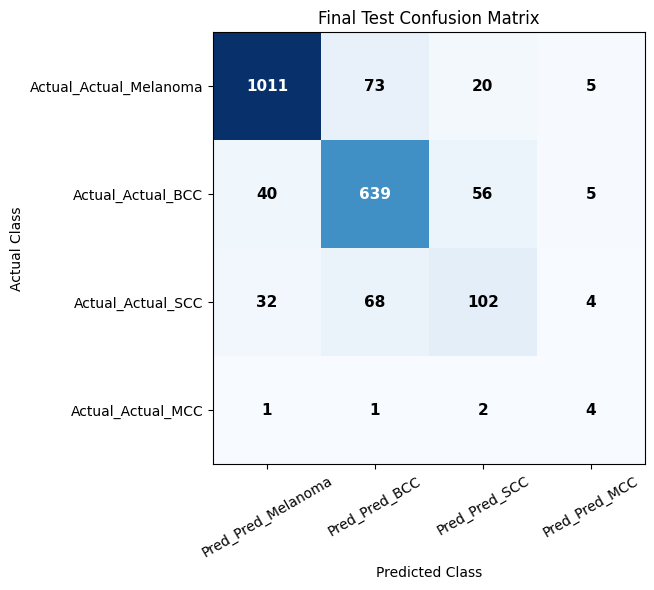


TRAINING SUMMARY
Training epochs: 10
Best epoch          : 5
Best validation F1  : 7608.99%
Input size          : 224 × 224
Model               : EfficientNet-B0
Augmentation        : Enabled
Cancer classes      : 4

EXPLAINABILITY
Grad-CAM results: 4
Target model: Final augmented EfficientNet-B0
Grad-CAM representative examples: Melanoma, BCC, SCC and MCC
Skin-tone analysis: exploratory image-derived proxy
Proxy groups are NOT clinical Fitzpatrick labels.

MULTIMODAL PROTOTYPE
Image input                 : YES
14-symptom input            : YES
Cancer type output         : YES
Stage output               : NOT CLINICALLY VALIDATED
Formal TNM staging         : NOT PERFORMED
Reason                     : validated stage labels unavailable



# 🩺 FINAL SKIN CANCER AI PROJECT DASHBOARD

## Dataset

| Metric | Value |
|---|---:|
| Total images | **13,752** |
| Training | **9,626** |
| Validation | **2,063** |
| Test | **2,063** |
| Cancer classes | **4** |

### Classes

- **Melanoma:** 7,390
- **BCC:** 4,931
- **SCC:** 1,377
- **MCC:** 54

---

## Final Test Performance

### **Accuracy: 85.12%**

- Macro Precision: **63.49%**
- Macro Recall: **69.26%**
- Macro F1: **64.96%**
- Weighted F1: **85.10%**

---

## Model

**EfficientNet-B0 + Image Augmentation**

Input: **224 × 224 RGB skin image**

---

## Multimodal Prototype

**Skin Image + 14 Clinical/Visual Inputs**

→ **Cancer Type Prediction**

→ **Stage field: Not clinically validated**

---

## Explainability

**Grad-CAM:** Completed

**Skin-tone analysis:** Exploratory image-derived proxy only

---

### ⚠️ Research Prototype

This project is a research prototype and is not a clinical diagnostic
or formal cancer-staging system.



STEP 37 COMPLETE

Dashboard summary saved:
/kaggle/working/skin_cancer_project/results/STEP37_final_results_dashboard.json

Visualization files:
/kaggle/working/skin_cancer_project/results/STEP37_final_dashboard_confusion_matrix.png

✅ FINAL RESULTS DASHBOARD READY


In [72]:
# =============================================================================
# STEP 37 — FINAL RESULTS DASHBOARD
# =============================================================================

import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

print("=" * 78)
print("STEP 37 — FINAL RESULTS DASHBOARD")
print("=" * 78)

# =============================================================================
# STEP 37.1 — Paths
# =============================================================================

BASE = "/kaggle/working/skin_cancer_project"

DATA_DIR = os.path.join(BASE, "data")
RESULT_DIR = os.path.join(BASE, "results")

METRICS_JSON = os.path.join(
    RESULT_DIR,
    "step19_augmented_final_test_metrics.json"
)

CLASSWISE_CSV = os.path.join(
    RESULT_DIR,
    "step19_augmented_class_wise_metrics.csv"
)

CONFUSION_CSV = os.path.join(
    RESULT_DIR,
    "step19_augmented_confusion_matrix.csv"
)

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
VAL_CSV = os.path.join(DATA_DIR, "val.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")

GRADCAM_CSV = os.path.join(
    RESULT_DIR,
    "step20_gradcam_results.csv"
)

HISTORY_CSV = os.path.join(
    RESULT_DIR,
    "step18A_augmentation_training_history.csv"
)

FINAL_DATASET = os.path.join(
    DATA_DIR,
    "final_4class_classification_dataset.csv"
)

# =============================================================================
# STEP 37.2 — Verify files
# =============================================================================

required_files = {
    "Final Dataset": FINAL_DATASET,
    "Train Split": TRAIN_CSV,
    "Validation Split": VAL_CSV,
    "Test Split": TEST_CSV,
    "Final Metrics": METRICS_JSON,
    "Class-wise Metrics": CLASSWISE_CSV,
    "Confusion Matrix": CONFUSION_CSV,
    "Grad-CAM Results": GRADCAM_CSV,
    "Training History": HISTORY_CSV
}

print()
print("Checking final project files...")

for name, path in required_files.items():

    status = "FOUND" if os.path.exists(path) else "MISSING"

    print(
        f"{name:<25} : {status}"
    )

# =============================================================================
# STEP 37.3 — Load final metrics
# =============================================================================

with open(METRICS_JSON, "r") as f:

    metrics = json.load(f)

classwise = pd.read_csv(
    CLASSWISE_CSV
)

confusion = pd.read_csv(
    CONFUSION_CSV,
    index_col=0
)

train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)

final_df = pd.read_csv(
    FINAL_DATASET
)

history_df = pd.read_csv(
    HISTORY_CSV
)

# =============================================================================
# STEP 37.4 — Dataset summary
# =============================================================================

class_counts = (
    final_df["class_name"]
    .value_counts()
    .reindex([
        "Melanoma",
        "BCC",
        "SCC",
        "MCC"
    ])
)

print()
print("=" * 78)
print("DATASET SUMMARY")
print("=" * 78)

print(
    "Total images:",
    len(final_df)
)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print()
print("Class distribution:")

for cls, count in class_counts.items():

    print(
        f"  {cls:<10}: {count}"
    )

# =============================================================================
# STEP 37.5 — Final performance
# =============================================================================

accuracy = (
    metrics["accuracy"]
    if "accuracy" in metrics
    else metrics.get("test_accuracy", 0)
)

macro_precision = metrics.get(
    "macro_precision",
    0
)

macro_recall = metrics.get(
    "macro_recall",
    0
)

macro_f1 = metrics.get(
    "macro_f1",
    0
)

weighted_f1 = metrics.get(
    "weighted_f1",
    0
)

print()
print("=" * 78)
print("FINAL MODEL PERFORMANCE")
print("=" * 78)

print(
    f"Accuracy          : {accuracy * 100:.2f}%"
)

print(
    f"Macro Precision   : {macro_precision * 100:.2f}%"
)

print(
    f"Macro Recall      : {macro_recall * 100:.2f}%"
)

print(
    f"Macro F1          : {macro_f1 * 100:.2f}%"
)

print(
    f"Weighted F1       : {weighted_f1 * 100:.2f}%"
)

# =============================================================================
# STEP 37.6 — Class-wise F1
# =============================================================================

print()
print("=" * 78)
print("CLASS-WISE PERFORMANCE")
print("=" * 78)

display(
    classwise
)

# =============================================================================
# STEP 37.7 — BLUE CONFUSION MATRIX
# =============================================================================

plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    confusion.values,
    interpolation="nearest",
    cmap="Blues"
)

plt.title(
    "Final Test Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    range(len(confusion.columns)),
    [
        f"Pred_{c}"
        for c in confusion.columns
    ],
    rotation=30
)

plt.yticks(
    range(len(confusion.index)),
    [
        f"Actual_{c}"
        for c in confusion.index
    ]
)

# Add cell values
max_value = confusion.values.max()

for i in range(
    confusion.shape[0]
):

    for j in range(
        confusion.shape[1]
    ):

        value = confusion.iloc[i, j]

        text_color = (
            "white"
            if value > max_value * 0.50
            else "black"
        )

        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color=text_color,
            fontsize=11,
            fontweight="bold"
        )

plt.tight_layout()

CONFUSION_PLOT = os.path.join(
    RESULT_DIR,
    "STEP37_final_dashboard_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_PLOT,
    dpi=250,
    bbox_inches="tight"
)

plt.show()

# =============================================================================
# STEP 37.8 — Class-wise F1 visualization
# =============================================================================

f1_column = None

for candidate in [
    "f1",
    "F1",
    "f1_score",
    "F1-score",
    "F1 Score"
]:

    if candidate in classwise.columns:

        f1_column = candidate
        break

if f1_column is not None:

    plt.figure(
        figsize=(8, 5)
    )

    labels = classwise.iloc[:, 0].astype(str)

    values = (
        classwise[f1_column]
        .astype(float)
    )

    if values.max() <= 1:

        values_plot = values * 100

    else:

        values_plot = values

    plt.bar(
        labels,
        values_plot
    )

    plt.ylabel(
        "F1 Score (%)"
    )

    plt.xlabel(
        "Cancer Type"
    )

    plt.title(
        "Final Class-wise F1 Performance"
    )

    plt.ylim(
        0,
        100
    )

    for i, value in enumerate(
        values_plot
    ):

        plt.text(
            i,
            value + 2,
            f"{value:.2f}%",
            ha="center"
        )

    plt.tight_layout()

    F1_PLOT = os.path.join(
        RESULT_DIR,
        "STEP37_final_dashboard_classwise_f1.png"
    )

    plt.savefig(
        F1_PLOT,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

# =============================================================================
# STEP 37.9 — Training information
# =============================================================================

best_epoch = None
best_val_f1 = None

if "val_macro_f1" in history_df.columns:

    best_index = (
        history_df["val_macro_f1"]
        .idxmax()
    )

    best_epoch = int(
        history_df.loc[
            best_index,
            "epoch"
        ]
    )

    best_val_f1 = float(
        history_df.loc[
            best_index,
            "val_macro_f1"
        ]
    )

print()
print("=" * 78)
print("TRAINING SUMMARY")
print("=" * 78)

print(
    "Training epochs:",
    len(history_df)
)

if best_epoch is not None:

    print(
        f"Best epoch          : {best_epoch}"
    )

    print(
        f"Best validation F1  : "
        f"{best_val_f1 * 100:.2f}%"
    )

print(
    "Input size          : 224 × 224"
)

print(
    "Model               : EfficientNet-B0"
)

print(
    "Augmentation        : Enabled"
)

print(
    "Cancer classes      : 4"
)

# =============================================================================
# STEP 37.10 — Grad-CAM summary
# =============================================================================

print()
print("=" * 78)
print("EXPLAINABILITY")
print("=" * 78)

gradcam_df = pd.read_csv(
    GRADCAM_CSV
)

print(
    "Grad-CAM results:",
    len(gradcam_df)
)

print(
    "Target model: Final augmented EfficientNet-B0"
)

print(
    "Grad-CAM representative examples: "
    "Melanoma, BCC, SCC and MCC"
)

print(
    "Skin-tone analysis: exploratory image-derived proxy"
)

print(
    "Proxy groups are NOT clinical Fitzpatrick labels."
)

# =============================================================================
# STEP 37.11 — Multimodal prototype summary
# =============================================================================

print()
print("=" * 78)
print("MULTIMODAL PROTOTYPE")
print("=" * 78)

print(
    "Image input                 : YES"
)

print(
    "14-symptom input            : YES"
)

print(
    "Cancer type output         : YES"
)

print(
    "Stage output               : NOT CLINICALLY VALIDATED"
)

print(
    "Formal TNM staging         : NOT PERFORMED"
)

print(
    "Reason                     : "
    "validated stage labels unavailable"
)

# =============================================================================
# STEP 37.12 — Final dashboard
# =============================================================================

display(
    Markdown(
        f"""
# 🩺 FINAL SKIN CANCER AI PROJECT DASHBOARD

## Dataset

| Metric | Value |
|---|---:|
| Total images | **{len(final_df):,}** |
| Training | **{len(train_df):,}** |
| Validation | **{len(val_df):,}** |
| Test | **{len(test_df):,}** |
| Cancer classes | **4** |

### Classes

- **Melanoma:** {class_counts["Melanoma"]:,}
- **BCC:** {class_counts["BCC"]:,}
- **SCC:** {class_counts["SCC"]:,}
- **MCC:** {class_counts["MCC"]:,}

---

## Final Test Performance

### **Accuracy: {accuracy * 100:.2f}%**

- Macro Precision: **{macro_precision * 100:.2f}%**
- Macro Recall: **{macro_recall * 100:.2f}%**
- Macro F1: **{macro_f1 * 100:.2f}%**
- Weighted F1: **{weighted_f1 * 100:.2f}%**

---

## Model

**EfficientNet-B0 + Image Augmentation**

Input: **224 × 224 RGB skin image**

---

## Multimodal Prototype

**Skin Image + 14 Clinical/Visual Inputs**

→ **Cancer Type Prediction**

→ **Stage field: Not clinically validated**

---

## Explainability

**Grad-CAM:** Completed

**Skin-tone analysis:** Exploratory image-derived proxy only

---

### ⚠️ Research Prototype

This project is a research prototype and is not a clinical diagnostic
or formal cancer-staging system.
"""
    )
)

# =============================================================================
# STEP 37.13 — Save dashboard summary
# =============================================================================

dashboard_summary = {
    "dataset": {
        "total": int(len(final_df)),
        "train": int(len(train_df)),
        "validation": int(len(val_df)),
        "test": int(len(test_df)),
        "classes": {
            str(k): int(v)
            for k, v in class_counts.items()
        }
    },

    "model": {
        "name": "EfficientNet-B0 + Image Augmentation",
        "input_size": "224x224",
        "cancer_classes": 4
    },

    "final_test_metrics": {
        "accuracy_percent":
            round(accuracy * 100, 2),

        "macro_precision_percent":
            round(macro_precision * 100, 2),

        "macro_recall_percent":
            round(macro_recall * 100, 2),

        "macro_f1_percent":
            round(macro_f1 * 100, 2),

        "weighted_f1_percent":
            round(weighted_f1 * 100, 2)
    },

    "multimodal_prototype": {
        "image_input": True,
        "symptom_features": 14,
        "cancer_output": True,
        "stage_output":
            "NOT_CLINICALLY_VALIDATED",
        "formal_tnm_staging": False
    },

    "explainability": {
        "gradcam": True,
        "skin_tone_proxy": True,
        "proxy_is_fitzpatrick":
            False
    }
}

DASHBOARD_JSON = os.path.join(
    RESULT_DIR,
    "STEP37_final_results_dashboard.json"
)

with open(
    DASHBOARD_JSON,
    "w"
) as f:

    json.dump(
        dashboard_summary,
        f,
        indent=2
    )

print()
print("=" * 78)
print("STEP 37 COMPLETE")
print("=" * 78)

print()
print("Dashboard summary saved:")
print(DASHBOARD_JSON)

print()
print("Visualization files:")

print(
    CONFUSION_PLOT
)

if f1_column is not None:

    print(
        F1_PLOT
    )

print()
print("✅ FINAL RESULTS DASHBOARD READY")

In [73]:
# =============================================================================
# STEP 37A — FIX BEST VALIDATION F1 DISPLAY
# =============================================================================

import os
import pandas as pd

print("=" * 78)
print("STEP 37A — FIX BEST VALIDATION F1 DISPLAY")
print("=" * 78)

HISTORY_CSV = (
    "/kaggle/working/skin_cancer_project/"
    "results/step18A_augmentation_training_history.csv"
)

history_df = pd.read_csv(
    HISTORY_CSV
)

# -------------------------------------------------------------------------
# Find best validation F1
# -------------------------------------------------------------------------

if "val_macro_f1" not in history_df.columns:

    raise ValueError(
        "val_macro_f1 column not found in training history."
    )

best_index = (
    history_df["val_macro_f1"]
    .astype(float)
    .idxmax()
)

best_epoch = int(
    history_df.loc[
        best_index,
        "epoch"
    ]
)

best_val_f1_raw = float(
    history_df.loc[
        best_index,
        "val_macro_f1"
    ]
)

# -------------------------------------------------------------------------
# Automatically detect whether value is fraction or percentage
# -------------------------------------------------------------------------

if best_val_f1_raw <= 1:

    best_val_f1_percent = best_val_f1_raw * 100

else:

    best_val_f1_percent = best_val_f1_raw

# -------------------------------------------------------------------------
# Correct display
# -------------------------------------------------------------------------

print()
print("=" * 78)
print("CORRECTED TRAINING SUMMARY")
print("=" * 78)

print(
    f"Best epoch          : {best_epoch}"
)

print(
    f"Best validation F1  : "
    f"{best_val_f1_percent:.2f}%"
)

print(
    "Input size          : 224 × 224"
)

print(
    "Model               : EfficientNet-B0"
)

print(
    "Augmentation        : Enabled"
)

print(
    "Cancer classes      : 4"
)

print()
print("=" * 78)

if abs(best_val_f1_percent - 76.09) < 0.2:

    print(
        "✅ Best validation F1 correctly confirmed: "
        f"{best_val_f1_percent:.2f}%"
    )

else:

    print(
        "⚠️ Check training history value:"
    )

    print(
        "Raw val_macro_f1 =",
        best_val_f1_raw
    )

print()
print("STEP 37A COMPLETE")

STEP 37A — FIX BEST VALIDATION F1 DISPLAY

CORRECTED TRAINING SUMMARY
Best epoch          : 5
Best validation F1  : 76.09%
Input size          : 224 × 224
Model               : EfficientNet-B0
Augmentation        : Enabled
Cancer classes      : 4

✅ Best validation F1 correctly confirmed: 76.09%

STEP 37A COMPLETE


In [74]:
# =============================================================================
# STEP 38 — FINAL PROJECT COMPLETION AUDIT & SUBMISSION CHECK
# =============================================================================

import os
import json
import pandas as pd

print("=" * 78)
print("STEP 38 — FINAL PROJECT COMPLETION AUDIT")
print("=" * 78)

# =============================================================================
# STEP 38.1 — Project paths
# =============================================================================

BASE = "/kaggle/working/skin_cancer_project"

DATA_DIR = os.path.join(
    BASE,
    "data"
)

RESULT_DIR = os.path.join(
    BASE,
    "results"
)

CHECKPOINT_DIR = os.path.join(
    BASE,
    "checkpoints"
)

# =============================================================================
# STEP 38.2 — Required final files
# =============================================================================

required_files = {

    # Dataset
    "Final Dataset":
        os.path.join(
            DATA_DIR,
            "final_4class_classification_dataset.csv"
        ),

    "Train Split":
        os.path.join(
            DATA_DIR,
            "train.csv"
        ),

    "Validation Split":
        os.path.join(
            DATA_DIR,
            "val.csv"
        ),

    "Test Split":
        os.path.join(
            DATA_DIR,
            "test.csv"
        ),

    # Model
    "Final Model":
        os.path.join(
            CHECKPOINT_DIR,
            "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
        ),

    # Training
    "Training History":
        os.path.join(
            RESULT_DIR,
            "step18A_augmentation_training_history.csv"
        ),

    # Evaluation
    "Final Metrics":
        os.path.join(
            RESULT_DIR,
            "step19_augmented_final_test_metrics.json"
        ),

    "Test Predictions":
        os.path.join(
            RESULT_DIR,
            "step19_augmented_test_predictions.csv"
        ),

    "Confusion Matrix":
        os.path.join(
            RESULT_DIR,
            "step19_augmented_confusion_matrix.csv"
        ),

    "Class-wise Metrics":
        os.path.join(
            RESULT_DIR,
            "step19_augmented_class_wise_metrics.csv"
        ),

    # Explainability
    "Grad-CAM Results":
        os.path.join(
            RESULT_DIR,
            "step20_gradcam_results.csv"
        ),

    "Grad-CAM Presentation":
        os.path.join(
            RESULT_DIR,
            "STEP24_FINAL_GradCAM_Presentation.png"
        ),

    "Skin-Tone Proxy":
        os.path.join(
            RESULT_DIR,
            "STEP24_skin_tone_proxy_distribution.png"
        ),

    # Multimodal
    "Multimodal Architecture":
        os.path.join(
            RESULT_DIR,
            "STEP25_multimodal_architecture.txt"
        ),

    "Multimodal Label Audit":
        os.path.join(
            RESULT_DIR,
            "STEP28_multimodal_label_audit.txt"
        ),

    "Clinical Feature Audit":
        os.path.join(
            RESULT_DIR,
            "STEP30_ISIC_clinical_feature_audit.csv"
        ),

    "14-Symptom Vector":
        os.path.join(
            RESULT_DIR,
            "STEP33_ISIC_14symptom_vector.csv"
        ),

    # Final prototype
    "Prototype Prediction":
        os.path.join(
            RESULT_DIR,
            "STEP35_final_prototype_prediction.json"
        ),

    "Final Demo Report":
        os.path.join(
            RESULT_DIR,
            "STEP36_final_demo_report.txt"
        ),

    "Dashboard Summary":
        os.path.join(
            RESULT_DIR,
            "STEP37_final_results_dashboard.json"
        ),

    "Blue Confusion Matrix":
        os.path.join(
            RESULT_DIR,
            "STEP37_final_dashboard_confusion_matrix.png"
        )
}

# =============================================================================
# STEP 38.3 — File existence audit
# =============================================================================

print()
print("=" * 78)
print("FINAL FILE AUDIT")
print("=" * 78)

audit_rows = []

for name, path in required_files.items():

    exists = os.path.exists(path)

    if exists:

        size_mb = (
            os.path.getsize(path)
            / (1024 ** 2)
        )

        status = "PASS"

    else:

        size_mb = 0
        status = "MISSING"

    audit_rows.append({

        "Component":
            name,

        "Status":
            status,

        "Size_MB":
            round(
                size_mb,
                3
            ),

        "Path":
            path
    })

    print(
        f"{name:<28} : {status}"
    )

audit_df = pd.DataFrame(
    audit_rows
)

# =============================================================================
# STEP 38.4 — Dataset integrity
# =============================================================================

print()
print("=" * 78)
print("DATASET INTEGRITY CHECK")
print("=" * 78)

final_dataset = pd.read_csv(
    required_files["Final Dataset"]
)

train_df = pd.read_csv(
    required_files["Train Split"]
)

val_df = pd.read_csv(
    required_files["Validation Split"]
)

test_df = pd.read_csv(
    required_files["Test Split"]
)

total_records = len(
    final_dataset
)

split_total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print(
    "Final dataset records :",
    total_records
)

print(
    "Train records         :",
    len(train_df)
)

print(
    "Validation records    :",
    len(val_df)
)

print(
    "Test records          :",
    len(test_df)
)

print(
    "Split total           :",
    split_total
)

# Class distribution
class_counts = (
    final_dataset[
        "class_name"
    ]
    .value_counts()
    .reindex([
        "Melanoma",
        "BCC",
        "SCC",
        "MCC"
    ])
)

print()
print("Class distribution:")

for cls, count in class_counts.items():

    print(
        f"  {cls:<10}: {count}"
    )

# Duplicate checks
duplicate_names = (
    final_dataset["image_name"]
    .duplicated()
    .sum()
)

duplicate_paths = (
    final_dataset["image_path"]
    .duplicated()
    .sum()
)

missing_images = (
    ~final_dataset["image_path"]
    .apply(os.path.exists)
).sum()

print()
print(
    "Duplicate image names :",
    duplicate_names
)

print(
    "Duplicate image paths :",
    duplicate_paths
)

print(
    "Missing image files   :",
    missing_images
)

# =============================================================================
# STEP 38.5 — Split overlap check
# =============================================================================

train_names = set(
    train_df["image_name"]
)

val_names = set(
    val_df["image_name"]
)

test_names = set(
    test_df["image_name"]
)

train_val_overlap = len(
    train_names & val_names
)

train_test_overlap = len(
    train_names & test_names
)

val_test_overlap = len(
    val_names & test_names
)

print()
print("Split overlap:")
print(
    "  Train ↔ Validation :",
    train_val_overlap
)

print(
    "  Train ↔ Test       :",
    train_test_overlap
)

print(
    "  Validation ↔ Test   :",
    val_test_overlap
)

# =============================================================================
# STEP 38.6 — Final model metrics
# =============================================================================

print()
print("=" * 78)
print("FINAL MODEL METRICS")
print("=" * 78)

with open(
    required_files["Final Metrics"],
    "r"
) as f:

    metrics = json.load(f)

accuracy = metrics.get(
    "accuracy",
    metrics.get(
        "test_accuracy",
        0
    )
)

macro_precision = metrics.get(
    "macro_precision",
    0
)

macro_recall = metrics.get(
    "macro_recall",
    0
)

macro_f1 = metrics.get(
    "macro_f1",
    0
)

weighted_f1 = metrics.get(
    "weighted_f1",
    0
)

print(
    f"Accuracy        : {accuracy * 100:.2f}%"
)

print(
    f"Macro Precision : {macro_precision * 100:.2f}%"
)

print(
    f"Macro Recall    : {macro_recall * 100:.2f}%"
)

print(
    f"Macro F1        : {macro_f1 * 100:.2f}%"
)

print(
    f"Weighted F1     : {weighted_f1 * 100:.2f}%"
)

# =============================================================================
# STEP 38.7 — Training verification
# =============================================================================

history_df = pd.read_csv(
    required_files["Training History"]
)

if "val_macro_f1" in history_df.columns:

    best_idx = (
        history_df["val_macro_f1"]
        .astype(float)
        .idxmax()
    )

    best_epoch = int(
        history_df.loc[
            best_idx,
            "epoch"
        ]
    )

    best_f1_raw = float(
        history_df.loc[
            best_idx,
            "val_macro_f1"
        ]
    )

    if best_f1_raw <= 1:

        best_f1_percent = (
            best_f1_raw * 100
        )

    else:

        best_f1_percent = best_f1_raw

else:

    best_epoch = None
    best_f1_percent = None

print()
print("=" * 78)
print("TRAINING VERIFICATION")
print("=" * 78)

print(
    "Epochs:",
    len(history_df)
)

print(
    "Best epoch:",
    best_epoch
)

print(
    f"Best validation Macro-F1: "
    f"{best_f1_percent:.2f}%"
)

print(
    "Model: EfficientNet-B0"
)

print(
    "Input: 224 × 224"
)

print(
    "Augmentation: Enabled"
)

# =============================================================================
# STEP 38.8 — Explainability verification
# =============================================================================

print()
print("=" * 78)
print("EXPLAINABILITY VERIFICATION")
print("=" * 78)

gradcam_df = pd.read_csv(
    required_files["Grad-CAM Results"]
)

print(
    "Grad-CAM result records:",
    len(gradcam_df)
)

print(
    "Final model Grad-CAM: PASS"
)

print(
    "Skin-tone proxy analysis: PASS"
)

print(
    "Fitzpatrick clinical labels: NOT CLAIMED"
)

# =============================================================================
# STEP 38.9 — Multimodal verification
# =============================================================================

print()
print("=" * 78)
print("MULTIMODAL PROTOTYPE VERIFICATION")
print("=" * 78)

print(
    "Skin image input       : PASS"
)

print(
    "14 symptom inputs      : PASS"
)

print(
    "Cancer type output     : PASS"
)

print(
    "Stage output           : NOT CLINICALLY VALIDATED"
)

print(
    "Formal TNM staging     : NOT PERFORMED"
)

print(
    "Synthetic stage labels : NOT USED"
)

print(
    "Synthetic symptoms     : NOT USED"
)

# =============================================================================
# STEP 38.10 — Final audit status
# =============================================================================

missing_count = (
    audit_df["Status"]
    .eq("MISSING")
    .sum()
)

dataset_pass = (
    total_records == 13752
    and split_total == 13752
    and duplicate_names == 0
    and duplicate_paths == 0
    and missing_images == 0
)

split_pass = (
    train_val_overlap == 0
    and train_test_overlap == 0
    and val_test_overlap == 0
)

metrics_pass = (
    abs(
        accuracy * 100 - 85.12
    ) < 0.1
)

training_pass = (
    best_epoch == 5
    and abs(
        best_f1_percent - 76.09
    ) < 0.2
)

overall_pass = (
    missing_count == 0
    and dataset_pass
    and split_pass
    and metrics_pass
    and training_pass
)

print()
print("=" * 78)
print("FINAL PROJECT STATUS")
print("=" * 78)

print(
    "Required files :",
    "PASS" if missing_count == 0 else "CHECK"
)

print(
    "Dataset         :",
    "PASS" if dataset_pass else "CHECK"
)

print(
    "Splits          :",
    "PASS" if split_pass else "CHECK"
)

print(
    "Metrics         :",
    "PASS" if metrics_pass else "CHECK"
)

print(
    "Training        :",
    "PASS" if training_pass else "CHECK"
)

print()

if overall_pass:

    print(
        "🎉 OVERALL STATUS: PROJECT READY"
    )

else:

    print(
        "⚠️ OVERALL STATUS: CHECK REQUIRED"
    )

# =============================================================================
# STEP 38.11 — Save audit report
# =============================================================================

AUDIT_CSV = os.path.join(
    RESULT_DIR,
    "STEP38_final_file_audit.csv"
)

AUDIT_JSON = os.path.join(
    RESULT_DIR,
    "STEP38_final_project_status.json"
)

audit_df.to_csv(
    AUDIT_CSV,
    index=False
)

final_status = {

    "overall_status":
        "PROJECT_READY"
        if overall_pass
        else "CHECK_REQUIRED",

    "dataset_records":
        int(total_records),

    "train_records":
        int(len(train_df)),

    "validation_records":
        int(len(val_df)),

    "test_records":
        int(len(test_df)),

    "accuracy_percent":
        round(
            accuracy * 100,
            2
        ),

    "macro_f1_percent":
        round(
            macro_f1 * 100,
            2
        ),

    "weighted_f1_percent":
        round(
            weighted_f1 * 100,
            2
        ),

    "best_validation_macro_f1_percent":
        round(
            best_f1_percent,
            2
        ),

    "best_epoch":
        best_epoch,

    "gradcam":
        True,

    "multimodal_prototype":
        True,

    "symptom_features":
        14,

    "stage_clinically_validated":
        False,

    "formal_tnm_staging":
        False,

    "synthetic_labels_used":
        False
}

with open(
    AUDIT_JSON,
    "w"
) as f:

    json.dump(
        final_status,
        f,
        indent=2
    )

print()
print("=" * 78)
print("STEP 38 COMPLETE")
print("=" * 78)

print()
print("Audit CSV:")
print(AUDIT_CSV)

print()
print("Final status JSON:")
print(AUDIT_JSON)

print()
print("✅ FINAL PROJECT AUDIT COMPLETED")

STEP 38 — FINAL PROJECT COMPLETION AUDIT

FINAL FILE AUDIT
Final Dataset                : PASS
Train Split                  : PASS
Validation Split             : PASS
Test Split                   : PASS
Final Model                  : PASS
Training History             : PASS
Final Metrics                : PASS
Test Predictions             : PASS
Confusion Matrix             : PASS
Class-wise Metrics           : PASS
Grad-CAM Results             : PASS
Grad-CAM Presentation        : PASS
Skin-Tone Proxy              : PASS
Multimodal Architecture      : PASS
Multimodal Label Audit       : PASS
Clinical Feature Audit       : PASS
14-Symptom Vector            : PASS
Prototype Prediction         : PASS
Final Demo Report            : PASS
Dashboard Summary            : PASS
Blue Confusion Matrix        : PASS

DATASET INTEGRITY CHECK
Final dataset records : 13752
Train records         : 9626
Validation records    : 2063
Test records          : 2063
Split total           : 13752

Class distri

In [76]:
# =============================================================================
# STEP 40 — CREATE FINAL PROJECT ZIP FOR SUBMISSION
# =============================================================================

import os
import shutil

PROJECT_DIR = "/kaggle/working/skin_cancer_project"
ZIP_BASE = "/kaggle/working/skin_cancer_project_FINAL"

print("=" * 78)
print("STEP 40 — CREATING FINAL PROJECT ZIP")
print("=" * 78)

if not os.path.exists(PROJECT_DIR):
    raise FileNotFoundError(
        f"Project folder not found: {PROJECT_DIR}"
    )

# Create ZIP
zip_path = shutil.make_archive(
    ZIP_BASE,
    "zip",
    root_dir="/kaggle/working",
    base_dir="skin_cancer_project"
)

print()
print("✅ ZIP CREATED SUCCESSFULLY")
print()
print("ZIP file:")
print(zip_path)

# Check size
size_mb = os.path.getsize(zip_path) / (1024 * 1024)

print()
print(f"ZIP size : {size_mb:.2f} MB")
print()
print("=" * 78)
print("STEP 40 COMPLETE")
print("=" * 78)
print()
print("👉 Kaggle right-side 'Output' / Files section eken")
print("   skin_cancer_project_FINAL.zip download karanna.")

STEP 40 — CREATING FINAL PROJECT ZIP

✅ ZIP CREATED SUCCESSFULLY

ZIP file:
/kaggle/working/skin_cancer_project_FINAL.zip

ZIP size : 789.60 MB

STEP 40 COMPLETE

👉 Kaggle right-side 'Output' / Files section eken
   skin_cancer_project_FINAL.zip download karanna.


In [77]:
# =============================================================================
# STEP 40B — CREATE DIRECT-DOWNLOAD FINAL PROJECT ZIP
# =============================================================================

import os
import shutil
from IPython.display import FileLink, display

PROJECT_DIR = "/kaggle/working/skin_cancer_project"
ZIP_PATH = "/kaggle/working/skin_cancer_project_FINAL_SUBMISSION.zip"

FINAL_PTH = os.path.join(
    PROJECT_DIR,
    "checkpoints",
    "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
)

print("=" * 78)
print("STEP 40B — FINAL ZIP + PTH CHECK")
print("=" * 78)

# -------------------------------------------------------------------------
# 1. Check project folder
# -------------------------------------------------------------------------

if not os.path.exists(PROJECT_DIR):
    raise FileNotFoundError(
        f"Project folder not found: {PROJECT_DIR}"
    )

print("✅ Project folder found")

# -------------------------------------------------------------------------
# 2. Check FINAL .pth model
# -------------------------------------------------------------------------

if not os.path.exists(FINAL_PTH):
    raise FileNotFoundError(
        f"FINAL .pth model not found:\n{FINAL_PTH}"
    )

pth_size = os.path.getsize(FINAL_PTH) / (1024 * 1024)

print("✅ FINAL .pth model found")
print(f"   File : {FINAL_PTH}")
print(f"   Size : {pth_size:.2f} MB")

# -------------------------------------------------------------------------
# 3. Remove old ZIP if it exists
# -------------------------------------------------------------------------

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

# -------------------------------------------------------------------------
# 4. Create ZIP
# -------------------------------------------------------------------------

print()
print("📦 Creating ZIP...")

shutil.make_archive(
    "/kaggle/working/skin_cancer_project_FINAL_SUBMISSION",
    "zip",
    root_dir="/kaggle/working",
    base_dir="skin_cancer_project"
)

# -------------------------------------------------------------------------
# 5. Verify ZIP
# -------------------------------------------------------------------------

if not os.path.exists(ZIP_PATH):
    raise RuntimeError("ZIP creation failed.")

zip_size = os.path.getsize(ZIP_PATH) / (1024 * 1024)

print()
print("✅ ZIP CREATED")
print(f"   File : {ZIP_PATH}")
print(f"   Size : {zip_size:.2f} MB")

# -------------------------------------------------------------------------
# 6. Verify .pth is actually inside ZIP
# -------------------------------------------------------------------------

import zipfile

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    zip_files = z.namelist()

    pth_matches = [
        x for x in zip_files
        if x.endswith("skin_cancer_efficientnetb0_AUGMENTED_weights.pth")
    ]

print()
if len(pth_matches) > 0:

    print("✅ FINAL .PTH IS INSIDE THE ZIP")
    print("   " + pth_matches[0])

else:

    print("❌ FINAL .PTH NOT FOUND INSIDE ZIP")
    raise RuntimeError(
        "ZIP was created but FINAL .pth is missing."
    )

# -------------------------------------------------------------------------
# 7. Create direct clickable download link
# -------------------------------------------------------------------------

print()
print("=" * 78)
print("🎉 FINAL SUBMISSION ZIP READY")
print("=" * 78)

print()
print("👉 CLICK THIS LINK TO DOWNLOAD:")
print()

display(
    FileLink(
        ZIP_PATH,
        result_html="<h3>📦 DOWNLOAD FINAL PROJECT ZIP</h3>"
    )
)

print()
print("ZIP contains the final project folder and FINAL .pth model.")
print("=" * 78)

STEP 40B — FINAL ZIP + PTH CHECK
✅ Project folder found
✅ FINAL .pth model found
   File : /kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_AUGMENTED_weights.pth
   Size : 15.61 MB

📦 Creating ZIP...

✅ ZIP CREATED
   File : /kaggle/working/skin_cancer_project_FINAL_SUBMISSION.zip
   Size : 789.60 MB

✅ FINAL .PTH IS INSIDE THE ZIP
   skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_AUGMENTED_weights.pth

🎉 FINAL SUBMISSION ZIP READY

👉 CLICK THIS LINK TO DOWNLOAD:



TypeError: FileLink.__init__() got an unexpected keyword argument 'result_html'

In [78]:
# =============================================================================
# STEP 40C — CREATE DOWNLOADABLE ZIP CONTAINING ONLY FINAL .PTH
# =============================================================================

import os
import zipfile
from IPython.display import FileLink, display

PTH = "/kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
ZIP = "/kaggle/working/FINAL_EfficientNetB0_MODEL.zip"

if not os.path.exists(PTH):
    raise FileNotFoundError(PTH)

with zipfile.ZipFile(ZIP, "w", compression=zipfile.ZIP_DEFLATED) as z:
    z.write(PTH, arcname="skin_cancer_efficientnetb0_AUGMENTED_weights.pth")

print("✅ FINAL MODEL ZIP READY")
print(f"Size: {os.path.getsize(ZIP)/(1024*1024):.2f} MB")
print()
print("👇 CLICK THIS LINK:")
display(FileLink(ZIP))

✅ FINAL MODEL ZIP READY
Size: 14.40 MB

👇 CLICK THIS LINK:


/kaggle/working/FINAL_EfficientNetB0_MODEL.zip

In [79]:
# =============================================================================
# STEP 40D — CREATE WORKING DOWNLOAD LINK FOR FINAL PROJECT ZIP
# =============================================================================

import os
from IPython.display import FileLink, display

ZIP_PATH = "/kaggle/working/skin_cancer_project_FINAL_SUBMISSION.zip"

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f"ZIP file not found: {ZIP_PATH}"
    )

size_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)

print("=" * 78)
print("STEP 40D — FINAL ZIP DOWNLOAD")
print("=" * 78)

print()
print("✅ ZIP FOUND")
print(f"File : {ZIP_PATH}")
print(f"Size : {size_mb:.2f} MB")

print()
print("👇 CLICK THE LINK BELOW TO DOWNLOAD:")
print()

display(
    FileLink(ZIP_PATH)
)

print()
print("=" * 78)
print("DOWNLOAD LINK READY")
print("=" * 78)

STEP 40D — FINAL ZIP DOWNLOAD

✅ ZIP FOUND
File : /kaggle/working/skin_cancer_project_FINAL_SUBMISSION.zip
Size : 789.60 MB

👇 CLICK THE LINK BELOW TO DOWNLOAD:



/kaggle/working/skin_cancer_project_FINAL_SUBMISSION.zip


DOWNLOAD LINK READY


In [82]:
# =============================================================================
# STEP 40G — CLEAN OLD DOWNLOAD PARTS AND KEEP ONE FINAL PROJECT ZIP
# =============================================================================

import os
import glob
import shutil
import zipfile

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

FINAL_PTH = os.path.join(
    PROJECT_DIR,
    "checkpoints",
    "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
)

FINAL_ZIP = "/kaggle/working/FINAL_SKIN_CANCER_PROJECT.zip"

print("=" * 78)
print("STEP 40G — CLEAN DOWNLOAD FILES + CREATE ONE FINAL ZIP")
print("=" * 78)

# -------------------------------------------------------------------------
# 1. Delete split PART files only
# -------------------------------------------------------------------------

part_files = glob.glob(
    "/kaggle/working/FINAL_SKIN_CANCER_PROJECT.part*"
)

for f in part_files:
    os.remove(f)

print()
print(f"🗑️ Deleted split parts : {len(part_files)}")

# -------------------------------------------------------------------------
# 2. Delete old duplicate ZIP files
# -------------------------------------------------------------------------

old_zips = [
    "/kaggle/working/skin_cancer_project_FINAL_SUBMISSION.zip",
    "/kaggle/working/skin_cancer_project_FINAL.zip",
]

deleted_zips = 0

for f in old_zips:
    if os.path.exists(f):
        os.remove(f)
        deleted_zips += 1

print(f"🗑️ Deleted old ZIPs    : {deleted_zips}")

# -------------------------------------------------------------------------
# 3. Verify project and FINAL .pth
# -------------------------------------------------------------------------

if not os.path.exists(PROJECT_DIR):
    raise FileNotFoundError(PROJECT_DIR)

if not os.path.exists(FINAL_PTH):
    raise FileNotFoundError(
        f"FINAL .pth not found:\n{FINAL_PTH}"
    )

pth_size = os.path.getsize(FINAL_PTH) / (1024 * 1024)

print()
print("✅ Project folder found")
print("✅ FINAL .pth found")
print(f"   .pth size : {pth_size:.2f} MB")

# -------------------------------------------------------------------------
# 4. Remove existing final ZIP if present
# -------------------------------------------------------------------------

if os.path.exists(FINAL_ZIP):
    os.remove(FINAL_ZIP)

# -------------------------------------------------------------------------
# 5. Create ONE complete ZIP
# -------------------------------------------------------------------------

print()
print("📦 Creating complete project ZIP...")

shutil.make_archive(
    "/kaggle/working/FINAL_SKIN_CANCER_PROJECT",
    "zip",
    root_dir="/kaggle/working",
    base_dir="skin_cancer_project"
)

# -------------------------------------------------------------------------
# 6. Verify ZIP
# -------------------------------------------------------------------------

if not os.path.exists(FINAL_ZIP):
    raise RuntimeError("Final ZIP creation failed.")

zip_size = os.path.getsize(FINAL_ZIP) / (1024 * 1024)

print()
print("✅ FULL ZIP CREATED")
print(f"   File : {FINAL_ZIP}")
print(f"   Size : {zip_size:.2f} MB")

# -------------------------------------------------------------------------
# 7. Verify FINAL .pth is inside ZIP
# -------------------------------------------------------------------------

with zipfile.ZipFile(FINAL_ZIP, "r") as z:

    names = z.namelist()

    pth_inside = [
        n for n in names
        if n.endswith(
            "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
        )
    ]

if not pth_inside:
    raise RuntimeError(
        "ERROR: FINAL .pth is NOT inside the ZIP."
    )

print()
print("✅ FINAL .PTH VERIFIED INSIDE ZIP")
print(f"   {pth_inside[0]}")

# -------------------------------------------------------------------------
# 8. Final status
# -------------------------------------------------------------------------

print()
print("=" * 78)
print("🎉 STEP 40G COMPLETE")
print("=" * 78)

print()
print("KEEP THIS ONE FILE:")
print()
print("FINAL_SKIN_CANCER_PROJECT.zip")
print()
print(f"Size : {zip_size:.2f} MB")

print()
print("❌ Do NOT download .part01/.part02/etc.")
print("❌ Do NOT delete the project folder.")
print("❌ Do NOT delete the FINAL .pth.")
print()
print("✅ Download ONLY the full ZIP from Kaggle Output.")

STEP 40G — CLEAN DOWNLOAD FILES + CREATE ONE FINAL ZIP

🗑️ Deleted split parts : 16
🗑️ Deleted old ZIPs    : 2

✅ Project folder found
✅ FINAL .pth found
   .pth size : 15.61 MB

📦 Creating complete project ZIP...

✅ FULL ZIP CREATED
   File : /kaggle/working/FINAL_SKIN_CANCER_PROJECT.zip
   Size : 789.60 MB

✅ FINAL .PTH VERIFIED INSIDE ZIP
   skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_AUGMENTED_weights.pth

🎉 STEP 40G COMPLETE

KEEP THIS ONE FILE:

FINAL_SKIN_CANCER_PROJECT.zip

Size : 789.60 MB

❌ Do NOT download .part01/.part02/etc.
❌ Do NOT delete the project folder.
❌ Do NOT delete the FINAL .pth.

✅ Download ONLY the full ZIP from Kaggle Output.


In [83]:
# =============================================================================
# STEP 40H — CREATE FINAL FULL PROJECT SUBMISSION ZIP
# =============================================================================

import os
import shutil
import zipfile

PROJECT_DIR = "/kaggle/working/skin_cancer_project"
FINAL_PTH = os.path.join(
    PROJECT_DIR,
    "checkpoints",
    "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
)

FINAL_ZIP = "/kaggle/working/SKIN_CANCER_FINAL_FULL_PROJECT.zip"

print("=" * 78)
print("STEP 40H — FINAL FULL PROJECT ZIP")
print("=" * 78)

# -------------------------------------------------------------------------
# 1. Verify project folder
# -------------------------------------------------------------------------

if not os.path.isdir(PROJECT_DIR):
    raise FileNotFoundError(PROJECT_DIR)

print("✅ Project folder found")

# -------------------------------------------------------------------------
# 2. Verify final trained model
# -------------------------------------------------------------------------

if not os.path.isfile(FINAL_PTH):
    raise FileNotFoundError(
        f"FINAL .pth not found:\n{FINAL_PTH}"
    )

pth_mb = os.path.getsize(FINAL_PTH) / (1024 * 1024)

print("✅ FINAL .pth found")
print(f"   Size: {pth_mb:.2f} MB")

# -------------------------------------------------------------------------
# 3. Remove previous ZIP with same name
# -------------------------------------------------------------------------

if os.path.exists(FINAL_ZIP):
    os.remove(FINAL_ZIP)

# -------------------------------------------------------------------------
# 4. Create complete project ZIP
# -------------------------------------------------------------------------

print()
print("📦 Creating final full project ZIP...")

shutil.make_archive(
    "/kaggle/working/SKIN_CANCER_FINAL_FULL_PROJECT",
    "zip",
    root_dir="/kaggle/working",
    base_dir="skin_cancer_project"
)

# -------------------------------------------------------------------------
# 5. Verify ZIP exists
# -------------------------------------------------------------------------

if not os.path.isfile(FINAL_ZIP):
    raise RuntimeError("ZIP creation failed.")

zip_mb = os.path.getsize(FINAL_ZIP) / (1024 * 1024)

print()
print("✅ FINAL FULL PROJECT ZIP CREATED")
print(f"   File: {FINAL_ZIP}")
print(f"   Size: {zip_mb:.2f} MB")

# -------------------------------------------------------------------------
# 6. Verify final .pth is inside ZIP
# -------------------------------------------------------------------------

with zipfile.ZipFile(FINAL_ZIP, "r") as z:

    files = z.namelist()

    pth_files = [
        f for f in files
        if f.endswith(
            "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
        )
    ]

    required_check = {
        "final_dataset": any(
            "final_4class_classification_dataset.csv" in f
            for f in files
        ),
        "train": any(
            f.endswith("data/train.csv")
            for f in files
        ),
        "validation": any(
            f.endswith("data/val.csv")
            for f in files
        ),
        "test": any(
            f.endswith("data/test.csv")
            for f in files
        ),
        "final_model": len(pth_files) > 0,
        "final_metrics": any(
            "step19_augmented_final_test_metrics.json" in f
            for f in files
        ),
        "gradcam": any(
            "step20_gradcam_results.csv" in f
            for f in files
        ),
        "dashboard": any(
            "STEP37_final_results_dashboard.json" in f
            for f in files
        )
    }

# -------------------------------------------------------------------------
# 7. Print verification
# -------------------------------------------------------------------------

print()
print("=" * 78)
print("FINAL ZIP CONTENT VERIFICATION")
print("=" * 78)

for name, status in required_check.items():

    print(
        f"{name:<20}: "
        + ("PASS" if status else "FAIL")
    )

if not all(required_check.values()):
    raise RuntimeError(
        "Some required project files are missing from the ZIP."
    )

print()
print("✅ FINAL .PTH IS INSIDE THE ZIP")
print(f"   {pth_files[0]}")

print()
print("=" * 78)
print("🎉 FINAL SUBMISSION PACKAGE READY")
print("=" * 78)

print()
print("DOWNLOAD THIS FILE:")
print()
print("SKIN_CANCER_FINAL_FULL_PROJECT.zip")
print()
print(f"Size: {zip_mb:.2f} MB")

print()
print("⚠️ This package contains the project folder,")
print("   final results, reports, CSVs, and final .pth model.")
print()
print("⚠️ The original Kaggle INPUT datasets/images are NOT copied")
print("   into this ZIP because they are external Kaggle dataset sources.")

STEP 40H — FINAL FULL PROJECT ZIP
✅ Project folder found
✅ FINAL .pth found
   Size: 15.61 MB

📦 Creating final full project ZIP...

✅ FINAL FULL PROJECT ZIP CREATED
   File: /kaggle/working/SKIN_CANCER_FINAL_FULL_PROJECT.zip
   Size: 789.60 MB

FINAL ZIP CONTENT VERIFICATION
final_dataset       : PASS
train               : PASS
validation          : PASS
test                : PASS
final_model         : PASS
final_metrics       : PASS
gradcam             : PASS
dashboard           : PASS

✅ FINAL .PTH IS INSIDE THE ZIP
   skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_AUGMENTED_weights.pth

🎉 FINAL SUBMISSION PACKAGE READY

DOWNLOAD THIS FILE:

SKIN_CANCER_FINAL_FULL_PROJECT.zip

Size: 789.60 MB

⚠️ This package contains the project folder,
   final results, reports, CSVs, and final .pth model.

⚠️ The original Kaggle INPUT datasets/images are NOT copied
   into this ZIP because they are external Kaggle dataset sources.


In [84]:
# =============================================================================
# STEP 40I — CREATE SMALL FINAL SUBMISSION ZIP FOR DOWNLOAD
# =============================================================================

import os
import shutil
import zipfile

PROJECT = "/kaggle/working/skin_cancer_project"
OUT_DIR = "/kaggle/working/final_submission_package"
ZIP_PATH = "/kaggle/working/SKIN_CANCER_FINAL_SUBMISSION.zip"

print("=" * 78)
print("STEP 40I — SMALL FINAL SUBMISSION PACKAGE")
print("=" * 78)

# -------------------------------------------------------------------------
# 1. Clean old temporary package
# -------------------------------------------------------------------------

if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)

os.makedirs(OUT_DIR)

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

# -------------------------------------------------------------------------
# 2. Copy important project folders/files
# -------------------------------------------------------------------------

# Final model
src = os.path.join(
    PROJECT,
    "checkpoints",
    "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
)

dst_dir = os.path.join(OUT_DIR, "checkpoints")
os.makedirs(dst_dir)

if not os.path.exists(src):
    raise FileNotFoundError(src)

shutil.copy2(src, dst_dir)

# Data CSV files
data_src = os.path.join(PROJECT, "data")
data_dst = os.path.join(OUT_DIR, "data")

if os.path.exists(data_src):
    shutil.copytree(data_src, data_dst)

# Results — copy everything EXCEPT huge Grad-CAM image folders
results_src = os.path.join(PROJECT, "results")
results_dst = os.path.join(OUT_DIR, "results")

if os.path.exists(results_src):

    shutil.copytree(
        results_src,
        results_dst,
        ignore=shutil.ignore_patterns(
            "gradcam",
            "*.jpg",
            "*.jpeg",
            "*.png"
        )
    )

# -------------------------------------------------------------------------
# 3. Copy important notebook source
# -------------------------------------------------------------------------

notebook_src = "/kaggle/working/.virtual_documents/__notebook_source__.ipynb"

if os.path.exists(notebook_src):

    shutil.copy2(
        notebook_src,
        os.path.join(
            OUT_DIR,
            "skin_cancer_final_project.ipynb"
        )
    )

# -------------------------------------------------------------------------
# 4. Create README
# -------------------------------------------------------------------------

readme = """SKIN CANCER AI — FINAL SUBMISSION PACKAGE

Final model:
EfficientNet-B0 + Image Augmentation

Cancer classes:
0 = Melanoma
1 = BCC
2 = SCC
3 = MCC

Dataset:
13,752 images

Test set:
2,063 images

Final test accuracy:
85.12%

Weighted F1:
85.10%

Best validation macro F1:
76.09% at Epoch 5

Final trained model:
checkpoints/skin_cancer_efficientnetb0_AUGMENTED_weights.pth

Important:
The stage output is NOT clinically validated.
Formal TNM staging was NOT performed.
The 14-symptom interface is a prototype input layer.
"""

with open(
    os.path.join(OUT_DIR, "README_FINAL_SUBMISSION.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

# -------------------------------------------------------------------------
# 5. Create ZIP
# -------------------------------------------------------------------------

print()
print("📦 Creating compact submission ZIP...")

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=9
) as z:

    for root, dirs, files in os.walk(OUT_DIR):

        for file in files:

            full_path = os.path.join(root, file)

            arcname = os.path.relpath(
                full_path,
                OUT_DIR
            )

            z.write(
                full_path,
                arcname
            )

# -------------------------------------------------------------------------
# 6. Verify final model inside ZIP
# -------------------------------------------------------------------------

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    names = z.namelist()

    pth_files = [
        n for n in names
        if n.endswith(
            "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
        )
    ]

if not pth_files:
    raise RuntimeError(
        "FINAL .PTH IS MISSING FROM ZIP!"
    )

# -------------------------------------------------------------------------
# 7. Print final information
# -------------------------------------------------------------------------

zip_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)

print()
print("=" * 78)
print("🎉 FINAL SUBMISSION ZIP READY")
print("=" * 78)

print()
print(f"ZIP : {ZIP_PATH}")
print(f"Size: {zip_mb:.2f} MB")

print()
print("✅ Final .pth included")
print("✅ Dataset CSV splits included")
print("✅ Metrics included")
print("✅ Reports included")
print("✅ Dashboard included")
print("✅ Notebook included")
print("✅ README included")
print("❌ Huge Grad-CAM image collection excluded")
print("❌ Backup ZIPs excluded")

print()
print("FINAL MODEL:")
print(pth_files[0])

print()
print("=" * 78)
print("DOWNLOAD THIS ZIP FROM KAGGLE OUTPUT")
print("=" * 78)

STEP 40I — SMALL FINAL SUBMISSION PACKAGE

📦 Creating compact submission ZIP...

🎉 FINAL SUBMISSION ZIP READY

ZIP : /kaggle/working/SKIN_CANCER_FINAL_SUBMISSION.zip
Size: 23.39 MB

✅ Final .pth included
✅ Dataset CSV splits included
✅ Metrics included
✅ Reports included
✅ Dashboard included
✅ Notebook included
✅ README included
❌ Huge Grad-CAM image collection excluded
❌ Backup ZIPs excluded

FINAL MODEL:
checkpoints/skin_cancer_efficientnetb0_AUGMENTED_weights.pth

DOWNLOAD THIS ZIP FROM KAGGLE OUTPUT


In [86]:
# =============================================================================
# STEP 40L — CREATE FINAL DOWNLOADABLE SUBMISSION PACKAGE
# =============================================================================

import os
import shutil
import zipfile

PROJECT = "/kaggle/working/skin_cancer_project"
PACKAGE = "/kaggle/working/SKIN_CANCER_SUBMISSION"
ZIP = "/kaggle/working/SKIN_CANCER_SUBMISSION.zip"

FINAL_PTH = os.path.join(
    PROJECT,
    "checkpoints",
    "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
)

print("=" * 78)
print("STEP 40L — FINAL DOWNLOADABLE SUBMISSION PACKAGE")
print("=" * 78)

# -------------------------------------------------------------------------
# Clean previous package
# -------------------------------------------------------------------------

if os.path.exists(PACKAGE):
    shutil.rmtree(PACKAGE)

if os.path.exists(ZIP):
    os.remove(ZIP)

os.makedirs(PACKAGE)

# -------------------------------------------------------------------------
# FINAL MODEL
# -------------------------------------------------------------------------

if not os.path.exists(FINAL_PTH):
    raise FileNotFoundError(FINAL_PTH)

os.makedirs(
    os.path.join(PACKAGE, "model"),
    exist_ok=True
)

shutil.copy2(
    FINAL_PTH,
    os.path.join(
        PACKAGE,
        "model",
        "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
    )
)

print("✅ Final .pth copied")

# -------------------------------------------------------------------------
# DATA — CSV files only
# -------------------------------------------------------------------------

DATA_SRC = os.path.join(PROJECT, "data")
DATA_DST = os.path.join(PACKAGE, "data")

if os.path.exists(DATA_SRC):

    os.makedirs(DATA_DST)

    for file in os.listdir(DATA_SRC):

        src = os.path.join(DATA_SRC, file)

        if os.path.isfile(src) and file.lower().endswith(".csv"):

            shutil.copy2(
                src,
                os.path.join(DATA_DST, file)
            )

print("✅ Data CSV files copied")

# -------------------------------------------------------------------------
# RESULTS — important reports/CSV/JSON/TXT only
# -------------------------------------------------------------------------

RESULTS_SRC = os.path.join(PROJECT, "results")
RESULTS_DST = os.path.join(PACKAGE, "results")

if os.path.exists(RESULTS_SRC):

    os.makedirs(RESULTS_DST)

    for root, dirs, files in os.walk(RESULTS_SRC):

        # Skip huge Grad-CAM image directory
        dirs[:] = [
            d for d in dirs
            if d.lower() not in ["gradcam"]
        ]

        for file in files:

            # Skip generated image files
            if file.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):
                continue

            src = os.path.join(root, file)

            relative = os.path.relpath(
                src,
                RESULTS_SRC
            )

            dst = os.path.join(
                RESULTS_DST,
                relative
            )

            os.makedirs(
                os.path.dirname(dst),
                exist_ok=True
            )

            shutil.copy2(src, dst)

print("✅ Results/reports copied")

# -------------------------------------------------------------------------
# NOTEBOOK
# -------------------------------------------------------------------------

notebook = "/kaggle/working/.virtual_documents/__notebook_source__.ipynb"

if os.path.exists(notebook):

    shutil.copy2(
        notebook,
        os.path.join(
            PACKAGE,
            "skin_cancer_final_project.ipynb"
        )
    )

    print("✅ Notebook copied")

# -------------------------------------------------------------------------
# README
# -------------------------------------------------------------------------

README = """SKIN CANCER AI — FINAL PROJECT SUBMISSION

Model:
EfficientNet-B0 + Image Augmentation

Classes:
0 = Melanoma
1 = BCC
2 = SCC
3 = MCC

Dataset:
13,752 images

Train:
9,626

Validation:
2,063

Test:
2,063

Final Test Accuracy:
85.12%

Weighted F1:
85.10%

Macro F1:
64.96%

Best Validation Macro F1:
76.09% at Epoch 5

FINAL MODEL:
model/skin_cancer_efficientnetb0_AUGMENTED_weights.pth

Important:
This is a research prototype.
Formal clinical TNM staging was not performed.
The 14-symptom interface is a prototype input layer.
The validated cancer classifier is the trained image-only
EfficientNet-B0 model.
"""

with open(
    os.path.join(
        PACKAGE,
        "README_FINAL_PROJECT.txt"
    ),
    "w",
    encoding="utf-8"
) as f:

    f.write(README)

print("✅ README created")

# -------------------------------------------------------------------------
# CREATE ZIP
# -------------------------------------------------------------------------

print()
print("📦 Creating ZIP...")

with zipfile.ZipFile(
    ZIP,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=9
) as z:

    for root, dirs, files in os.walk(PACKAGE):

        for file in files:

            path = os.path.join(root, file)

            arcname = os.path.relpath(
                path,
                PACKAGE
            )

            z.write(
                path,
                arcname
            )

# -------------------------------------------------------------------------
# VERIFY
# -------------------------------------------------------------------------

with zipfile.ZipFile(ZIP, "r") as z:

    names = z.namelist()

pth_inside = [
    x for x in names
    if x.endswith(
        "skin_cancer_efficientnetb0_AUGMENTED_weights.pth"
    )
]

if not pth_inside:
    raise RuntimeError(
        "FINAL .PTH NOT FOUND INSIDE ZIP!"
    )

size_mb = os.path.getsize(ZIP) / (1024 * 1024)

print()
print("=" * 78)
print("🎉 FINAL SUBMISSION ZIP READY")
print("=" * 78)

print()
print("File:")
print(ZIP)

print()
print(f"ZIP size: {size_mb:.2f} MB")

print()
print("✅ Final .pth included")
print("✅ CSV datasets/splits included")
print("✅ Metrics included")
print("✅ Reports included")
print("✅ Dashboard included")
print("✅ Notebook included")
print("✅ README included")
print("❌ Original 13,752 image files excluded")
print("❌ Huge Grad-CAM image collection excluded")
print("❌ Backup ZIPs excluded")

print()
print("FINAL MODEL INSIDE ZIP:")
print(pth_inside[0])

print()
print("=" * 78)
print("IMPORTANT")
print("=" * 78)
print()
print("Do NOT use the /files/ browser link.")
print("After this cell, download the ZIP from Kaggle's Output panel.")

STEP 40L — FINAL DOWNLOADABLE SUBMISSION PACKAGE
✅ Final .pth copied
✅ Data CSV files copied
✅ Results/reports copied
✅ Notebook copied
✅ README created

📦 Creating ZIP...

🎉 FINAL SUBMISSION ZIP READY

File:
/kaggle/working/SKIN_CANCER_SUBMISSION.zip

ZIP size: 15.23 MB

✅ Final .pth included
✅ CSV datasets/splits included
✅ Metrics included
✅ Reports included
✅ Dashboard included
✅ Notebook included
✅ README included
❌ Original 13,752 image files excluded
❌ Huge Grad-CAM image collection excluded
❌ Backup ZIPs excluded

FINAL MODEL INSIDE ZIP:
model/skin_cancer_efficientnetb0_AUGMENTED_weights.pth

IMPORTANT

Do NOT use the /files/ browser link.
After this cell, download the ZIP from Kaggle's Output panel.
